# Introduction to Artificial Neural Networks (ANN) and Deep Learning


**Learning goal.** Understand how a neural network calculates a prediction, how a loss measures its error, how gradients change its weights, and how convolutional neural networks learn useful features for image classification.



In [1]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 5)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11})
DEVICE = torch.device('cpu')  # Colab CPU is enough for every demonstration
print('PyTorch:', torch.__version__, '| device:', DEVICE)

PyTorch: 2.11.0+cpu | device: cpu


## Notebook organization

This is an **ANN and deep learning portfolio notebook** focused on supervised neural networks and image processing. It follows this progression:

1. **Foundations:** AI, ML, deep learning, linear/nonlinear models, features, neurons, perceptrons, layers, and activation functions.
2. **Forward propagation and training:** dense and hidden layers, classification and regression losses, manual gradients, backpropagation, gradient checks, and training loops.
3. **Optimization:** gradient descent paths, learning-rate selection, full-batch GD, one-sample SGD, mini-batch SGD, momentum, Adagrad, RMSprop, and Adam.
4. **Generalization:** underfitting, overfitting, weight decay, dropout, batch normalization, validation curves, and early stopping.
5. **Convolutional networks:** image tensors, local/shared filters, a complete 5×5 → 3×3 convolution by hand, multi-channel convolution, max/average pooling, and CNN training.
6. **Deep learning architectures:** RNNs, LSTMs, GANs, RBF networks, SOMs, influential CNN designs, YOLO, and a **worked multilayer CNN with a generated architecture diagram**.

The sections use mathematical equations, hand calculations, executable code, and visualizations to connect the individual concepts to complete neural-network models.

## 1. AI, machine learning, neural networks and deep learning

- **Artificial intelligence (AI)** is a broad field of methods for tasks that involve prediction, reasoning, or decision-making.
- **Machine learning (ML)** uses examples or data to fit predictive or descriptive models.
- **Artificial neural networks (ANNs)** are models built from trainable weighted computational units, usually arranged in layers.
- **Deep learning (DL)** uses neural networks with multiple trainable layers to learn increasingly complex representations.

A common broad inclusion is $\mathrm{Deep\ Learning}\subset\mathrm{Machine\ Learning}\subset\mathrm{AI}$. These are conceptual categories, not mutually exclusive algorithms.

This notebook studies neural networks as function approximators, then explains how gradient-based training works and how convolutional neural networks process images.

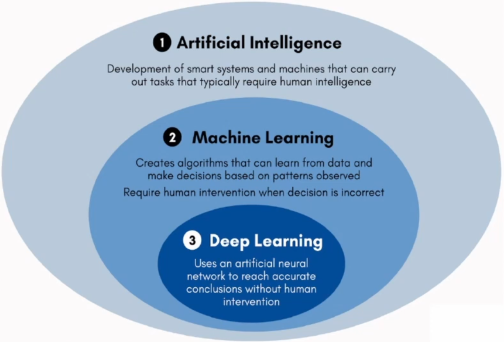

## 2. Linear regression, classification and nonlinear relationships

**Linear regression** maps a numeric input to a numeric prediction: $\hat y=\beta_0+\beta_1x$. The parameters are linear in the prediction. **Linear classification** can use a score $z=b+\mathbf x^T\mathbf w$; the decision boundary is $z=0$. A straight line (two inputs) cannot always separate curved or intertwined classes.

A **quadratic model** adds an engineered feature $x^2$:
$$\boxed{\hat y=\beta_0+\beta_1x+\beta_2x^2}.$$
Despite a curved response in $x$, the model is still *linear in its coefficients*. Neural networks learn useful nonlinear representations internally, rather than requiring every feature to be designed manually.

**Worked example.** Let $\beta_0=1$, $\beta_1=2$, $\beta_2=-0.5$ and $x=3$. Then $\hat y=1+2(3)-0.5(3)^2=2.5$. A straight-line model with $\beta_2=0$ would predict $7$ instead.

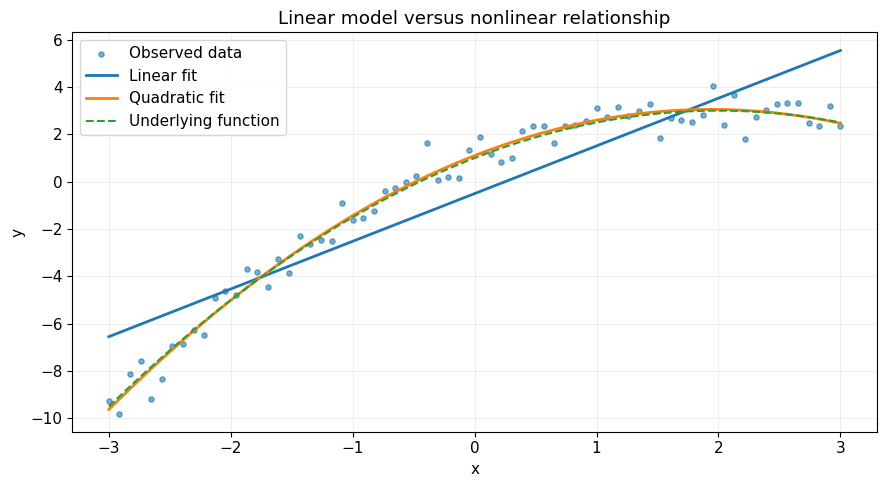

Linear coefficients: [ 2.0151 -0.5034] 
Quadratic coefficients: [-0.5201  2.0151  1.1022]
Squared errors | linear: 2.3514 | quadratic: 0.2902


In [2]:
# Plot the SAME curved dataset using linear and quadratic least squares.
x = np.linspace(-3, 3, 70)
y_true = 1 + 2*x - 0.5*x**2
y_noisy = y_true + np.random.default_rng(SEED).normal(0, 0.7, len(x))
p1 = np.polyfit(x, y_noisy, 1)
p2 = np.polyfit(x, y_noisy, 2)
plt.scatter(x, y_noisy, s=14, label='Observed data', alpha=.6)
plt.plot(x, np.polyval(p1, x), label='Linear fit', linewidth=2)
plt.plot(x, np.polyval(p2, x), label='Quadratic fit', linewidth=2)
plt.plot(x, y_true, '--', label='Underlying function')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Linear model versus nonlinear relationship')
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()
print('Linear coefficients:', p1, '\nQuadratic coefficients:', p2)
print('Squared errors | linear:', round(np.mean((np.polyval(p1, x)-y_noisy)**2), 4), '| quadratic:', round(np.mean((np.polyval(p2, x)-y_noisy)**2), 4))

## 3. Features: manual engineering versus representation learning

A feature is a numerical description of an observation. In tabular ML, features might be speed, location, backlog, or utilization. Images contain structured pixel arrays rather than a short list of hand-chosen attributes. **Manual feature extraction** can be difficult when size, viewing angle, illumination, noise and deformation vary.

Networks learn *representations*: a first image layer may respond to edges and color differences; later layers can combine simple patterns into larger parts and task-dependent structures. These are interpretations, not guaranteed labels for individual neurons. The same principle applies beyond images, including time series and manufacturing observations.

For example, a data record $s=[p,v]$ can be converted into a feature vector $\phi(s)=[1,p,v,p^2,pv]^T$. A neural network may learn nonlinear intermediate features automatically, rather than requiring an engineer to specify every interaction manually.

**Manual feature example.** For $s=[p,v]=[-0.5,0.02]$, choose $\phi(s)=[1,p,v,p^2,pv]^T=[1,-0.5,0.02,0.25,-0.01]^T$. The selected nonlinear terms introduce structure even if the final approximation is linear in weights.

In [3]:
s = np.array([-0.5, 0.02])
phi = np.array([1, s[0], s[1], s[0]**2, s[0]*s[1]])
weights = np.array([0.1, 0.5, 2.0, -1.0, 3.0])
print('State s:', s, '| engineered phi(s):', phi)
print('Linear prediction w.T @ phi(s) =', np.dot(weights, phi))

State s: [-0.5   0.02] | engineered phi(s): [ 1.   -0.5   0.02  0.25 -0.01]
Linear prediction w.T @ phi(s) = -0.39


## 4. Artificial neuron (perceptron) and forward propagation
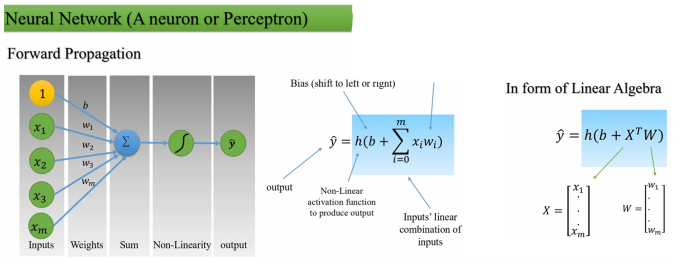

An artificial neuron receives $m$ inputs, multiplies each input by a weight, adds a bias, and applies an activation function $h$:
$$z=b+\sum_{j=1}^m x_jw_j=b+\mathbf x^T\mathbf w,\qquad\boxed{\hat y=h(z)}.$$
The bias shifts the threshold; negative weights oppose positive inputs; a nonlinear activation lets larger networks form nonlinear mappings. A traditional *binary perceptron* uses a step activation, whereas modern dense-layer units typically use ReLU, sigmoid, tanh, etc.

**Example 1.** With $b=1$, $\mathbf w=[4,-7]^T$ and $\mathbf x=[-4,6]^T$:
$$z=1+4(-4)+(-7)(6)=1-16-42=\boxed{-57}.$$
For sigmoid $\sigma(z)=1/(1+e^{-z})$, $\hat y=\sigma(-57)\approx1.76\times10^{-25}$ (nearly 0). A sigmoid output must lie strictly between 0 and 1, so a value near zero is consistent with this strongly negative preactivation.

**Example 2.** For $b=1$, $\mathbf w=[4,5,-3]^T$, and a chosen $\mathbf x=[1,2,3]^T$:
$$z=1+4(1)+5(2)-3(3)=6.$$
The zero-score boundary $1+4x_1-7x_2=0$ is a **line in 2D**. The zero-score boundary $1+4x_1+5x_2-3x_3=0$ is a **plane in 3D**. For sigmoid the $0.5$ probability contour corresponds to $z=0$.

example 1: z = -57.0 | sigmoid(z) = 1.7588e-25
example 2: z = 6.0


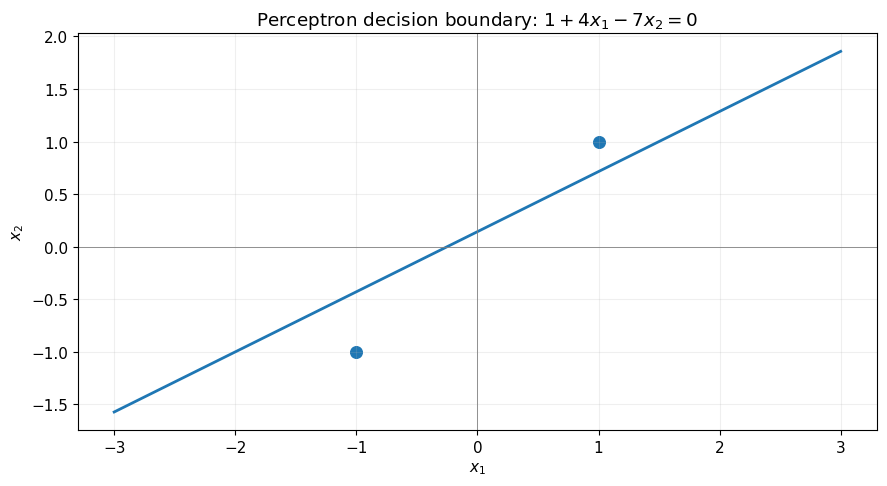

In [4]:
def sigmoid_np(z): return 1 / (1 + np.exp(-np.asarray(z)))
weights_2d = np.array([4., -7.])
x_example = np.array([-4., 6.])
z_example = 1 + x_example @ weights_2d
print('example 1: z =', z_example, '| sigmoid(z) =', f'{sigmoid_np(z_example):.4e}')
weights_3d = np.array([4., 5., -3.])
print('example 2: z =', 1 + np.array([1., 2., 3.]) @ weights_3d)
assert z_example == -57

x1 = np.linspace(-3, 3, 100)
x2_boundary = (1 + 4*x1)/7
plt.plot(x1, x2_boundary, linewidth=2)
plt.scatter([-1, 1], [-1, 1], s=70, label='Example input points')
plt.axhline(0, color='gray', lw=.6); plt.axvline(0, color='gray', lw=.6)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.title('Perceptron decision boundary: $1+4x_1-7x_2=0$')
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

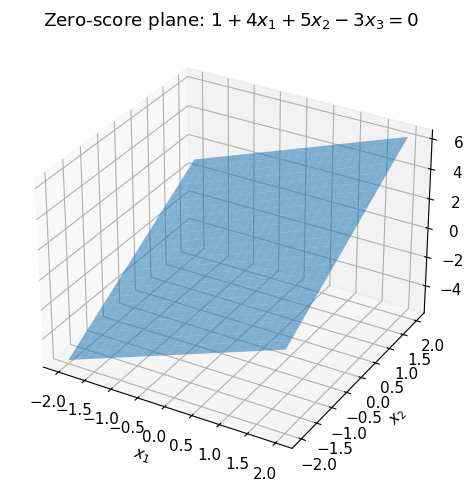

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection
xx1, xx2 = np.meshgrid(np.linspace(-2, 2, 24), np.linspace(-2, 2, 24))
xx3 = (1 + 4*xx1 + 5*xx2)/3
fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, xx3, alpha=.55)
ax.set(xlabel='$x_1$', ylabel='$x_2$', zlabel='$x_3$', title='Zero-score plane: $1+4x_1+5x_2-3x_3=0$')
plt.tight_layout(); plt.show()

### 4.1 Exactly what is a neuron, a perceptron, a layer, and a network?

These names describe different levels of organization. Do **not** confuse the number of *neurons* with the number of *layers*.

1. **An artificial neuron (a computational unit)** accepts a vector of inputs. For every input it has a weight; it adds a bias and applies an activation. The neuron performs **one scalar mapping** $\mathbb R^m\to\mathbb R$ if it has one scalar output.
2. **A perceptron** was originally a particular linear threshold classifier: a neuron with a **hard step** function $H(z)$, giving 0 or 1. The word *perceptron* is also sometimes used informally for an artificial neuron; the mathematical distinction matters when training because the step function has no useful derivative for gradient-based backpropagation.
3. **A layer** is a group of neurons that receive the same layer input and compute their outputs in parallel. A group can have **one neuron**. Thus a single neuron **can constitute a layer of width 1**. For three inputs and two neurons, both outputs form **one dense layer of width 2**, not two layers.
4. **A single-layer network** in the common machine-learning convention has **one trainable layer** (the output layer) and **zero hidden layers**. Example: $3$ input features $\to 2$ output neurons. The input coordinates are not trainable neurons: they merely supply data.
5. **A single-hidden-layer network** has one intermediate trainable layer and then a trainable output layer. Hence it has **two trainable layers**. Depending on the text, it may be called a two-layer network or a network with one hidden layer.
6. **A deep neural network (DNN)** stacks several trainable layers, typically with nonlinear activations between them. Naming conventions differ about counting the input layer, so always specify the number of *hidden* or *trainable* layers explicitly.

| Architecture | Trainable dense layers | Hidden layers | Trainable neurons | Example PyTorch modules |
|---|---:|---:|---:|---|
| One neuron with 3 inputs | 1 | 0 | 1 | `nn.Linear(3, 1)` |
| Three inputs, two outputs | 1 | 0 | 2 | `nn.Linear(3, 2)` |
| Inputs → 3 hidden neurons → 1 output | 2 | 1 | 4 | `nn.Linear(2,3)`, `nn.Linear(3,1)` |
| Inputs → 4 hidden → 3 hidden → 1 output | 3 | 2 | 8 | three consecutive linear layers |

**Inputs versus neurons.** A drawing may show a yellow circle labeled 1 beside the $x_i$. That is a *constant bias input*, not an extra data feature and not a hidden neuron. The bias is included through a parameter $b$ or a constant $x_0=1$ with weight $w_0=b$, but we should not count it twice.

**When does the word 'activation' apply?** A neuron first produces its **preactivation** or logit $z=\sum_jw_jx_j+b$, then its **activation/output** $a=h(z)$. For a logistic binary classifier, $a$ can be interpreted as $P(y=1\mid x)$ if the model is appropriately trained; raw $z$ is not a probability.

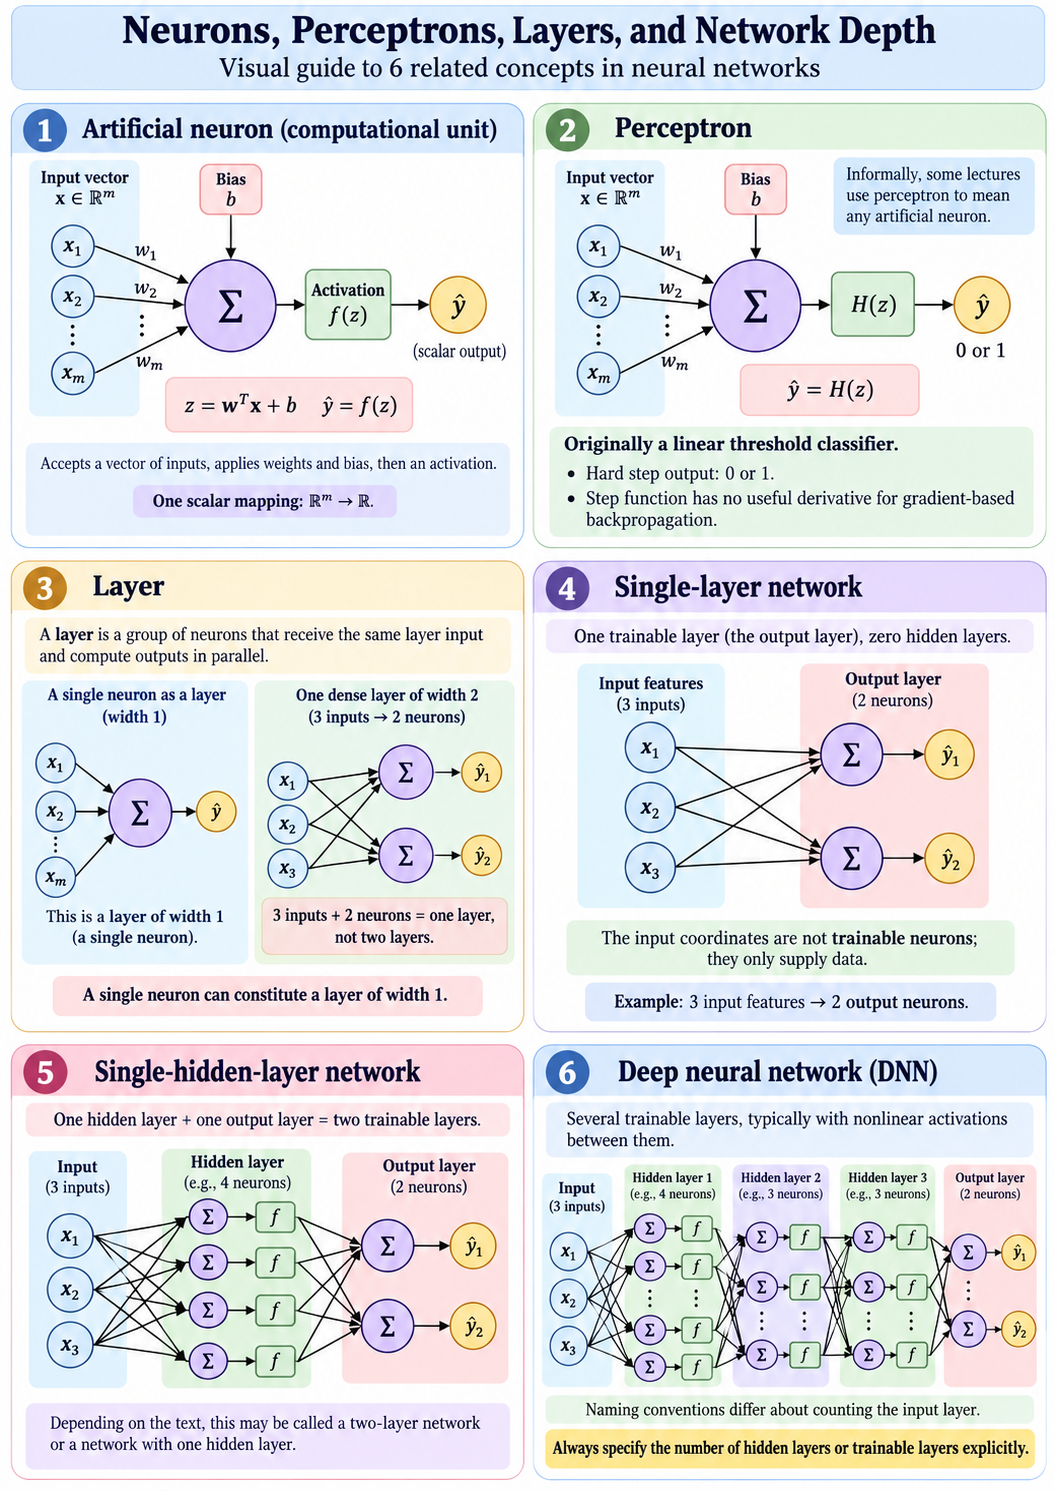

### 4.2 Single-neuron forward propagation, step by step

Consider **three input features** $x_1,x_2,x_3$ and one neuron. We begin with a scalar formula and then its vector form:

$$z=w_1x_1+w_2x_2+w_3x_3+b,\qquad a=h(z)$$
$$\mathbf x=\begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix},\quad
\mathbf w=\begin{bmatrix}w_1\\w_2\\w_3\end{bmatrix},\quad
z=\mathbf w^T\mathbf x+b.$$

**Numerical example (before any learning).** Let $\mathbf x=[2,1,3]^T$, $\mathbf w=[0.5,-1,0.2]^T$ and $b=0.1$.

- Weighted contribution from input 1: $x_1w_1=2(0.5)=1$.
- Weighted contribution from input 2: $x_2w_2=1(-1)=-1$.
- Weighted contribution from input 3: $x_3w_3=3(0.2)=0.6$.
- Add bias: $z=1-1+0.6+0.1=\boxed{0.7}$.
- With **identity activation**, $a=z=0.7$ (useful for unrestricted regression).
- With **ReLU**, $a=\max(0,0.7)=0.7$.
- With **sigmoid**, $a=\sigma(0.7)=1/(1+e^{-0.7})\approx\boxed{0.66819}$.
- With **hard step** $H(z)=1$ when $z\ge0$ and 0 otherwise, $a=1$.

The neuron **has not learned anything yet**; it has only computed a prediction using supplied weights. The desired value (label/target) is needed **only when training**. The label is not an input to the forward pass.

**Geometric perspective.** With two features, $z=0$ defines a line; with three, a plane. For sigmoid, the threshold $a=0.5$ coincides with $z=0$. The sigmoid changes the score smoothly into $(0,1)$ but **does not make a single neuron's decision boundary nonlinear**.

Individual x*w products: [ 1.  -1.   0.6] | sum: 0.6000000000000001 | bias: 0.1
Preactivation: 0.7000000000000001 | identity: 0.7000000000000001 | ReLU: 0.7000000000000001 | sigmoid: 0.6681877721681662


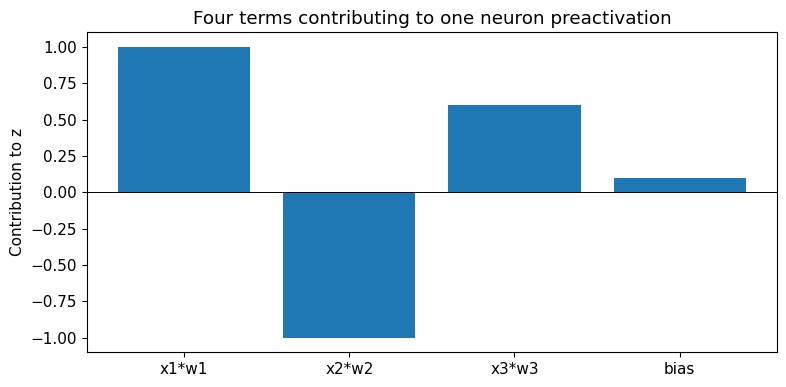

In [6]:
x_one = np.array([2., 1., 3.]); w_one = np.array([.5, -1., .2]); b_one = .1
contributions = x_one*w_one
z_one = contributions.sum()+b_one
print('Individual x*w products:', contributions, '| sum:', contributions.sum(), '| bias:', b_one)
print('Preactivation:', z_one, '| identity:', z_one, '| ReLU:', max(0.,z_one), '| sigmoid:', float(sigmoid_np(z_one)))
plt.figure(figsize=(8, 4)); plt.bar(['x1*w1','x2*w2','x3*w3','bias'], [*contributions,b_one])
plt.axhline(0,c='black',lw=.7); plt.title('Four terms contributing to one neuron preactivation')
plt.ylabel('Contribution to z'); plt.tight_layout(); plt.show()
assert np.isclose(z_one,.7)

### 4.3 What can a single threshold neuron classify? What can it not classify?

For two features, consider $H(w_1x_1+w_2x_2+b)$. The weight vector controls the **orientation** of a straight decision boundary. The bias controls its **position**. A single threshold neuron can represent the AND and OR logic functions by choosing suitable weights. However, one straight line **cannot separate the XOR pattern**: the positive labels lie at opposite corners of the unit square.

For XOR, $y=1$ at $(1,0)$ and $(0,1)$, and $y=0$ at $(0,0)$ and $(1,1)$. A hidden layer with nonlinear units can represent this relation.

**Step 1: Define the hidden neurons**

Consider two hidden neurons using the ReLU activation function:

- **Hidden neuron 1 ($h_1$):** Weights $w_1=1,\ w_2=1$, bias $b_1=0$.
- **Hidden neuron 2 ($h_2$):** Weights $w_1=1,\ w_2=1$, bias $b_2=-1$.

Using the neuron equation:

$$h=\operatorname{ReLU}(w_1x_1+w_2x_2+b)$$

We obtain:

$$\boxed{h_1=\operatorname{ReLU}(x_1+x_2)}$$

$$\boxed{h_2=\operatorname{ReLU}(x_1+x_2-1)}$$

These hidden-layer weights and biases are manually selected for this XOR construction.

**Step 2: Calculate hidden neuron outputs**

Recall that $\operatorname{ReLU}(z)=\max(0,z)$. Calculate both hidden outputs for every XOR input:

| $x_1$ | $x_2$ | $h_1$ | $h_2$ | Target $y$ |
|---|---|---|---|---|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | 0 | 1 |
| 1 | 0 | 1 | 0 | 1 |
| 1 | 1 | 2 | 1 | 0 |

**Step 3: Determine the output neuron's weights and bias**

The output neuron receives $h_1$ and $h_2$ as inputs and uses a linear activation function:

$$\hat y=w_1^{(o)}h_1+w_2^{(o)}h_2+b_o$$

We need to determine $w_1^{(o)}$, $w_2^{(o)}$, and $b_o$ so that the predictions match the XOR targets.

**Case 1:** Input $(x_1,x_2)=(0,0)$ gives $h_1=0$, $h_2=0$, and target $y=0$.

$$0=w_1^{(o)}(0)+w_2^{(o)}(0)+b_o$$

Therefore:

$$\boxed{b_o=0}$$

**Case 2:** Input $(x_1,x_2)=(0,1)$ gives $h_1=1$, $h_2=0$, and target $y=1$.

$$1=w_1^{(o)}(1)+w_2^{(o)}(0)+0$$

Therefore:

$$\boxed{w_1^{(o)}=1}$$

**Case 3:** Input $(x_1,x_2)=(1,1)$ gives $h_1=2$, $h_2=1$, and target $y=0$.

$$0=w_1^{(o)}(2)+w_2^{(o)}(1)+0$$

Substituting $w_1^{(o)}=1$:

$$0=2+w_2^{(o)}$$

Therefore:

$$\boxed{w_2^{(o)}=-2}$$

**Step 4: Construct the final output equation**

The output-layer parameters are:

$$w_1^{(o)}=1,\qquad w_2^{(o)}=-2,\qquad b_o=0$$

Substituting into the output neuron equation:

$$\hat y=w_1^{(o)}h_1+w_2^{(o)}h_2+b_o$$

$$\hat y=1(h_1)-2(h_2)+0$$

$$\boxed{\hat y=h_1-2h_2}$$

**Step 5: Verify all four XOR inputs**

- $(0,0)\rightarrow 0-2(0)=0$
- $(0,1)\rightarrow 1-2(0)=1$
- $(1,0)\rightarrow 1-2(0)=1$
- $(1,1)\rightarrow 2-2(1)=0$

Every prediction matches the XOR target.

Here, **two neurons form a hidden layer** and a third neuron forms the output layer. Their composition is a **two-trainable-layer network**, despite having three neurons in total.

**Important:** The hidden-layer parameters were manually selected, and the output-layer parameters were derived by solving equations using the XOR targets. During ordinary neural network training, the weights and biases are generally initialized and learned through backpropagation and optimization rather than constructed manually.

,x1,x2,true XOR,two-layer prediction
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0


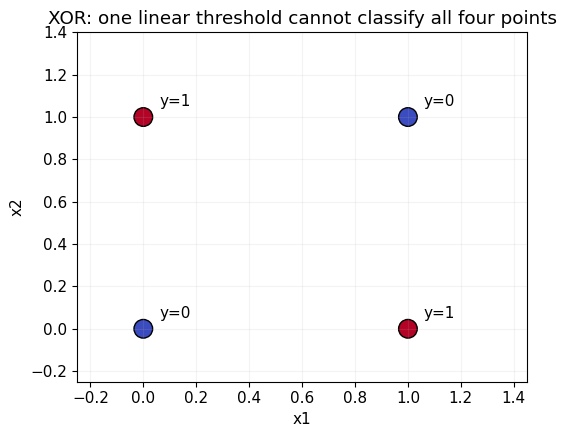

In [7]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]],dtype=float)
y_xor = np.array([0,1,1,0],dtype=float)
h_xor = np.maximum(0,X_xor.sum(axis=1))-2*np.maximum(0,X_xor.sum(axis=1)-1)
display(pd.DataFrame({'x1':X_xor[:,0].astype(int),'x2':X_xor[:,1].astype(int),'true XOR':y_xor.astype(int),'two-layer prediction':h_xor.astype(int)}))
fig, ax = plt.subplots(figsize=(5.5,4.5)); ax.scatter(X_xor[:,0],X_xor[:,1],c=y_xor,cmap='coolwarm',s=180,ec='black')
for (xx,yy),target in zip(X_xor,y_xor): ax.text(xx+.06,yy+.05,f'y={int(target)}')
ax.set_xlim(-.25,1.45);ax.set_ylim(-.25,1.4);ax.set_xlabel('x1');ax.set_ylabel('x2');ax.set_title('XOR: one linear threshold cannot classify all four points')
ax.grid(alpha=.15);plt.tight_layout();plt.show()
assert np.array_equal(h_xor,y_xor)

## 5. Activation functions, their derivatives, and vanishing gradients

| Activation | Formula $h(z)$ | Derivative $h'(z)$ (where defined) | Range and common use |
|---|---|---|---|
| Identity | $z$ | $1$ | Unbounded regression output |
| Sigmoid | $1/(1+e^{-z})$ | $h(z)(1-h(z))$ | $(0,1)$; binary probability |
| Tanh | $(e^z-e^{-z})/(e^z+e^{-z})$ | $1-\tanh^2(z)$ | $(-1,1)$; centered hidden values |
| ReLU | $\max(0,z)$ | $0$ for $z<0$, $1$ for $z>0$ | $[0,\infty)$; common hidden activation |
| Leaky ReLU | $\max(\varepsilon z,z)$ | $\varepsilon$ for $z<0$, $1$ for $z>0$ | Negative slope reduces dead units |



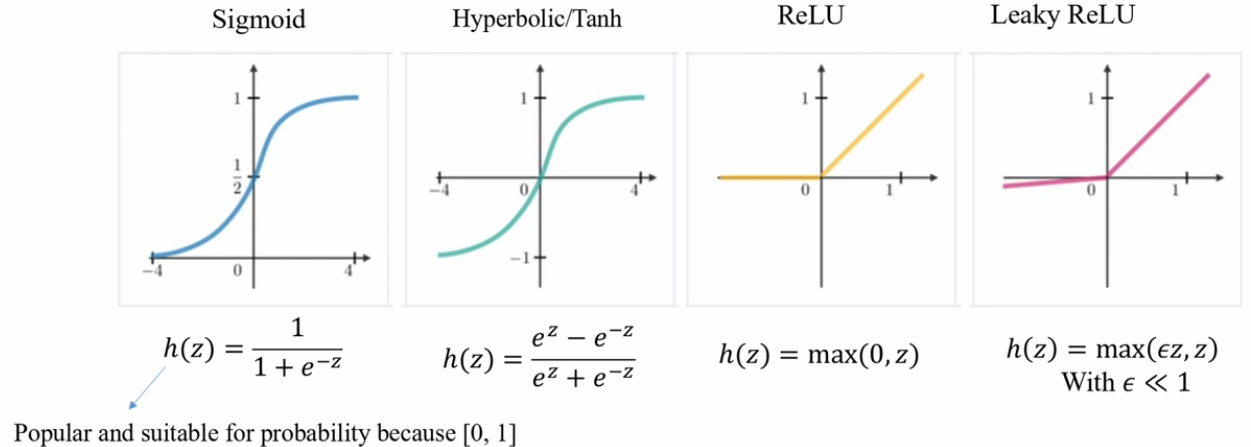

ReLU is **\*\*piecewise linear\*\***, but is not a single linear function over all real inputs. It is unbounded above; this is not automatically a disadvantage. Sigmoid and tanh *\*saturate\** for large $|z|$, causing their derivatives to approach 0. During backpropagation, derivatives from many layers multiply and can produce **\*\*vanishing gradients\*\***. A ReLU derivative is 0 for negative preactivations, producing the possible *\*dying ReLU\** problem. Leaky ReLU allows a small negative gradient.

**\*\*Manual gradient example.\*\*** Suppose eight successive sigmoid units are each at $z=0$. Then $\sigma'(0)=0.25$. The product of these derivatives is $(0.25)^8=1/65{,}536\approx1.526\times10^{-5}$; this is a simple illustration, not a universal gradient formula. With $z=5$, $\sigma'(5)\approx0.006648$, even smaller.

*\*Batch normalization\** can help optimization by normalizing batchwise intermediate activations and applying learned scale and shift. It does **\*\*not\*\*** cap ReLU outputs or eliminate all vanishing gradients; its train and evaluation behavior differ.


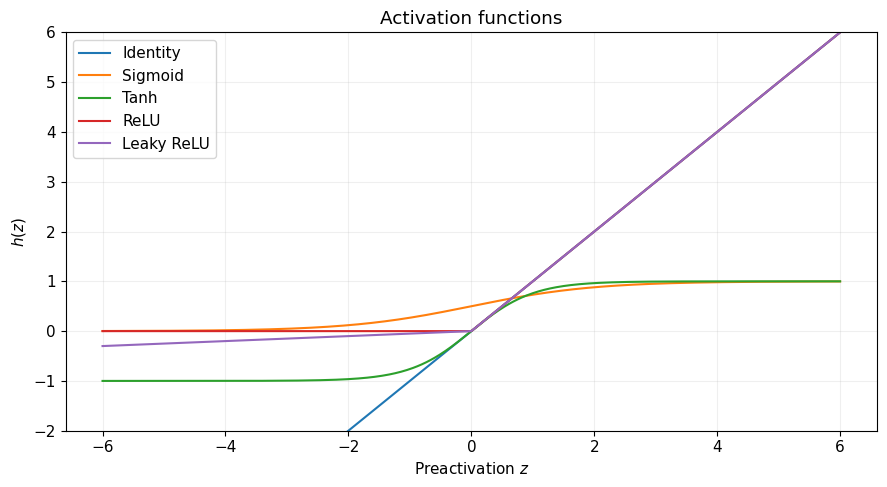

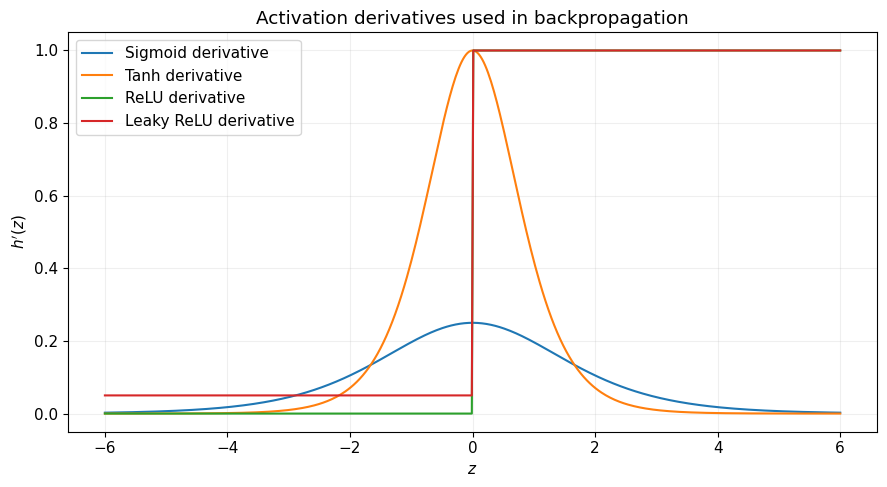

Sigmoid(5) derivative: 0.006648056670790033
Eight sigmoid derivatives at zero: 1.52587890625e-05


In [8]:
z = np.linspace(-6, 6, 500)
activations = {'Identity': z, 'Sigmoid': sigmoid_np(z), 'Tanh': np.tanh(z), 'ReLU': np.maximum(0, z), 'Leaky ReLU': np.maximum(.05*z, z)}
for name, value in activations.items(): plt.plot(z, value, label=name)
plt.title('Activation functions'); plt.xlabel('Preactivation $z$'); plt.ylabel('$h(z)$'); plt.ylim(-2, 6)
plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

sg = sigmoid_np(z)
derivatives = {'Sigmoid derivative': sg*(1-sg), 'Tanh derivative': 1-np.tanh(z)**2, 'ReLU derivative': (z>0).astype(float), 'Leaky ReLU derivative': np.where(z<0, .05, 1.)}
for name, value in derivatives.items(): plt.plot(z, value, label=name)
plt.title('Activation derivatives used in backpropagation'); plt.xlabel('$z$'); plt.ylabel("$h'(z)$")
plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()
print('Sigmoid(5) derivative:', float(sigmoid_np(5)*(1-sigmoid_np(5))))
print('Eight sigmoid derivatives at zero:', .25**8)

### 5.1 Activation functions: why a stack of only linear layers is still linear

Suppose each layer is *identity activated*, so $a^{(1)}=W_1x+b_1$ and $a^{(2)}=W_2a^{(1)}+b_2$. Substitute the first into the second:

$$a^{(2)}=W_2(W_1x+b_1)+b_2=\underbrace{(W_2W_1)}_{W_{\rm effective}}x+\underbrace{(W_2b_1+b_2)}_{b_{\rm effective}}.$$

Thus even twenty linear layers collapse to **one affine map**. Nonlinear activations are what allow the network to learn curved and discontinuous-like relationships. Individual activation functions can be linear (the identity is one), so it is incorrect to say that every activation function is nonlinear.

**Activation-by-activation interpretation.** For a fixed preactivation $z$:

- **Step:** $H(z)=\mathbf1\{z\ge0\}$; good for describing old-style perceptron decisions, but unsuitable for ordinary gradient descent since the derivative is 0 almost everywhere and undefined at 0.
- **Identity:** $h(z)=z$; often chosen at regression outputs because values need not lie in $[0,1]$.
- **Sigmoid:** $\sigma(z)=1/(1+e^{-z})$; often converts one binary-class logit into a probability.
- **Tanh:** $\tanh(z)\in(-1,1)$; centered around zero, but derivatives can vanish in saturated regions.
- **ReLU:** $\max(0,z)$; has a derivative of 1 for $z>0$ and 0 for $z<0$. PyTorch chooses derivative 0 at $z=0$ as a practical subgradient convention.
- **Leaky ReLU:** $\max(\alpha z,z)$, commonly with small $\alpha>0$; passes a nonzero gradient for negative inputs, reducing the chance of a permanently inactive unit.
- **Softmax:** acts on a *vector* of logits, turning them into positive probabilities that sum to 1. It is different from applying sigmoid separately to each mutually exclusive class.

**Output ranges matter, but are not limits on all architectures.** ReLU is unbounded above: $\operatorname{ReLU}(100)=100$. Sigmoid is bounded between 0 and 1: $\sigma(100)\approx1$. Batch normalization does **not** clamp a ReLU to a finite range.

### 5.2 Derive the activation derivatives used during backpropagation

**Sigmoid**: let $\sigma(z)=(1+e^{-z})^{-1}$. By the chain rule,

$$\sigma'(z)=-(1+e^{-z})^{-2}(-e^{-z})=\frac{e^{-z}}{(1+e^{-z})^2}.$$

Because $\sigma(z)=1/(1+e^{-z})$ and $1-\sigma(z)=e^{-z}/(1+e^{-z})$:

$$\boxed{\sigma'(z)=\sigma(z)[1-\sigma(z)]}. $$

This immediately shows $0<\sigma'(z)\le1/4$, with the largest derivative at $z=0$. If $z=5$, then $\sigma(5)\approx0.993307$ and $\sigma'(5)\approx0.006648$. In the saturated region the neuron changes its output very little when its input changes.

**Tanh**: $\tanh(z)=(e^z-e^{-z})/(e^z+e^{-z})$. Differentiating with the quotient rule yields

$$\boxed{\frac{d}{dz}\tanh(z)=1-\tanh^2(z)}.$$

Its derivative is 1 at 0 but tends to 0 for large positive or negative inputs.

**ReLU**: $h(z)=\max(0,z)$,

$$h'(z)=\begin{cases}0&z<0\\1&z>0\end{cases}.$$

At $z=0$ the classical derivative does not exist; a numerical library chooses a subgradient. ReLU avoids the sigmoid's small positive-side slopes but **can suppress all gradients** for a unit stuck with negative inputs. Leaky ReLU substitutes $\alpha$ (not zero) for the negative-side slope.

**Why derivatives matter:** during training, the loss derivative with respect to a weight includes the activation derivative, not just the activation value. For a single neuron $a=h(wx+b)$ and loss $L(a,y)$,

$$\boxed{\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\;h'(z)\;x,\qquad \frac{\partial L}{\partial b}=\frac{\partial L}{\partial a}\;h'(z)}.$$

These formulas make the mechanism of vanishing gradients much easier to understand.

### 5.3 Vanishing gradient: meaning, chain-rule origin, and a complete numerical example

**Definition.** A vanishing gradient occurs when the derivatives reaching early neural-network parameters become extremely small. Training updates $\Delta w=-\eta\,\partial L/\partial w$ are then nearly zero, so these early parameters learn very slowly. This is a property of **backward signals**, not necessarily of the *forward activation numbers* becoming smaller. Normalizing data to $[0,1]$ is **not** itself the mathematical cause.

Consider an $L$-layer scalar neural network:

$$a_0=x,\qquad z_\ell=w_\ell a_{\ell-1}+b_\ell,\qquad a_\ell=\sigma(z_\ell).$$

Choose half-squared error $\mathcal L=\tfrac12(a_L-y)^2$. To differentiate the **first weight** $w_1$, trace every edge between $w_1$ and the loss:

$$\frac{\partial\mathcal L}{\partial w_1}
=\underbrace{(a_L-y)}_{\partial\mathcal L/\partial a_L}
\underbrace{\sigma'(z_L)w_L}_{\partial a_L/\partial a_{L-1}}
\underbrace{\sigma'(z_{L-1})w_{L-1}}_{\partial a_{L-1}/\partial a_{L-2}}\cdots
\underbrace{\sigma'(z_2)w_2}_{\partial a_2/\partial a_1}
\underbrace{\sigma'(z_1)x}_{\partial a_1/\partial w_1}.$$

At $z_\ell=0$ for every layer, $\sigma'(z_\ell)=0.25$; set all weights to 1. The **derivative multiplier** for eight sigmoid activations is

$$\left(\frac14\right)^8=\frac1{65{,}536}=\boxed{0.0000152587890625}.$$

If the final output $a_8=0.5$ and target $y=0$, the output error is $a_8-y=0.5$. With first input $x=1$:

$$\frac{\partial\mathcal L}{\partial w_1}=0.5\times(0.25)^8\times1
=\boxed{0.00000762939453125}.$$

With $\eta=0.1$, the **first-layer update** is only

$$\Delta w_1=-0.1(0.00000762939453125)\approx-0.00000076294.$$

Compare the **last weight** $w_8$, which receives the previous activation $a_7=0.5$:

$$\frac{\partial\mathcal L}{\partial w_8}=(0.5)(0.25)(0.5)=\boxed{0.0625},\quad
\Delta w_8=-0.00625.$$

In this controlled example the gradient at the **last** weight is $8192$ times larger than the gradient at the **first** weight. The code constructs precisely this eight-layer sigmoid chain and checks these numbers using PyTorch automatic differentiation. Other networks can show different magnitudes because the weight matrices also influence the gradient product.

Layers= 1 | y_hat=0.500000 | first gradient=0.125 | last gradient=0.12500000
Layers= 2 | y_hat=0.500000 | first gradient=0.03125 | last gradient=0.06250000
Layers= 4 | y_hat=0.500000 | first gradient=0.001953125 | last gradient=0.06250000
Layers= 8 | y_hat=0.500000 | first gradient=7.629394531e-06 | last gradient=0.06250000
Layers=12 | y_hat=0.500000 | first gradient=2.980232239e-08 | last gradient=0.06250000
Layers=20 | y_hat=0.500000 | first gradient=4.547473509e-13 | last gradient=0.06250000


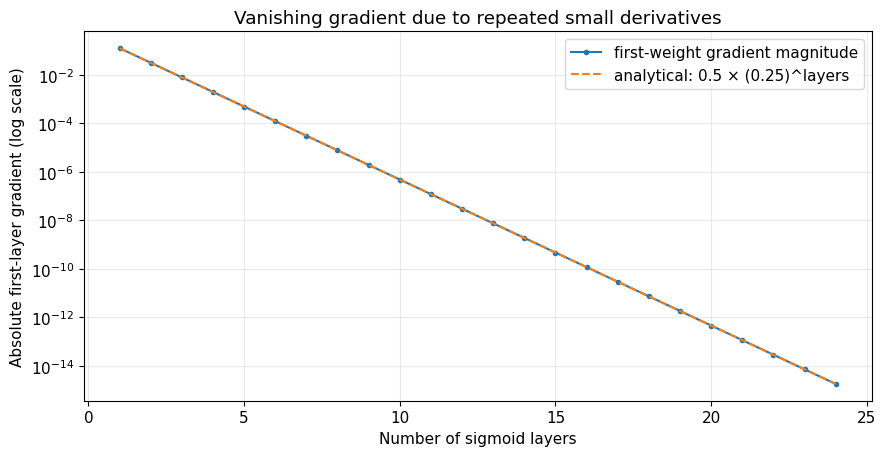

In [9]:
# Exact vanishing-gradient example: bias chosen so EVERY sigmoid preactivation is zero.
def sigmoid_chain_gradients(depth):
    w = [torch.tensor(1., requires_grad=True) for _ in range(depth)]
    a = torch.tensor(1.)
    for k in range(depth):
        bias = -1. if k==0 else -.5
        a = torch.sigmoid(w[k]*a+bias)
    loss = .5*a.square()  # target y=0
    loss.backward()
    return a.item(), loss.item(), np.array([v.grad.item() for v in w])

for depth in [1,2,4,8,12,20]:
    pred, loss, gradients = sigmoid_chain_gradients(depth)
    print(f'Layers={depth:2d} | y_hat={pred:.6f} | first gradient={gradients[0]:.10g} | last gradient={gradients[-1]:.8f}')
_,_,g8 = sigmoid_chain_gradients(8)
assert np.isclose(g8[0], .5*.25**8, rtol=1e-5)
assert np.isclose(g8[-1], .0625, rtol=1e-5)
levels = np.arange(1,25)
first = np.array([sigmoid_chain_gradients(int(n))[2][0] for n in levels])
plt.figure(figsize=(9,4.7));plt.semilogy(levels,first,marker='o',ms=3,label='first-weight gradient magnitude')
plt.semilogy(levels,.5*(.25**levels),ls='--',label='analytical: 0.5 × (0.25)^layers')
plt.xlabel('Number of sigmoid layers');plt.ylabel('Absolute first-layer gradient (log scale)')
plt.title('Vanishing gradient due to repeated small derivatives');plt.legend();plt.grid(alpha=.25);plt.tight_layout();plt.show()

### 5.4 What helps with vanishing gradients? What does not guarantee a fix?

1. **ReLU / Leaky ReLU in hidden layers:** For *active* ReLU units, $h'(z)=1$ rather than at most 0.25. Leaky ReLU also has a nonzero negative-side gradient. However, even a ReLU network may have vanishing gradients because of the weights, depth, or inactive units.
2. **Suitable initialization:** Xavier/Glorot initialization is often used for symmetric, smooth activations. He/Kaiming initialization is commonly used for ReLU-based networks. Their goal is to control how signal and gradient variance change through layers, rather than starting from arbitrarily huge/small weights.
3. **Residual (skip) connections:** If a block computes $y=x+F(x)$, then $\partial y/\partial x=I+\partial F/\partial x$. The direct identity pathway offers an additional gradient route and helps train deeper networks. It does not guarantee all gradients stay healthy.
4. **Normalization:** BatchNorm or LayerNorm can improve training stability and help keep activations in workable regimes. For small mini-batches, BatchNorm statistics can become noisy; LayerNorm or other architectures may be preferable.
5. **Gated recurrent models:** LSTMs and GRUs are designed to help carry useful information and gradients through long sequences, compared with simple RNNs.
6. **Check gradients in practice:** monitor per-layer gradient norms and fractions of dead ReLU activations rather than assuming training is fine because the loss prints a number.

**Do not confuse issues.** *Gradient clipping* is primarily a remedy for **exploding** gradients (unusually large gradients), not for vanishing gradients. Increasing the learning rate cannot restore a derivative that is essentially zero. Batch normalization does not cap ReLU outputs to $[0,1]$.

## 6. Dense layers and multi-output perceptrons

A dense layer sends each of its $m$ inputs to each of its $k$ output neurons. With input $\mathbf x\in\mathbb R^m$, weights $W\in\mathbb R^{k\times m}$ and biases $\mathbf b\in\mathbb R^k$ (PyTorch's convention):
$$\boxed{\mathbf z=W\mathbf x+\mathbf b,\quad\mathbf a=h(\mathbf z)}.$$
For output neuron $i$, $z_i=b_i+\sum_{j=1}^{m}W_{ij}x_j$. A dense layer has **$mk+k$ trainable parameters** (all connections plus one bias per output). Another equivalent convention uses $w_{j,i}$ and a transposed weight matrix; specify dimensions to avoid ambiguity.

**Manual example:** $\mathbf x=[1,2,3]^T$; $W=\begin{bmatrix}1&0&-1\\0.5&2&1\end{bmatrix}$, $\mathbf b=[0.5,-1]^T$.
$$z_1=1(1)+0(2)-1(3)+0.5=-1.5,\qquad z_2=0.5(1)+2(2)+1(3)-1=6.5.$$
ReLU gives $\mathbf a=[0,6.5]^T$. Number of parameters $=2(3)+2=8$. Code below checks hand calculations against `nn.Linear(3,2)`.

In [10]:
x_dense = torch.tensor([1., 2., 3.])
W_dense = torch.tensor([[1., 0., -1.], [.5, 2., 1.]])
b_dense = torch.tensor([.5, -1.])
manual_z = W_dense @ x_dense + b_dense
layer = nn.Linear(3, 2)
with torch.no_grad():
    layer.weight.copy_(W_dense)
    layer.bias.copy_(b_dense)
print('Hand preactivations:', manual_z.numpy(), '| PyTorch:', layer(x_dense).detach().numpy())
print('After ReLU:', F.relu(layer(x_dense)).detach().numpy(), '| parameters:', sum(p.numel() for p in layer.parameters()))
assert torch.allclose(manual_z, layer(x_dense))

Hand preactivations: [-1.5  6.5] | PyTorch: [-1.5  6.5]
After ReLU: [0.  6.5] | parameters: 8


### 6.1 From one neuron to an entire dense layer: every matrix entry

Suppose there are $m=3$ input features and $k=2$ output neurons. The first output neuron has its **own** weights $(w_{11},w_{12},w_{13})$ and bias $b_1$. The second has a separate weight set $(w_{21},w_{22},w_{23})$ and bias $b_2$:

$$z_1=w_{11}x_1+w_{12}x_2+w_{13}x_3+b_1,$$
$$z_2=w_{21}x_1+w_{22}x_2+w_{23}x_3+b_2.$$

Combine these two equations as **one matrix multiplication**:

$$\begin{bmatrix}z_1\\z_2\end{bmatrix}=
\underbrace{\begin{bmatrix}w_{11}&w_{12}&w_{13}\\w_{21}&w_{22}&w_{23}\end{bmatrix}}_{W\in\mathbb R^{2\times3}}
\underbrace{\begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix}}_{x\in\mathbb R^{3\times1}}+
\underbrace{\begin{bmatrix}b_1\\b_2\end{bmatrix}}_{b\in\mathbb R^{2}}.$$

For the existing worked example $x=[1,2,3]^T$, $W=\begin{bmatrix}1&0&-1\\0.5&2&1\end{bmatrix}$ and $b=[0.5,-1]^T$:

$$z_1=1(1)+0(2)-1(3)+0.5=-1.5,$$
$$z_2=0.5(1)+2(2)+1(3)-1=6.5.$$

After ReLU, $a_1=0$ and $a_2=6.5$. The group of **two neurons is still one layer**, and its 3-by-2 connections plus two biases give $3(2)+2=\boxed{8}$ trainable parameters.

**Batch notation:** With $N$ data points organized as rows, $X\in\mathbb R^{N\times3}$, the output matrix is $Z=XW^T+b$ with shape $N\times2$ (bias broadcast across rows). PyTorch uses `nn.Linear(in_features=3, out_features=2)` and stores weights in $[\text{out},\text{in}]$ order; some mathematical conventions write $W$ transposed. These conventions represent the same linear transform when dimensions are consistent.

**Trainable layer vs activation:** `nn.Linear(...)` supplies weights and biases; `nn.ReLU()` performs a nonlinearity but does not add trainable weights. Counting trainable layers is about the parameterized operations, not the number of Python modules.

In [11]:
# Verify matrix orientation for a BATCH of observations, and show each output explicitly.
X_dense_batch = torch.tensor([[1.,2.,3.],[2.,0.,1.]])
Z_dense_batch = X_dense_batch @ W_dense.T + b_dense
for row_idx, xx in enumerate(X_dense_batch):
    first = sum(float(xx[j]*W_dense[0,j]) for j in range(3)) + float(b_dense[0])
    second = sum(float(xx[j]*W_dense[1,j]) for j in range(3)) + float(b_dense[1])
    print(f'Sample {row_idx+1} | z1={first:.3f}, z2={second:.3f} | matrix={Z_dense_batch[row_idx].tolist()}')
print('Input shape:',tuple(X_dense_batch.shape),'| weight shape:',tuple(W_dense.shape),'| output shape:',tuple(Z_dense_batch.shape))
assert torch.allclose(Z_dense_batch, layer(X_dense_batch))

Sample 1 | z1=-1.500, z2=6.500 | matrix=[-1.5, 6.5]
Sample 2 | z1=1.500, z2=1.000 | matrix=[1.5, 1.0]
Input shape: (2, 3) | weight shape: (2, 3) | output shape: (2, 2)


## 7. One-hidden-layer ANN, deep ANN and universal approximation

A network with **one hidden layer** computes:
$$\mathbf a^{(1)}=h_1(W^{(1)}\mathbf x+\mathbf b^{(1)}),\qquad
\hat{\mathbf y}=h_2(W^{(2)}\mathbf a^{(1)}+\mathbf b^{(2)}).$$
A deeper network repeats $\mathbf a^{(\ell)}=h_\ell(W^{(\ell)}\mathbf a^{(\ell-1)}+\mathbf b^{(\ell)})$, with $\mathbf a^{(0)}=\mathbf x$. The number of hidden layers determines *depth*; their widths determine the numbers of intermediate units. For architecture $2\rightarrow3\rightarrow2$, the parameter count is $(2\cdot3+3)+(3\cdot2+2)=17$.

**Universal approximation — precise meaning.** Under standard conditions on the activation, a single sufficiently wide hidden layer can approximate any *continuous* function arbitrarily closely on a compact domain. This is an *existence statement*, not a guarantee of efficient training, good extrapolation, or a small network.

**Worked forward pass:** $\mathbf x=[1,-1]^T$; hidden weights $W^{(1)}=\begin{bmatrix}1&2\\-1&1\end{bmatrix}$, $\mathbf b^{(1)}=[0,1]^T$, hidden ReLU. Then $\mathbf z^{(1)}=[-1,-1]^T$, so $\mathbf a^{(1)}=[0,0]^T$. To illustrate nonzero propagation we choose $\mathbf x=[2,1]^T$: $\mathbf z^{(1)}=[4,0]^T$, ReLU gives $[4,0]^T$; with $W^{(2)}=[0.5,-2]$ and $b^{(2)}=1$, output is $0.5(4)-2(0)+1=3$. The code verifies both inputs.

In [12]:
W1 = torch.tensor([[1., 2.], [-1., 1.]])
b1 = torch.tensor([0., 1.])
W2 = torch.tensor([[.5, -2.]])
b2 = torch.tensor([1.])
for x in [torch.tensor([1., -1.]), torch.tensor([2., 1.])]:
    z1 = W1 @ x + b1
    a1 = torch.relu(z1)
    y_hat = W2 @ a1 + b2
    print('x:', x.tolist(), '| hidden z:', z1.tolist(), '| hidden activation:', a1.tolist(), '| output:', y_hat.tolist())
assert torch.allclose(W2 @ torch.relu(W1 @ torch.tensor([2., 1.]) + b1) + b2, torch.tensor([3.]))

x: [1.0, -1.0] | hidden z: [-1.0, -1.0] | hidden activation: [0.0, 0.0] | output: [1.0]
x: [2.0, 1.0] | hidden z: [4.0, 0.0] | hidden activation: [4.0, 0.0] | output: [3.0]


### 7.1 Forward propagation across one hidden layer: a complete reference calculation

The simplest genuinely multilayer network has one **hidden layer**. Let there be two input features, two hidden neurons, and one output neuron:

$$\underbrace{\begin{bmatrix}x_1\\x_2\end{bmatrix}}_{2\text{ inputs}}
\overset{W^{(1)},b^{(1)}}{\longrightarrow}
\underbrace{\begin{bmatrix}a_1^{(1)}\\a_2^{(1)}\end{bmatrix}}_{2\text{ hidden neurons}}
\overset{W^{(2)},b^{(2)}}{\longrightarrow}
\underbrace{\hat y}_{1\text{ output}}.$$

Let $x=[1,2]^T$, $W^{(1)}=\begin{bmatrix}0.1&0.2\\0.3&-0.1\end{bmatrix}$, $b^{(1)}=[0.1,0.2]^T$, and ReLU in the hidden layer. Let $W^{(2)}=[0.5,-0.4]$, $b^{(2)}=0.1$, and an **identity activation** at the regression output. We will reuse these *same values* for the backpropagation example so every gradient can be independently checked.

**Hidden preactivations:**

$$z_1^{(1)}=0.1(1)+0.2(2)+0.1=\boxed{0.6},$$
$$z_2^{(1)}=0.3(1)-0.1(2)+0.2=\boxed{0.3}.$$

**Hidden activations:** $a_1^{(1)}=\operatorname{ReLU}(0.6)=0.6$, $a_2^{(1)}=\operatorname{ReLU}(0.3)=0.3$.

**Output:**

$$z^{(2)}=0.5(0.6)-0.4(0.3)+0.1=0.30-0.12+0.10=\boxed{0.28},$$
$$\hat y=h_2(z^{(2)})=0.28.$$

The network contains **two trainable layers** ($W^{(1)}$ and $W^{(2)}$), **one hidden layer** (the two ReLU units), and **nine trainable parameters**: first layer $2\times2+2=6$, second layer $1\times2+1=3$. We will eventually update **all nine parameters** during one backpropagation step.

**Important:** Forward propagation does not use the correct answer $y$. When training, the target arrives *after* the forward prediction and determines a loss. Hidden-layer activations are intermediate computed features, not target labels.

In [13]:
# Forward reference network, using exactly the values in the derivation.
x_ref = torch.tensor([1.,2.])
W1_ref = torch.tensor([[.1,.2],[.3,-.1]])
b1_ref = torch.tensor([.1,.2])
W2_ref = torch.tensor([[.5,-.4]])
b2_ref = torch.tensor([.1])
z_hidden_ref = W1_ref @ x_ref+b1_ref
hidden_ref = torch.relu(z_hidden_ref)
yhat_ref = (W2_ref @ hidden_ref+b2_ref).item()
print('Hidden weighted sums:',z_hidden_ref.tolist())
print('Hidden activations:',hidden_ref.tolist())
print('Network prediction:',yhat_ref)
print('Parameter count:',W1_ref.numel()+b1_ref.numel()+W2_ref.numel()+b2_ref.numel())
assert torch.allclose(z_hidden_ref,torch.tensor([.6,.3]),atol=1e-6)
assert abs(yhat_ref-.28)<1e-6

Hidden weighted sums: [0.6000000238418579, 0.30000001192092896]
Hidden activations: [0.6000000238418579, 0.30000001192092896]
Network prediction: 0.2800000011920929
Parameter count: 9


## 8. A complete supervised training example: swimming competition

**Problem.** Predict winning a swimming competition using two features: $x_1=$ swimming-practice time and $x_2=$ dryland-workout time (the observation period and units must be defined in a real application). Labels $y\in\{0,1\}$ represent loss/win. A network with 2 inputs, 3 hidden neurons and 1 sigmoid output maps training features to estimated winning probabilities.

For example, with $\mathbf x^{(1)}=[33,29]$, an *untrained* network might return $\hat y=0.1$ while $y=1$. Prediction $0.1$ means the current model assigns 10% probability to the positive class; it does **not** imply that the predicted outcome is certain. The purpose of training is to adjust weights based on many observed examples.

**Training steps.** (1) split examples into training, validation and test sets; (2) fit feature scaling on training data; (3) initialize parameters; (4) forward pass; (5) loss with labels; (6) backpropagation; (7) optimizer update; (8) repeat over epochs; (9) choose settings using validation data; (10) report test performance only at the end.

Below is an explicitly **synthetic demonstration**, *not real swimming data*. We generate labels with a hidden noisy relation to practice times, then fit an ANN. Here the observed label is supplied by the dataset, so the gradient is computed against that label.

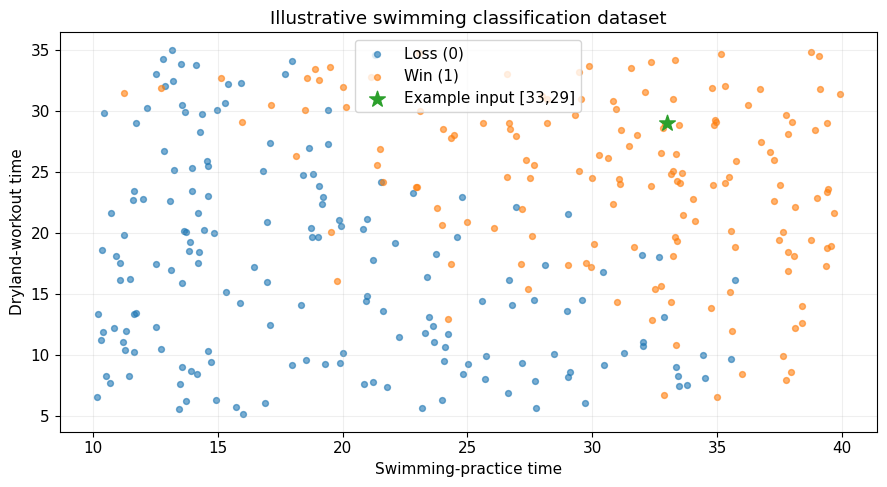

Train / validation / test sizes: 192 64 64


In [14]:
rng = np.random.default_rng(SEED)
X_swim = rng.uniform([10, 5], [40, 35], size=(320, 2)).astype(np.float32)
logit_truth = .35*X_swim[:, 0] + .24*X_swim[:, 1] - 13.8 + rng.normal(0, 1.6, 320)
y_swim = (logit_truth > 0).astype(np.float32)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_swim, y_swim, test_size=.4, stratify=y_swim, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=.5, stratify=y_tmp, random_state=SEED)
scaler_swim = StandardScaler().fit(X_tr)
X_trs, X_vals, X_tes = [torch.tensor(scaler_swim.transform(a), dtype=torch.float32) for a in [X_tr, X_val, X_te]]
y_trt, y_valt, y_tet = [torch.tensor(a[:, None], dtype=torch.float32) for a in [y_tr, y_val, y_te]]
plt.scatter(X_swim[y_swim==0, 0], X_swim[y_swim==0, 1], label='Loss (0)', s=18, alpha=.6)
plt.scatter(X_swim[y_swim==1, 0], X_swim[y_swim==1, 1], label='Win (1)', s=18, alpha=.6)
plt.scatter([33], [29], marker='*', s=140, label='Example input [33,29]')
plt.xlabel('Swimming-practice time'); plt.ylabel('Dryland-workout time'); plt.title('Illustrative swimming classification dataset')
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()
print('Train / validation / test sizes:', len(y_tr), len(y_val), len(y_te))

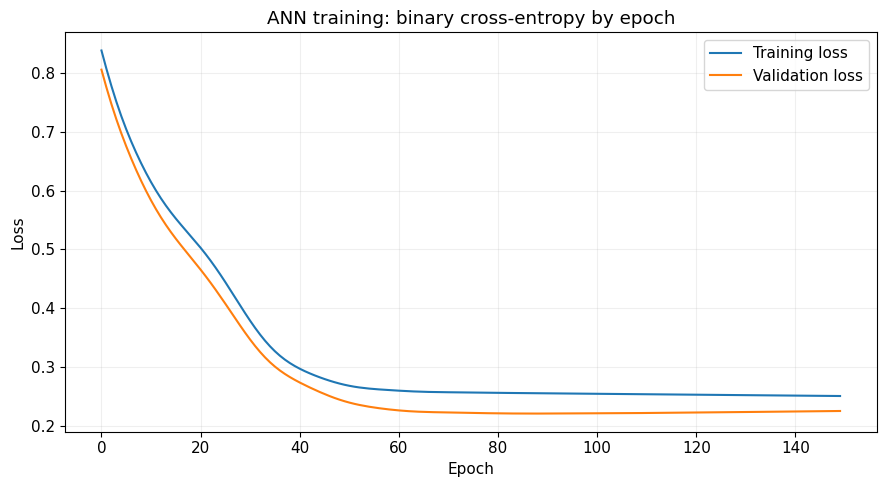

Illustrative test accuracy: 0.859
Model estimated win probability for [33,29]: 0.9884 (synthetic demonstration)


In [15]:
# Output is a raw logit; BCEWithLogitsLoss handles sigmoid internally for numerical stability.
torch.manual_seed(SEED)
swim_net = nn.Sequential(nn.Linear(2, 3), nn.Tanh(), nn.Linear(3, 1))
criterion_swim = nn.BCEWithLogitsLoss()
opt_swim = torch.optim.Adam(swim_net.parameters(), lr=.03)
train_losses, val_losses = [], []
for epoch in range(150):
    swim_net.train()
    opt_swim.zero_grad()
    logits = swim_net(X_trs)
    loss = criterion_swim(logits, y_trt)
    loss.backward()
    opt_swim.step()
    swim_net.eval()
    with torch.no_grad(): val_loss = criterion_swim(swim_net(X_vals), y_valt)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
with torch.no_grad():
    pred_test = (torch.sigmoid(swim_net(X_tes)) >= .5).int().numpy().ravel()
    x_star = torch.tensor(scaler_swim.transform([[33, 29]]), dtype=torch.float32)
    p_star = torch.sigmoid(swim_net(x_star)).item()
plt.plot(train_losses, label='Training loss'); plt.plot(val_losses, label='Validation loss')
plt.title('ANN training: binary cross-entropy by epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()
print('Illustrative test accuracy:', round(accuracy_score(y_te.astype(int), pred_test), 3))
print('Model estimated win probability for [33,29]:', round(p_star, 4), '(synthetic demonstration)')

### 8.1 Swimming example: identify input, prediction, target, and learning signal precisely

This classification problem uses two input features:

$$x^{(i)}=\begin{bmatrix}\text{swimming-practice hours}\\\text{dryland-workout hours}\end{bmatrix}.$$

One particular sample is $x^{(1)}=[33,29]^T$. The label is **not determined** by the inputs alone: it must come from the observed outcome of that competition. If winning is encoded by $y=1$ and losing by $y=0$, a network might produce $p=0.1$ **before training**. The number $0.1$ is a hypothetical *predicted probability of winning*, not the training target.

If this swimmer actually **won**, $y=1$. The individual BCE loss is

$$L=-\left[1\ln0.1+(1-1)\ln(1-0.1)\right]=-\ln0.1\approx\boxed{2.302585}.$$

That is a large penalty, because the network assigned low probability to the class that occurred. If the swimmer actually **lost**, $y=0$ with the *same prediction* $p=0.1$:

$$L=-\left[0\ln0.1+1\ln0.9\right]=-\ln0.9\approx\boxed{0.105361}.$$

Thus the input and network weights can stay exactly the same while the **loss changes with the target**. In training, that loss is differentiated and the weights move so future predictions better match the observed labels.

**Why standardize the hours?** Hours may range from 0 to 40 or more. Scaling inputs using statistics computed on the **training** set often helps optimization; do not fit scaling separately on test data or use test statistics in training. The existing notebook's swimming dataset is a *synthetic demonstration*, not an experimentally verified predictor of athletic success.

The full supervised workflow is: **collect labeled data → split train/validation/test → preprocess train-only → forward prediction → loss → backward gradients → optimizer step → evaluate on validation → finally evaluate the reserved test set**. Backpropagation is one step of this larger process, not a standalone method for labeling examples.

In [16]:
# Same prediction p=0.1, but different targets produce very different losses.
p_swim = .1
for actual_y in [1,0]:
    L = -(actual_y*np.log(p_swim)+(1-actual_y)*np.log(1-p_swim))
    print(f'Predicted win-probability={p_swim:.1f}, observed label={actual_y}: BCE={L:.6f}')
assert np.isclose(-np.log(.1),2.302585092994046)

Predicted win-probability=0.1, observed label=1: BCE=2.302585
Predicted win-probability=0.1, observed label=0: BCE=0.105361


## 9. Error, loss, empirical risk, MSE and cross-entropy

A **prediction** $\hat y_i=f_\theta(x_i)$ comes from the network. A **target** $y_i$ is the desired training signal. Their signed difference $e_i=\hat y_i-y_i$ is an error. A **loss** converts that error into a nonnegative penalty (for the examples below). An **empirical objective** averages losses across a dataset:
$$\boxed{J(\theta)=\frac{1}{n}\sum_{i=1}^{n}\mathcal L(f_\theta(x_i),y_i)}.$$
**Mean squared error (MSE)** is common for regression:
$$\operatorname{MSE}=\frac1n\sum_{i=1}^{n}(\hat y_i-y_i)^2.$$
**regression numbers**: predictions $[90,78,55]$ and targets $[95,80,72]$ give errors $[-5,-2,-17]$, squared errors $[25,4,289]$, sum $318$, and $\boxed{\operatorname{MSE}=318/3=106}$.

For **binary probabilities** $p_i\in(0,1)$ and labels $y_i\in\{0,1\}$:
$$\boxed{\operatorname{BCE}=-\frac1n\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right]}.$$
The **minus sign matters**. With $p=[0.2,0.9,0.5]$ and $y=[0,1,1]$, the sample penalties are $[-\ln0.8,-\ln0.9,-\ln0.5]\approx[0.2231,0.1054,0.6931]$, averaging to $\approx0.34055$. For one sample with $p=0.1$ and $y=1$, BCE $=-\ln(0.1)\approx2.302585$.

**Multiclass classification:** For logits $z_c$ over $C$ mutually exclusive classes, $p_c=e^{z_c}/\sum_j e^{z_j}$ (Softmax). With true class $k$, $\mathcal L=-\ln p_k$; `nn.CrossEntropyLoss` computes stable log-softmax and negative log-likelihood internally and expects *raw logits*, integer class labels. For a single binary logit, prefer `nn.BCEWithLogitsLoss`.

**Note on $1/2$ in squared loss:** $\mathcal L=\frac12(\hat y-y)^2$ has derivative $(\hat y-y)\partial\hat y/\partial\theta$; the factor $1/2$ cancels the $2$ from differentiation. Standard library MSE generally omits this $1/2$.

In [17]:
pred_reg = np.array([90., 78., 55.]); target_reg = np.array([95., 80., 72.])
residuals = pred_reg-target_reg
print('Regression residuals:', residuals, '| squares:', residuals**2, '| MSE:', np.mean(residuals**2))
p_bin = np.array([.2, .9, .5]); labels_bin = np.array([0., 1., 1.])
bce_each = -(labels_bin*np.log(p_bin) + (1-labels_bin)*np.log(1-p_bin))
print('BCE individual:', bce_each, '| mean:', bce_each.mean())
print('Single-sample BCE for p=0.1, y=1:', -np.log(.1))
print('Torch BCEWithLogits:', F.binary_cross_entropy_with_logits(torch.logit(torch.tensor(p_bin)), torch.tensor(labels_bin)).item())
assert np.isclose(np.mean(residuals**2), 106)
assert np.isclose(np.mean(bce_each), F.binary_cross_entropy_with_logits(torch.logit(torch.tensor(p_bin)), torch.tensor(labels_bin)).item())

Regression residuals: [ -5.  -2. -17.] | squares: [ 25.   4. 289.] | MSE: 106.0
BCE individual: [0.2231 0.1054 0.6931] | mean: 0.34055041584399376
Single-sample BCE for p=0.1, y=1: 2.3025850929940455
Torch BCEWithLogits: 0.34055041584399376


In [18]:
logits_mc = torch.tensor([[2., 1., 0.], [.5, 2., 1.]])
class_targets = torch.tensor([0, 1], dtype=torch.long)
probs_mc = torch.softmax(logits_mc, dim=1)
manual_ce = -torch.log(probs_mc[torch.arange(2), class_targets]).mean()
lib_ce = nn.CrossEntropyLoss()(logits_mc, class_targets)
print('Softmax probabilities:\n', probs_mc.numpy())
print('Manual multiclass CE:', manual_ce.item(), '| PyTorch CE:', lib_ce.item())
assert torch.allclose(manual_ce, lib_ce)

Softmax probabilities:
 [[0.6652 0.2447 0.09  ]
 [0.1402 0.6285 0.2312]]
Manual multiclass CE: 0.4359874129295349 | PyTorch CE: 0.43598735332489014


### 9.1 What is the difference between prediction, error, loss, gradient, and update?

For one training example there are **five distinct objects**:

| Object | Definition | What it answers |
|---|---|---|
| Prediction $\hat y=f_\theta(x)$ | Forward pass using **current parameters** | What does the model currently say? |
| Target $y$ | Observed label / desired training value | What should it predict for this sample? |
| Signed error $e=\hat y-y$ | Prediction minus target | How far off is the number, and in which direction? |
| Loss $L(\hat y,y)$ | Differentiable penalty, e.g. $\frac12e^2$ | How costly is the current error? |
| Gradient $\partial L/\partial\theta$ | Sensitivity of loss to parameters | Which direction and how strongly should each parameter change? |

**The loss function by itself does not update a weight.** First the **chain rule/backpropagation** computes derivatives of the loss with respect to each weight and bias; next the **optimizer** uses these derivatives to change the parameters. The overall mechanism is

$$\boxed{\hat y=f_\theta(x)\ \to\ L(\hat y,y)\ \to\ \nabla_\theta L\ \to\ \theta_{\rm new}=\theta-\eta\nabla_\theta L}.$$

Why differentiate rather than only check whether a loss is 'large'? Two neurons can produce the **same scalar loss**, but changing their individual weights can affect the output in completely different directions. The derivative separates those effects for each weight. An optimizer's job is not to subtract the loss value itself: it uses the **loss gradients**.

**Mean over a dataset:** for $N$ samples, $J(\theta)=\frac1N\sum_iL_i(\theta)$, and differentiation distributes over the sum:

$$\nabla_\theta J(\theta)=\frac1N\sum_{i=1}^N\nabla_\theta L_i(\theta).$$

That is why full-batch gradient descent averages per-example gradients; SGD and mini-batch SGD use estimates from subsets.

### 9.2 One linear neuron: calculate the loss, two weight gradients, bias gradient, and updated prediction BY HAND

For the clearest possible training calculation, use **one neuron with identity activation**, two inputs, and one regression target:

$$x=\begin{bmatrix}2\\1\end{bmatrix},\quad w=\begin{bmatrix}0.5\\-1\end{bmatrix},\quad b=0.2,\quad y=1,\quad \eta=0.1.$$

**Step 1 — current forward prediction:**

$$\hat y=w_1x_1+w_2x_2+b=0.5(2)+(-1)(1)+0.2=\boxed{0.2}.$$

**Step 2 — signed error and half-squared loss:**

$$e=\hat y-y=0.2-1=-0.8,\quad
L=\tfrac12e^2=\tfrac12(-0.8)^2=\boxed{0.32}.$$

The $\frac12$ is convenient in a manual derivative; standard `MSELoss` instead uses the square without this factor.

**Step 3 — differentiate the loss with respect to output:**

$$\frac{\partial L}{\partial\hat y}
=\frac{\partial}{\partial\hat y}\left[\tfrac12(\hat y-y)^2\right]
={\tfrac12\cdot2}(\hat y-y)=\boxed{-0.8}.$$

**Step 4 — differentiate the output with respect to each parameter:**

$$\frac{\partial\hat y}{\partial w_1}=x_1=2,\quad
\frac{\partial\hat y}{\partial w_2}=x_2=1,\quad
\frac{\partial\hat y}{\partial b}=1.$$

**Step 5 — chain rule / gradient calculation:**

$$\frac{\partial L}{\partial w_1}=(-0.8)(2)=\boxed{-1.6},$$
$$\frac{\partial L}{\partial w_2}=(-0.8)(1)=\boxed{-0.8},$$
$$\frac{\partial L}{\partial b}=(-0.8)(1)=\boxed{-0.8}.$$

The two weight gradients differ because the input multipliers 2 and 1 are different. This is precisely why we do not subtract the same loss from every weight.

**Step 6 — gradient-descent updates:** $\theta_{\rm new}=\theta_{\rm old}-\eta\,\partial L/\partial\theta$:

$$w_{1,\rm new}=0.5-0.1(-1.6)=\boxed{0.66},$$
$$w_{2,\rm new}=-1-0.1(-0.8)=\boxed{-0.92},$$
$$b_{\rm new}=0.2-0.1(-0.8)=\boxed{0.28}.$$

**Step 7 — forward pass AGAIN using the updated parameters:**

$$\hat y_{\rm new}=0.66(2)-0.92(1)+0.28=\boxed{0.68},$$
$$L_{\rm new}=\tfrac12(0.68-1)^2=\boxed{0.0512}.$$

The loss dropped from **0.32 to 0.0512 after one step**. This outcome depends on the learning rate and shape of the loss: in general a large optimizer step can increase the loss. One update is **not** necessarily enough to train a network.

**Key distinction:** Forward propagation calculated $0.2$. The target $1$ produced a loss $0.32$. Backpropagation produced gradients $(-1.6,-0.8,-0.8)$. **Gradient descent used those gradients to change the parameters**, leading to a new prediction $0.68$.

In [19]:
# Verify all 7 steps twice: manually with NumPy and automatically with PyTorch.
x_linear = np.array([2.,1.]);w_linear = np.array([.5,-1.]);b_linear = .2;y_linear=1.;eta_linear=.1
pred_linear = x_linear @ w_linear+b_linear
loss_linear = .5*(pred_linear-y_linear)**2
grad_linear = (pred_linear-y_linear)*x_linear
grad_b_linear = pred_linear-y_linear
w_linear_new = w_linear-eta_linear*grad_linear
b_linear_new = b_linear-eta_linear*grad_b_linear
pred_linear_new = x_linear @ w_linear_new+b_linear_new
loss_linear_new = .5*(pred_linear_new-y_linear)**2
display(pd.DataFrame({'quantity':['w1','w2','bias','prediction','half-MSE'],
                      'before':[.5,-1.,.2,pred_linear,loss_linear],
                      'gradient':[*grad_linear,grad_b_linear,np.nan,np.nan],
                      'after':[w_linear_new[0],w_linear_new[1],b_linear_new,pred_linear_new,loss_linear_new]}))
w_t = torch.tensor([.5,-1.],requires_grad=True);b_t = torch.tensor(.2,requires_grad=True)
yhat_t = (w_t*torch.tensor([2.,1.])).sum()+b_t
loss_t = .5*(yhat_t-1.).square();loss_t.backward()
print('Autograd weights:',w_t.grad.tolist(),'bias:',b_t.grad.item())
assert np.allclose(w_t.grad.numpy(),grad_linear)
assert np.isclose(b_t.grad.item(),grad_b_linear)
assert np.isclose(pred_linear_new,.68)
assert np.isclose(loss_linear_new,.0512)

,quantity,before,gradient,after
0,w1,0.50,-1.6,0.6600
1,w2,-1.00,-0.8,-0.9200
2,bias,0.20,-0.8,0.2800
3,prediction,0.20,NaN,0.6800
4,half-MSE,0.32,NaN,0.0512


Autograd weights: [-1.600000023841858, -0.800000011920929] bias: -0.800000011920929


### 9.2.1 Mean Loss and Average Gradients Over a Dataset: Manual Calculation

In Section 9.2, we calculated the loss and updated the weights using **one training sample**. However, neural networks are generally trained using multiple observations.

For a dataset containing $N$ samples, the mean loss is:

$$\boxed{J(\boldsymbol\theta)=\frac{1}{N}\sum_{i=1}^{N}L_i(\boldsymbol\theta)}$$

Because differentiation distributes over the sum:

$$\boxed{\nabla_{\boldsymbol\theta}J(\boldsymbol\theta)=\frac{1}{N}\sum_{i=1}^{N}\nabla_{\boldsymbol\theta}L_i(\boldsymbol\theta)}$$

This means that the **gradient of the average loss equals the average of the individual sample gradients**, evaluated at the same parameter values.

#### Step 1: Define the Neuron and Dataset

Consider the same linear neuron from Section 9.2:

$$\hat y=w_1x_1+w_2x_2+b$$

The initial parameters are:

$$w_1=0.5,\qquad w_2=-1,\qquad b=0.2$$

The learning rate is:

$$\eta=0.1$$

Now consider two training samples:

| Sample | $x_1$ | $x_2$ | Target $y$ |
|---|---|---|---|
| 1 | 2 | 1 | 1 |
| 2 | 1 | 2 | -0.5 |

We use the half-squared-error loss:

$$L_i=\frac12(\hat y_i-y_i)^2$$

#### Step 2: Calculate the Prediction and Loss for Each Sample

**Sample 1:**

$$\hat y_1=0.5(2)+(-1)(1)+0.2=0.2$$

The error is:

$$e_1=0.2-1=-0.8$$

The loss is:

$$L_1=\frac12(-0.8)^2=\boxed{0.32}$$

**Sample 2:**

$$\hat y_2=0.5(1)+(-1)(2)+0.2=-1.3$$

The error is:

$$e_2=-1.3-(-0.5)=-0.8$$

The loss is:

$$L_2=\frac12(-0.8)^2=\boxed{0.32}$$

#### Step 3: Calculate the Mean Loss

Since we have $N=2$ samples:

$$J(\boldsymbol\theta)=\frac12(L_1+L_2)$$

Substituting:

$$J(\boldsymbol\theta)=\frac12(0.32+0.32)$$

$$\boxed{J(\boldsymbol\theta)=0.32}$$

This is the average prediction loss over both training samples.

**Important:** We have not updated any parameters yet. Both samples were evaluated using the same initial weights and bias.

#### Step 4: Calculate the Individual Gradients

For the half-squared-error loss:

$$L_i=\frac12(\hat y_i-y_i)^2$$

The gradients for a linear neuron are:

$$\frac{\partial L_i}{\partial w_1}=(\hat y_i-y_i)x_{i1}$$

$$\frac{\partial L_i}{\partial w_2}=(\hat y_i-y_i)x_{i2}$$

$$\frac{\partial L_i}{\partial b}=\hat y_i-y_i$$

**For Sample 1:**

The error is $e_1=-0.8$, with inputs $x_1=2$ and $x_2=1$.

$$\frac{\partial L_1}{\partial w_1}=(-0.8)(2)=\boxed{-1.6}$$

$$\frac{\partial L_1}{\partial w_2}=(-0.8)(1)=\boxed{-0.8}$$

$$\frac{\partial L_1}{\partial b}=\boxed{-0.8}$$

**For Sample 2:**

The error is $e_2=-0.8$, with inputs $x_1=1$ and $x_2=2$.

$$\frac{\partial L_2}{\partial w_1}=(-0.8)(1)=\boxed{-0.8}$$

$$\frac{\partial L_2}{\partial w_2}=(-0.8)(2)=\boxed{-1.6}$$

$$\frac{\partial L_2}{\partial b}=\boxed{-0.8}$$

The resulting gradients are:

| Parameter | Sample 1 gradient | Sample 2 gradient |
|---|---|---|
| $w_1$ | -1.6 | -0.8 |
| $w_2$ | -0.8 | -1.6 |
| $b$ | -0.8 | -0.8 |

Although both samples have the same loss, their weight gradients differ because their input values are different.

#### Step 5: Calculate the Average Gradients

The mean gradient for each parameter is obtained by averaging the corresponding gradients across both samples.

For $w_1$:

$$\frac{\partial J}{\partial w_1}=\frac12\left(\frac{\partial L_1}{\partial w_1}+\frac{\partial L_2}{\partial w_1}\right)$$

$$=\frac12(-1.6-0.8)$$

$$\boxed{\frac{\partial J}{\partial w_1}=-1.2}$$

For $w_2$:

$$\frac{\partial J}{\partial w_2}=\frac12(-0.8-1.6)$$

$$\boxed{\frac{\partial J}{\partial w_2}=-1.2}$$

For the bias:

$$\frac{\partial J}{\partial b}=\frac12(-0.8-0.8)$$

$$\boxed{\frac{\partial J}{\partial b}=-0.8}$$

Therefore, the complete average gradient is:

$$\boxed{\nabla_{\boldsymbol\theta}J=\begin{bmatrix}-1.2\\-1.2\\-0.8\end{bmatrix}}$$

The gradient vector corresponds to the parameters:

$$\boldsymbol\theta=\begin{bmatrix}w_1\\w_2\\b\end{bmatrix}$$

#### Step 6: Update the Parameters Using Batch Gradient Descent

Recall the gradient descent equation:

$$\boxed{\boldsymbol\theta_{\text{new}}=\boldsymbol\theta_{\text{old}}-\eta\nabla_{\boldsymbol\theta}J}$$

Using $\eta=0.1$:

**Update $w_1$:**

$$w_{1,\text{new}}=0.5-0.1(-1.2)=\boxed{0.62}$$

**Update $w_2$:**

$$w_{2,\text{new}}=-1-0.1(-1.2)=\boxed{-0.88}$$

**Update the bias:**

$$b_{\text{new}}=0.2-0.1(-0.8)=\boxed{0.28}$$

Therefore, the updated parameters are:

$$\boxed{w_1=0.62,\qquad w_2=-0.88,\qquad b=0.28}$$

Notice that we updated the parameters **once using the average gradients from both samples**, rather than updating them separately after each sample.

#### Step 7: Calculate the New Predictions and Mean Loss

Use the updated parameters to calculate new predictions for both samples.

**Sample 1:**

$$\hat y_{1,\text{new}}=0.62(2)-0.88(1)+0.28$$

$$\boxed{\hat y_{1,\text{new}}=0.64}$$

New loss:

$$L_{1,\text{new}}=\frac12(0.64-1)^2=\boxed{0.0648}$$

**Sample 2:**

$$\hat y_{2,\text{new}}=0.62(1)-0.88(2)+0.28$$

$$\boxed{\hat y_{2,\text{new}}=-0.86}$$

New loss:

$$L_{2,\text{new}}=\frac12(-0.86+0.5)^2=\boxed{0.0648}$$

The new mean loss is:

$$J_{\text{new}}=\frac12(0.0648+0.0648)$$

$$\boxed{J_{\text{new}}=0.0648}$$

**Compare the results:**

| Quantity | Before update | After update |
|---|---|---|
| $w_1$ | 0.50 | 0.62 |
| $w_2$ | -1.00 | -0.88 |
| Bias | 0.20 | 0.28 |
| Sample 1 prediction | 0.20 | 0.64 |
| Sample 2 prediction | -1.30 | -0.86 |
| Mean loss | 0.3200 | 0.0648 |

The mean loss decreased from $0.32$ to $0.0648$ after one batch gradient descent update.

#### Step 8: How Is This Different From SGD and Mini-Batch Gradient Descent?

In this example, **Batch Gradient Descent** calculates both sample gradients, averages them, and performs one update.

If we instead used **Stochastic Gradient Descent (SGD)** and selected only Sample 1 for the first update, we would use its individual gradients:

$$\nabla_{\boldsymbol\theta}L_1=\begin{bmatrix}-1.6\\-0.8\\-0.8\end{bmatrix}$$

The resulting parameters would be:

$$w_1=0.66,\qquad w_2=-0.92,\qquad b=0.28$$

These are the same updated parameters obtained in Section 9.2, because that section used only Sample 1.

For **Mini-Batch Gradient Descent**, we select a subset of samples, calculate their average gradient, and perform one update. For a larger dataset, different mini-batches may produce different gradient estimates.

With only two training samples, a batch size of two is equivalent to full-batch gradient descent, while a batch size of one is ordinary SGD.

**Key Takeaway**

The loss for each sample measures its prediction error. Backpropagation calculates the gradient associated with that sample.

When optimizing the mean loss over a dataset, we calculate the average of the sample gradients:

$$\boxed{\nabla_{\boldsymbol\theta}J=\frac1N\sum_{i=1}^{N}\nabla_{\boldsymbol\theta}L_i}$$

The optimizer uses this gradient to update the parameters. In this example, averaging the gradients from both samples reduced the mean loss from $0.32$ to $0.0648$ after one update.

### 9.3 Sigmoid + binary cross-entropy: why the gradient can be simpler

A binary-classification neuron often computes **logit** $z=w^Tx+b$ and **probability** $p=\sigma(z)$. For a target $y\in\{0,1\}$:

$$L(p,y)=-\left[y\ln p+(1-y)\ln(1-p)\right].$$

We want $\partial L/\partial w_i$, so differentiate in the same order as the network's operations.

**Part A — derivative of BCE with respect to probability:**

$$\frac{\partial L}{\partial p}=-\frac{y}{p}+\frac{1-y}{1-p}
=\frac{p-y}{p(1-p)}.$$

**Part B — derivative of probability with respect to logit:**

$$\frac{\partial p}{\partial z}=p(1-p).$$

**Part C — combine via chain rule:**

$$\boxed{\frac{\partial L}{\partial z}=\frac{\partial L}{\partial p}\frac{\partial p}{\partial z}
=\frac{p-y}{p(1-p)}\,p(1-p)=p-y.}$$

Finally $\partial z/\partial w_i=x_i$ and $\partial z/\partial b=1$, giving

$$\boxed{\nabla_w L=(p-y)x,\qquad\frac{\partial L}{\partial b}=p-y.}$$

This cancellation is a main reason why sigmoid-with-BCE is a sensible binary-classification pairing. When computing numerical BCE, use **logits** with `torch.nn.BCEWithLogitsLoss()`; it handles the combination stably without manually calling sigmoid inside the loss.

**One numerical update using the same input and initial weights as Section 9.2:** $x=[2,1]^T$, $w=[0.5,-1]^T$, $b=0.2$, $y=1$, $\eta=0.1$. We still have $z=0.2$, but now

$$p=\sigma(0.2)\approx0.549834,\qquad L=-\ln(0.549834)\approx0.598139.$$

The common logit error is $\delta=p-y\approx-0.450166$, so

$$\frac{\partial L}{\partial w_1}=2\delta\approx-0.900332,\quad
\frac{\partial L}{\partial w_2}=\delta\approx-0.450166,\quad
\frac{\partial L}{\partial b}=\delta\approx-0.450166.$$

Updated values are

$$w_1'=0.5-0.1(-0.900332)\approx0.590033,$$
$$w_2'=-1-0.1(-0.450166)\approx-0.954983,$$
$$b'=0.2-0.1(-0.450166)\approx0.245017.$$

The new logit is $z'=2w_1'+w_2'+b'\approx0.470100$, and the new probability is $\sigma(z')\approx0.6154$. The probability of the observed label increased. The code reports exact values and checks every derivative.

In [20]:
# Fully manual BCE step, checked against BCEWithLogitsLoss autograd.
x_bce = np.array([2.,1.]);w_bce=np.array([.5,-1.]);b_bce=.2; y_bce=1.;lr_bce=.1
z_bce=x_bce@w_bce+b_bce;p_bce=float(sigmoid_np(z_bce))
loss_bce=-np.log(p_bce);delta_bce=p_bce-y_bce
gw_bce=delta_bce*x_bce;gb_bce=delta_bce
w_bce_next=w_bce-lr_bce*gw_bce;b_bce_next=b_bce-lr_bce*gb_bce
z_bce_next=x_bce@w_bce_next+b_bce_next;p_bce_next=float(sigmoid_np(z_bce_next))
loss_bce_next=-np.log(p_bce_next)
w_t_bce=torch.tensor([.5,-1.],requires_grad=True);b_t_bce=torch.tensor(.2,requires_grad=True)
logit_t=(w_t_bce*torch.tensor([2.,1.])).sum()+b_t_bce
loss_t_bce=F.binary_cross_entropy_with_logits(logit_t,torch.tensor(1.));loss_t_bce.backward()
for name,val in [('Old logit',z_bce),('Old probability',p_bce),('Old BCE',loss_bce),('delta=dL/dz',delta_bce),('dw1',gw_bce[0]),('dw2',gw_bce[1]),('db',gb_bce),('New logit',z_bce_next),('New probability',p_bce_next),('New BCE',loss_bce_next)]: print(f'{name:19s}: {val:.8f}')
assert np.allclose(gw_bce,w_t_bce.grad.detach().numpy(),atol=1e-7)
assert np.isclose(gb_bce,b_t_bce.grad.item(),atol=1e-7)
assert loss_bce_next<loss_bce

Old logit          : 0.20000000
Old probability    : 0.54983400
Old BCE            : 0.59813887
delta=dL/dz        : -0.45016600
dw1                : -0.90033201
dw2                : -0.45016600
db                 : -0.45016600
New logit          : 0.47009960
New probability    : 0.61540733
New BCE            : 0.48547090


## 10. Optimization objectives and basic gradient descent

Learning searches for weights and biases $\theta$ that reduce an objective $J$:

$$\boxed{\theta^*=\operatorname*{arg\,min}_{\theta}J(\theta)}.$$

The **gradient** $\nabla_\theta J$ lists the partial derivatives with respect to each parameter. Locally, $-\nabla J$ points toward decreasing objective values for a sufficiently small step, giving the basic update rule

$$\boxed{\theta_{t+1}=\theta_t-\eta\nabla_\theta J(\theta_t)},$$

where $\eta>0$ is the **learning rate**.

### Step-by-step idea of gradient descent

Every gradient-descent-style method repeats the same four conceptual steps:

1. **Start from current parameters** $\theta_t$.  
2. **Compute the current loss** $J(\theta_t)$.  
3. **Compute the gradient** $g_t=\nabla_\theta J(\theta_t)$.  
4. **Move opposite the gradient** using $\theta_{t+1}=\theta_t-\eta g_t$.

If the step is small enough, the new parameters usually move downhill on the loss surface. Large steps may overshoot; tiny steps can take many updates.

### By-hand scalar example

Let

$$J(w)=(w-3)^2+1,$$

so

$$J'(w)=2(w-3).$$

Start from $w_0=0$ with learning rate $\eta=0.2$.

- **Iteration 0:**  
  $$g_0=2(0-3)=-6,\qquad w_1=0-0.2(-6)=1.2.$$
- **Iteration 1:**  
  $$g_1=2(1.2-3)=-3.6,\qquad w_2=1.2-0.2(-3.6)=1.92.$$

The corresponding losses are

$$J(w_0)=10,\qquad J(w_1)=4.24,\qquad J(w_2)=2.1664.$$

The minimum occurs at $w^*=3$, where $J(w^*)=1$.

iteration 0: w=0.000000, grad=-6.000000, loss=10.000000
iteration 1: w=1.200000, grad=-3.600000, loss=4.240000
iteration 2: w=1.920000, grad=-2.160000, loss=2.166400
iteration 3: w=2.352000, grad=-1.296000, loss=1.419904


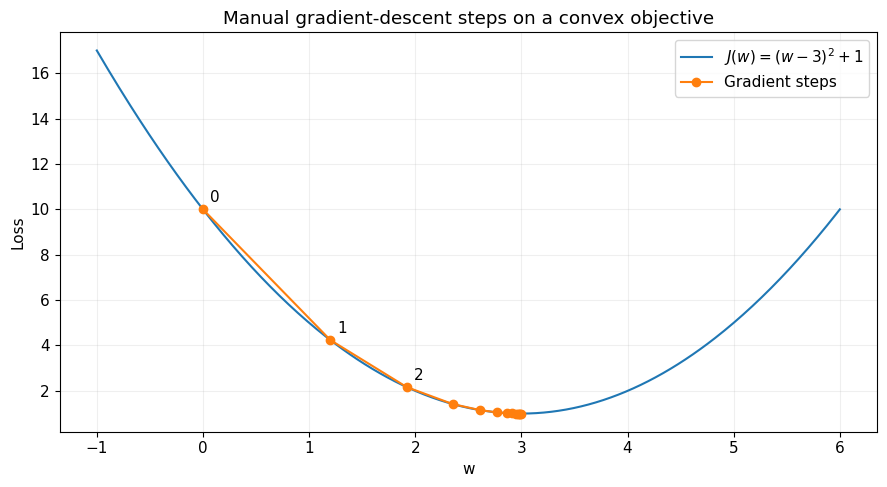

In [21]:
def scalar_loss(w): return (w-3)**2 + 1
def scalar_grad(w): return 2*(w-3)
w, eta = 0., .2
for t in range(4):
    print(f'iteration {t}: w={w:.6f}, grad={scalar_grad(w):.6f}, loss={scalar_loss(w):.6f}')
    w = w-eta*scalar_grad(w)
assert np.isclose(scalar_loss(1.92), 2.1664)

trajectory = [0.]
for _ in range(12): trajectory.append(trajectory[-1] - eta*scalar_grad(trajectory[-1]))
xx = np.linspace(-1, 6, 400)
plt.plot(xx, scalar_loss(xx), label='$J(w)=(w-3)^2+1$')
plt.plot(trajectory, scalar_loss(np.array(trajectory)), 'o-', label='Gradient steps')
for i in range(3): plt.annotate(str(i), (trajectory[i], scalar_loss(trajectory[i])), xytext=(5, 5), textcoords='offset points')
plt.xlabel('w'); plt.ylabel('Loss'); plt.title('Manual gradient-descent steps on a convex objective'); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

,Step,W0 before,W1 before,Loss before,dLoss/dW0,dLoss/dW1,W0 after,W1 after,Loss after
0,0,4.50000,2.00000,0.84090,0.25386,0.62443,4.36038,1.65656,0.59069
1,1,4.36038,1.65656,0.59069,0.21639,0.62701,4.24136,1.31171,0.36136
2,2,4.24136,1.31171,0.36136,0.13635,0.56938,4.16637,0.99855,0.18921
3,3,4.16637,0.99855,0.18921,0.04938,0.47914,4.13921,0.73502,0.07432
4,4,4.13921,0.73502,0.07432,-0.01279,0.38582,4.14625,0.52282,0.00092
5,5,4.14625,0.52282,0.00092,-0.04359,0.30208,4.17022,0.35668,-0.04461
6,6,4.17022,0.35668,-0.04461,-0.05155,0.23095,4.19857,0.22966,-0.07172
7,7,4.19857,0.22966,-0.07172,-0.04739,0.17290,4.22463,0.13456,-0.08714
8,8,4.22463,0.13456,-0.08714,-0.03873,0.12733,4.24593,0.06453,-0.09558
9,9,4.24593,0.06453,-0.09558,-0.02964,0.09267,4.26223,0.01356,-0.10006


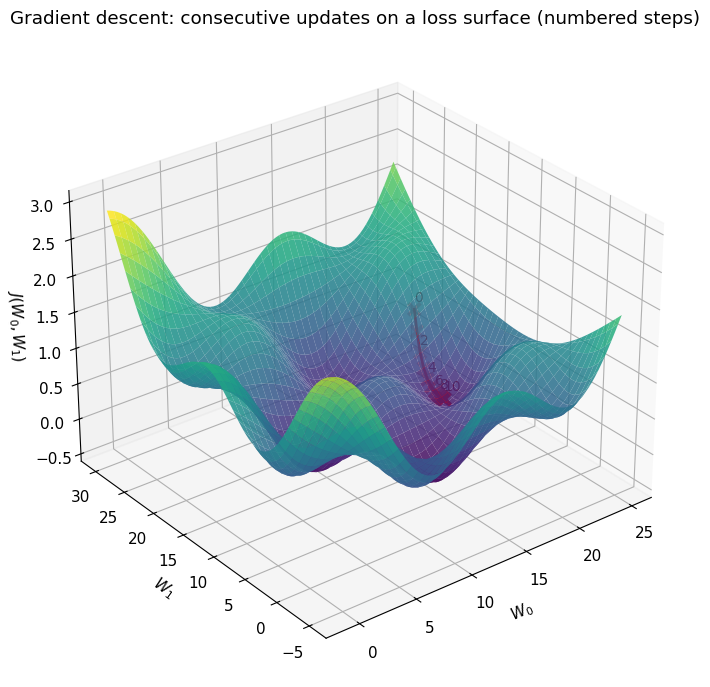

In [22]:
# Gradient-descent path on a two-parameter NONCONVEX loss surface.
# The red X marks and connecting arrows are genuine consecutive gradient steps.
def toy_surface(w0, w1):
    return 0.03*((w0-1)**2 + (w1+1)**2) + 0.5*np.sin(w0)*np.cos(w1)

def toy_grad(w0, w1):
    d0 = 0.06*(w0-1) + 0.5*np.cos(w0)*np.cos(w1)
    d1 = 0.06*(w1+1) - 0.5*np.sin(w0)*np.sin(w1)
    return np.array([d0, d1])

point = np.array([4.5, 2.0]); eta_surface = 0.55; path = [point.copy()]; gd_rows = []
for t in range(12):
    gradient = toy_grad(*point)
    next_point = point - eta_surface*gradient
    gd_rows.append([t, *point, toy_surface(*point), *gradient, *next_point, toy_surface(*next_point)])
    point = next_point
    path.append(point.copy())

path = np.asarray(path)
display(pd.DataFrame(gd_rows, columns=['Step','W0 before','W1 before','Loss before','dLoss/dW0','dLoss/dW1','W0 after','W1 after','Loss after']).round(5))

# Axis transformation changes ONLY figure coordinates, not the function or update rule.
W0, W1 = np.meshgrid(np.linspace(-1, 25, 90), np.linspace(-5, 30, 90))
Z = toy_surface(W0/2.2-5, W1/2.8-5)
plot_w0, plot_w1 = (path[:,0]+5)*2.2, (path[:,1]+5)*2.8
plot_z = toy_surface(path[:,0], path[:,1])
fig = plt.figure(figsize=(10, 7)); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Z, cmap='viridis', alpha=.86, edgecolor='none')
ax.plot(plot_w0, plot_w1, plot_z+0.06, color='red', lw=2)
ax.scatter(plot_w0, plot_w1, plot_z+0.06, color='red', marker='x', s=75, linewidth=2.8)
for t in range(0, len(path)-1, 2):
    ax.text(plot_w0[t], plot_w1[t], plot_z[t]+0.16, str(t), color='darkred', fontsize=10)
ax.set_xlabel('$W_0$'); ax.set_ylabel('$W_1$'); ax.set_zlabel('$J(W_0,W_1)$')
ax.set_title('Gradient descent: consecutive updates on a loss surface (numbered steps)')
ax.view_init(elev=29, azim=-128); plt.tight_layout(); plt.show()
assert all(row[-1] < row[3] for row in gd_rows), 'This illustrative path should reduce the loss at every step.'

### 10.1 Why subtract the gradient, and how does the learning rate affect the result?

The first-order Taylor approximation around a weight $w$ is

$$J(w+\Delta w)\approx J(w)+J'(w)\Delta w.$$

If we choose

$$\Delta w=-\eta J'(w),\qquad \eta>0,$$

then the approximate change becomes

$$J(w+\Delta w)-J(w)\approx-\eta [J'(w)]^2\leq 0.$$

So the **negative gradient** is the local direction of decrease. This is why gradient descent **subtracts** the gradient instead of adding it.

The relation above is only a **local** guarantee. If the learning rate is too large, higher-order terms can dominate and the true objective can go up.

For the quadratic $J(w)=(w-3)^2$, the iteration becomes

$$w_{t+1}=w_t-2\eta(w_t-3)=3+(1-2\eta)(w_t-3).$$

Therefore,

$$w_t-3=(1-2\eta)^t(w_0-3).$$

For this specific quadratic:

- $0<\eta<1$ gives convergence,
- a very small learning rate gives slow progress,
- $\eta=0.5$ reaches the minimum in one step for this special example,
- $0.5<\eta<1$ often oscillates across the minimum while shrinking,
- $\eta>1$ diverges.

This exact threshold depends on the loss shape. Neural-network losses are much more complicated, so the safe learning-rate range is not usually known in advance.

## 11. Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent

Gradient descent updates parameters to reduce the loss, but there are different ways to estimate the gradient when the dataset contains many training examples.

Suppose the dataset has $n$ samples and each sample contributes a loss $\ell_i(\theta)$. The empirical objective is

$$J(\theta)=\frac1n\sum_{i=1}^{n}\ell_i(\theta).$$

### 11.1 Full-batch gradient descent

Full-batch gradient descent uses **all training samples** to compute one gradient:

$$\boxed{g_{\rm batch}=\nabla J(\theta)=\frac1n\sum_{i=1}^{n}\nabla\ell_i(\theta).}$$

Then the update is

$$\theta\leftarrow\theta-\eta g_{\rm batch}.$$

This gives a stable estimate of the descent direction, but can be expensive when the dataset is large.

### 11.2 Stochastic gradient descent (strict sense)

In the strict sense, **SGD** picks **one training sample** at a time and updates immediately using only that sample's gradient:

$$\boxed{g_{\rm SGD}=\nabla\ell_i(\theta)}$$

for one selected example $i$.

So yes: **in SGD, every parameter update is based on one sample rather than the whole batch**. The selected sample is typically chosen by shuffling the dataset and then processing one example at a time.

### 11.3 Mini-batch SGD

Mini-batch SGD uses a subset $B$ of the data:

$$\boxed{g_B=\frac1{|B|}\sum_{i\in B}\nabla\ell_i(\theta).}$$

The update is again

$$\theta\leftarrow\theta-\eta g_B.$$

Mini-batch training is the standard practical choice because it balances noisy-but-cheap updates with efficient matrix computation.

### 11.4 Epoch, batch, and iteration

- **Batch**: the set of samples used in one gradient computation.  
- **Iteration / update step**: one call to the optimizer update rule.  
- **Epoch**: one full pass through the entire training set.

If the dataset has 100 samples and batch size 20, then one epoch usually contains **5 iterations**.

### 11.5 One common worked example

Use the tiny dataset

$$(x,y)\in\{(1,2),(2,4),(3,6)\},$$

model $\hat y=wx$, loss $\ell_i=(wx_i-y_i)^2$, initial $w_0=0$, and learning rate $\eta=0.1$.

The per-sample gradients are

$$g_i=2(wx_i-y_i)x_i,$$

so at $w_0=0$ they are

$$[-4,-16,-36].$$

Therefore:

- **Full batch:**  
  $$g=(-4-16-36)/3=-56/3,\qquad w_1=0-0.1(-56/3)=1.866667.$$
- **One-sample SGD using sample 1 only:**  
  $$g=-4,\qquad w_1=0-0.1(-4)=0.4.$$
- **Mini-batch using samples 1 and 2:**  
  $$g=(-4-16)/2=-10,\qquad w_1=0-0.1(-10)=1.0.$$

These three methods start from the same point but move differently because they use different gradient estimates.

In [23]:
X_small = np.array([1., 2., 3.]); Y_small = np.array([2., 4., 6.]); w_init = 0.; lr_small = .1
grads0 = 2*(w_init*X_small-Y_small)*X_small
results = {'Full batch (3 samples)': w_init-lr_small*grads0.mean(), 'SGD (1 sample)': w_init-lr_small*grads0[0], 'Mini-batch (2 samples)': w_init-lr_small*grads0[:2].mean()}
print('Individual derivatives:', grads0)
display(pd.DataFrame({'Method': list(results.keys()), 'Updated weight': list(results.values())}))
assert np.isclose(results['Full batch (3 samples)'], 56/30)
assert np.isclose(results['SGD (1 sample)'], .4)
assert np.isclose(results['Mini-batch (2 samples)'], 1.)

Individual derivatives: [ -4. -16. -36.]


,Method,Updated weight
0,Full batch (3 samples),1.86667
1,SGD (1 sample),0.40000
2,Mini-batch (2 samples),1.00000


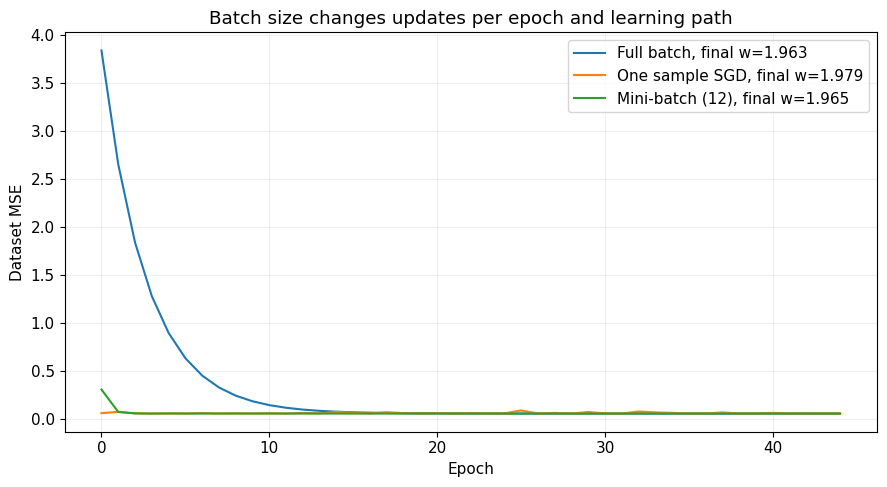

In [24]:
# Compare convergence using the same model and noisy dataset, recording objective after each epoch.
rng = np.random.default_rng(SEED)
xs = rng.uniform(.2, 2.0, 90)
ys = 2*xs+rng.normal(0, .25, 90)
def fit_linear_sgd(batch_size, eta=.06, epochs=45):
    w = 0.
    history = []
    for epoch in range(epochs):
        ids = rng.permutation(len(xs))
        for start in range(0, len(xs), batch_size):
            batch = ids[start:start+batch_size]
            grad = np.mean(2*(w*xs[batch]-ys[batch])*xs[batch])
            w -= eta*grad
        history.append(np.mean((w*xs-ys)**2))
    return w, history
plt.figure(figsize=(9, 5))
for n_batch, name in [(90, 'Full batch'), (1, 'One sample SGD'), (12, 'Mini-batch (12)')]:
    w_final, history = fit_linear_sgd(n_batch)
    plt.plot(history, label=f'{name}, final w={w_final:.3f}')
plt.title('Batch size changes updates per epoch and learning path'); plt.xlabel('Epoch'); plt.ylabel('Dataset MSE'); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

### 11.1 Batch versus stochastic versus mini-batch: work through consecutive SGD steps

These three optimization methods share the general update form $w\leftarrow w-\eta g$, but differ in **which data determine the gradient**. Let $\hat y_i=wx_i$ and $\ell_i(w)=(wx_i-y_i)^2$ with $(x,y)=(1,2),(2,4),(3,6)$. Then

$$\frac{\partial\ell_i}{\partial w}=2(wx_i-y_i)x_i.$$

Start with $w_0=0$, $\eta=0.05$. One **full-batch** update uses all three sample gradients at $w_0$: $(-4-16-36)/3=-56/3$, yielding $w'=0.933333$. For **SGD**, process samples one by one; importantly, **recompute the gradient after each weight update**:

| Update | Selected sample $(x_i,y_i)$ | Weight before | New gradient $2(wx_i-y_i)x_i$ | Weight after |
|---|---|---:|---:|---:|
| 1 | $(1,2)$ | $0$ | $2(0-2)(1)=-4$ | $0-0.05(-4)=0.2$ |
| 2 | $(2,4)$ | $0.2$ | $2(0.4-4)(2)=-14.4$ | $0.2-0.05(-14.4)=0.92$ |
| 3 | $(3,6)$ | $0.92$ | $2(2.76-6)(3)=-19.44$ | $0.92-0.05(-19.44)=1.892$ |

For a **mini-batch with the first two examples**, at starting $w_0=0$ the average gradient is $(-4-16)/2=-10$ and one update gives $w'=0.5$. To train on all three samples in an epoch, a common implementation then processes the remaining sample as another batch and recomputes its derivative with the *new* parameter.

**Cost and noise:** Full batch has an expensive but relatively stable gradient estimate per step. One-sample SGD has cheaper but noisy updates. Mini-batches balance parallel computation with variance. None is universally best, and convergence depends on the learning rate, sampling, conditioning, and model.

**PyTorch naming nuance:** `torch.optim.SGD` is an optimizer and can operate on gradients from **any batch size**, including a full dataset. Calling `optimizer.step()` does not by itself determine whether training is stochastic or full-batch; the **data in the preceding loss.backward()** determine that.

In [25]:
# Audit EACH actual SGD gradient and weight update, recomputed after preceding steps.
x_gd=np.array([1.,2.,3.]);y_gd=np.array([2.,4.,6.]);step_size=.05
w_sgd=0.;rows=[]
for i,(xx,yy) in enumerate(zip(x_gd,y_gd),start=1):
    derivative=2*(w_sgd*xx-yy)*xx
    after=w_sgd-step_size*derivative
    rows.append([i,xx,yy,w_sgd,derivative,after])
    w_sgd=after
display(pd.DataFrame(rows,columns=['SGD step','x','y','w before','recomputed gradient','w after']).round(6))
print('One-step full-batch starting at 0:',0-step_size*np.mean(2*(0*x_gd-y_gd)*x_gd))
print('One-step mini-batch (first two):',0-step_size*np.mean(2*(0*x_gd[:2]-y_gd[:2])*x_gd[:2]))
assert np.allclose([row[-1] for row in rows],[.2,.92,1.892])

,SGD step,x,y,w before,recomputed gradient,w after
0,1,1.0,2.0,0.00,-4.00,0.200
1,2,2.0,4.0,0.20,-14.40,0.920
2,3,3.0,6.0,0.92,-19.44,1.892


One-step full-batch starting at 0: 0.9333333333333335
One-step mini-batch (first two): 0.5


## 12. Backpropagation: exact chain-rule derivation and manual update

Section **9.2** demonstrated a complete update for one neuron. Here we extend the chain rule to a network with two hidden neurons and a separate output neuron. This section now **organizes the same idea into the full backpropagation workflow**:

1. **forward pass** to compute activations and prediction,  
2. **loss computation**,  
3. **chain-rule derivatives** from output layer backward,  
4. **parameter gradients** for every weight and bias,  
5. **optimizer step** using those gradients.

Backpropagation itself computes gradients. The optimizer then uses them to update the parameters.

For scalar output $\hat y$, squared-half-loss $L=\tfrac12(\hat y-y)^2$, and one final-layer weight $w$:

$$\frac{\partial L}{\partial w}=\frac{\partial L}{\partial \hat y}\cdot\frac{\partial \hat y}{\partial w}.$$

For hidden-layer weights, derivatives must traverse downstream operations by the chain rule. In matrix form for a layer $\ell$ with preactivations $\mathbf z^{(\ell)}$, activations $\mathbf a^{(\ell)}=h(\mathbf z^{(\ell)})$, and error signal $\boldsymbol\delta^{(\ell)}=\partial L/\partial\mathbf z^{(\ell)}$:

$$\frac{\partial L}{\partial W^{(\ell)}}=\boldsymbol\delta^{(\ell)}(\mathbf a^{(\ell-1)})^T,\qquad \frac{\partial L}{\partial\mathbf b^{(\ell)}}=\boldsymbol\delta^{(\ell)}.$$

The later cells in this section give one full numerical example and then verify it with PyTorch autograd.

### 12.1 The roles of forward propagation, backpropagation, and the optimizer

The one-neuron example in Section 9.2 established the core mechanism. In a multilayer network the important new feature is that a hidden weight affects the loss **through every downstream layer**. The chain rule tracks this dependence.

$$\text{Inputs}\rightarrow\text{Hidden activations}\rightarrow\hat y\rightarrow L$$

$$\text{Backpropagation: }\nabla_{\theta}L\qquad\text{Optimization: }\theta_{\rm new}=\theta-\eta\nabla_\theta L.$$

The remaining subsections derive the general form, compute all nine parameter gradients for one worked network, verify them with PyTorch, and demonstrate a full training loop. We do not repeat the Section 9.2 scalar exercise.

### 12.2 Derive the backpropagation equations for a two-layer network (general form)

For one training example with input $x\in\mathbb R^m$, a hidden layer with $h$ neurons, and output dimension $k$:

**Layer 1 (hidden):**

$$z^{(1)}=W^{(1)}x+b^{(1)},\qquad a^{(1)}=g(z^{(1)}),$$

where $W^{(1)}\in\mathbb R^{h\times m}$ and $b^{(1)}\in\mathbb R^h$.

**Layer 2 (output):**

$$z^{(2)}=W^{(2)}a^{(1)}+b^{(2)},\quad \hat y=h(z^{(2)}),$$

where $W^{(2)}\in\mathbb R^{k\times h}$, $b^{(2)}\in\mathbb R^k$.

Write $\delta^{(\ell)}=\partial L/\partial z^{(\ell)}$, the loss gradient **with respect to the preactivation** at layer $\ell$. This quantity is often called the *error signal*, but it is not necessarily equal to the raw prediction error $\hat y-y$.

**Output layer — step 1:** For elementwise output activation $h$,

$$\boxed{\delta^{(2)}=\nabla_{\hat y}L\odot h'(z^{(2)})}.$$

For identity output plus half-squared loss, this simplifies to $\delta^{(2)}=\hat y-y$. For sigmoid output plus binary cross-entropy, it simplifies to $\delta^{(2)}=\hat y-y$ as well, by the cancellation derived in Section 9.3. Do not assume this simplification applies to every output/loss pair.

**Output layer — step 2:** Each weight $W^{(2)}_{ij}$ contributes $W^{(2)}_{ij}a^{(1)}_j$ to $z^{(2)}_i$, so $\partial z^{(2)}_i/\partial W^{(2)}_{ij}=a_j^{(1)}$. Hence

$$\boxed{\nabla_{W^{(2)}}L=\delta^{(2)}[a^{(1)}]^T,\qquad \nabla_{b^{(2)}}L=\delta^{(2)}.}$$

**Hidden layer — step 3:** Changing hidden activation $a_j^{(1)}$ changes **every connected output**. The chain rule therefore sums all outgoing contributions:

$$\frac{\partial L}{\partial a_j^{(1)}}=\sum_i W^{(2)}_{ij}\delta_i^{(2)}.$$

Account for the hidden activation derivative:

$$\boxed{\delta^{(1)}=\Big([W^{(2)}]^T\delta^{(2)}\Big)\odot g'(z^{(1)}).}$$

**Hidden layer — step 4:** Since $\partial z_j^{(1)}/\partial W^{(1)}_{jr}=x_r$,

$$\boxed{\nabla_{W^{(1)}}L=\delta^{(1)}x^T,\qquad\nabla_{b^{(1)}}L=\delta^{(1)}.}$$

**Optimizer — step 5 (after computing ALL gradients):**

$$\boxed{W^{(1)}_{\rm new}=W^{(1)}-\eta\nabla_{W^{(1)}}L,\qquad b^{(1)}_{\rm new}=b^{(1)}-\eta\nabla_{b^{(1)}}L,}$$
$$\boxed{W^{(2)}_{\rm new}=W^{(2)}-\eta\nabla_{W^{(2)}}L,\qquad b^{(2)}_{\rm new}=b^{(2)}-\eta\nabla_{b^{(2)}}L.}$$

The symbol $\odot$ is element-wise multiplication. **Outer products** in these formulas produce gradient matrices with exactly the same shapes as their corresponding weight matrices. For many hidden layers, repeat the recursion

$$\boxed{\delta^{(\ell)}=\left([W^{(\ell+1)}]^T\delta^{(\ell+1)}\right)\odot g_\ell'(z^{(\ell)})},$$

working from the last layer toward the first.

### 12.3 Complete numerical backpropagation: compute every intermediate derivative

Now train the **same 2-input → 2-hidden-unit → 1-output ANN** used in Section 7.1. We deliberately use small, inspectable weights. Assume regression target $y=1$, **hidden ReLU**, **identity output**, half-squared error, and learning rate $\eta=0.1$.

**Given parameters and input**

$$x=\begin{bmatrix}1\\2\end{bmatrix},\quad y=1,\quad W^{(1)}=\begin{bmatrix}0.1&0.2\\0.3&-0.1\end{bmatrix},\quad b^{(1)}=\begin{bmatrix}0.1\\0.2\end{bmatrix},$$
$$W^{(2)}=\begin{bmatrix}0.5&-0.4\end{bmatrix},\qquad b^{(2)}=0.1,\qquad \eta=0.1.$$

#### Forward pass: steps 1–4

**Step 1: first hidden preactivation**

$$z_1^{(1)}=0.1(1)+0.2(2)+0.1=0.6.$$

**Step 2: second hidden preactivation**

$$z_2^{(1)}=0.3(1)+(-0.1)(2)+0.2=0.3.$$

**Step 3: hidden activation**

$$a_1^{(1)}=\mathrm{ReLU}(0.6)=0.6,\qquad a_2^{(1)}=\mathrm{ReLU}(0.3)=0.3.$$

Both are positive, so their ReLU derivatives are **1**.

**Step 4: prediction**

$$\hat y=0.5(0.6)+(-0.4)(0.3)+0.1=\boxed{0.28}.$$

#### Loss: step 5

$$e=\hat y-y=0.28-1=\boxed{-0.72}.$$

$$L=\tfrac12(0.28-1)^2=\tfrac12(0.5184)=\boxed{0.2592}.$$

**The loss itself is one scalar.** To decide which of the nine parameters should change and by how much, we now perform the backward pass.

#### Backward pass through the output: steps 6–8

**Step 6: derivative of loss with respect to output**

$$\frac{\partial L}{\partial\hat y}=\hat y-y=-0.72.$$

Because the output activation is identity, $d\hat y/dz^{(2)}=1$:

$$\boxed{\delta^{(2)}=\frac{\partial L}{\partial z^{(2)}}=(-0.72)(1)=-0.72.}$$

**Step 7: gradient of the first output weight $w_{11}^{(2)}=0.5$**

$$\frac{\partial\hat y}{\partial w_{11}^{(2)}}=a_1^{(1)}=0.6,\quad
\boxed{\frac{\partial L}{\partial w_{11}^{(2)}}=(-0.72)(0.6)=-0.432.}$$

**Step 8: gradient of the second output weight and output bias**

$$\frac{\partial L}{\partial w_{12}^{(2)}}=(-0.72)(0.3)=\boxed{-0.216},$$
$$\frac{\partial L}{\partial b^{(2)}}=(-0.72)(1)=\boxed{-0.72}.$$

Thus $\nabla_{W^{(2)}}L=[-0.432,-0.216]$, $\nabla_{b^{(2)}}L=-0.72$.

#### Backward pass into the hidden neurons: steps 9–12

**Step 9: gradient arriving at first hidden activation**

$$\frac{\partial L}{\partial a_1^{(1)}}=
\underbrace{\frac{\partial L}{\partial\hat y}}_{-0.72}
\underbrace{\frac{\partial\hat y}{\partial a_1^{(1)}}}_{0.5}
=(-0.72)(0.5)=\boxed{-0.36}.$$

**Step 10: gradient arriving at second hidden activation**

$$\frac{\partial L}{\partial a_2^{(1)}}=(-0.72)(-0.4)=\boxed{+0.288}.$$

This gradient is **positive** because the second output connection has a **negative** weight. The sign of the connection matters when credit/blame propagates backward.

**Step 11: multiply by hidden activation derivatives**

$$\mathrm{ReLU}'(0.6)=1,\quad \mathrm{ReLU}'(0.3)=1.$$

$$\delta_1^{(1)}=(-0.36)(1)=\boxed{-0.36},\qquad
\delta_2^{(1)}=(0.288)(1)=\boxed{0.288}.$$

**Step 12: gradients for all first-layer connections and biases**

For the **first hidden neuron**, $z_1^{(1)}=w_{11}^{(1)}x_1+w_{12}^{(1)}x_2+b_1^{(1)}$:

$$\frac{\partial L}{\partial w_{11}^{(1)}}=\delta_1^{(1)}x_1=(-0.36)(1)=\boxed{-0.36},$$
$$\frac{\partial L}{\partial w_{12}^{(1)}}=\delta_1^{(1)}x_2=(-0.36)(2)=\boxed{-0.72},$$
$$\frac{\partial L}{\partial b_1^{(1)}}=\delta_1^{(1)}(1)=\boxed{-0.36}.$$

For the **second hidden neuron**:

$$\frac{\partial L}{\partial w_{21}^{(1)}}=\delta_2^{(1)}x_1=(0.288)(1)=\boxed{+0.288},$$
$$\frac{\partial L}{\partial w_{22}^{(1)}}=\delta_2^{(1)}x_2=(0.288)(2)=\boxed{+0.576},$$
$$\frac{\partial L}{\partial b_2^{(1)}}=\boxed{+0.288}.$$

Collecting the matrices:

$$\boxed{\nabla_{W^{(1)}}L=\begin{bmatrix}-0.36&-0.72\\0.288&0.576\end{bmatrix},\quad
\nabla_{b^{(1)}}L=\begin{bmatrix}-0.36\\0.288\end{bmatrix}}.$$

**Pause and check:** We have computed all the necessary gradients. None of the network's weights should have changed *during* these steps. Backpropagation is complete; **now** the optimizer can perform updates.

### 12.4 Apply gradient descent to every parameter, then recompute the loss

Use $\theta_{\rm new}=\theta-0.1\,\partial L/\partial\theta$. Negative gradients make parameters increase; positive gradients make them decrease.

**Output layer: three parameter updates**

$$w_{11,\rm new}^{(2)}=0.5-0.1(-0.432)=\boxed{0.5432},$$
$$w_{12,\rm new}^{(2)}=-0.4-0.1(-0.216)=\boxed{-0.3784},$$
$$b_{\rm new}^{(2)}=0.1-0.1(-0.72)=\boxed{0.172}.$$

**First hidden neuron: three parameter updates**

$$w_{11,\rm new}^{(1)}=0.1-0.1(-0.36)=\boxed{0.136},$$
$$w_{12,\rm new}^{(1)}=0.2-0.1(-0.72)=\boxed{0.272},$$
$$b_{1,\rm new}^{(1)}=0.1-0.1(-0.36)=\boxed{0.136}.$$

**Second hidden neuron: three parameter updates**

$$w_{21,\rm new}^{(1)}=0.3-0.1(0.288)=\boxed{0.2712},$$
$$w_{22,\rm new}^{(1)}=-0.1-0.1(0.576)=\boxed{-0.1576},$$
$$b_{2,\rm new}^{(1)}=0.2-0.1(0.288)=\boxed{0.1712}.$$

**All updated parameters are now**

$$W_{\rm new}^{(1)}=\begin{bmatrix}0.136&0.272\\0.2712&-0.1576\end{bmatrix},\quad
b_{\rm new}^{(1)}=\begin{bmatrix}0.136\\0.1712\end{bmatrix},$$
$$W_{\rm new}^{(2)}=[0.5432,-0.3784],\qquad b_{\rm new}^{(2)}=0.172.$$

**Do one more complete forward pass (same input $[1,2]^T$) with the NEW parameters.** The new hidden preactivations are

$$z_{1,\rm new}^{(1)}=0.136(1)+0.272(2)+0.136=\boxed{0.816},$$
$$z_{2,\rm new}^{(1)}=0.2712(1)-0.1576(2)+0.1712=\boxed{0.1272}.$$

Both are positive so ReLU leaves them unchanged. The **new prediction** is

$$\hat y_{\rm new}=0.5432(0.816)-0.3784(0.1272)+0.172
=0.4432512-0.04813248+0.172=\boxed{0.56711872}.$$

The **new signed error** and loss are

$$e_{\rm new}=0.56711872-1=-0.43288128,$$
$$L_{\rm new}=\tfrac12(-0.43288128)^2\approx\boxed{0.09369}.$$

Compare: before updating, $\hat y=0.28$ and $L=0.2592$; after **one** iteration, $\hat y\approx0.56712$ and $L\approx0.09369$. The prediction moved closer to the target. Additional iterations can reduce loss further, but a specific learning rate and architecture must still be evaluated.

**What actually made the improvement?** The calculated gradients supplied a *different signed adjustment for every parameter*. For example the first-layer weight $0.1\to0.136$ increased because its derivative was $-0.36$; the weight $0.3\to0.2712$ decreased because its derivative was $+0.288$. A rule that just subtracts `loss=0.2592` from every weight would be mathematically wrong.

In [26]:
# Independent HAND-DERIVED NumPy backpropagation. Report all 9 updates explicitly.
x_hand=np.array([1.,2.]);y_hand=1.;lr_hand=.1
W1_hand=np.array([[.1,.2],[.3,-.1]]);b1_hand=np.array([.1,.2])
W2_hand=np.array([[.5,-.4]]);b2_hand=np.array([.1])
z1_hand=W1_hand@x_hand+b1_hand;a1_hand=np.maximum(0.,z1_hand)
yhat_hand=float((W2_hand@a1_hand+b2_hand)[0]);L_hand=.5*(yhat_hand-y_hand)**2
delta2_hand=np.array([yhat_hand-y_hand])
gW2_hand=np.outer(delta2_hand,a1_hand);gb2_hand=delta2_hand.copy()
delta1_hand=(W2_hand.T@delta2_hand)*(z1_hand>0)
gW1_hand=np.outer(delta1_hand,x_hand);gb1_hand=delta1_hand.copy()
print('STEP 1. z_hidden:',z1_hand,'a_hidden:',a1_hand,'prediction:',yhat_hand,'loss:',L_hand)
print('STEP 2. delta output:',delta2_hand,'gradient output weights:',gW2_hand,'gradient output bias:',gb2_hand)
print('STEP 3. delta hidden:',delta1_hand,'gradient hidden weights:\n',gW1_hand,'gradient hidden biases:',gb1_hand)
W1_updated=W1_hand-lr_hand*gW1_hand;b1_updated=b1_hand-lr_hand*gb1_hand
W2_updated=W2_hand-lr_hand*gW2_hand;b2_updated=b2_hand-lr_hand*gb2_hand
z_updated=W1_updated@x_hand+b1_updated
y_updated=float((W2_updated@np.maximum(0,z_updated)+b2_updated)[0])
L_updated=.5*(y_updated-y_hand)**2
param_labels=['Hidden w11','Hidden w12','Hidden w21','Hidden w22','Hidden b1','Hidden b2','Output w1','Output w2','Output b']
initial_vals=[*W1_hand.ravel(),*b1_hand.ravel(),*W2_hand.ravel(),*b2_hand.ravel()]
grad_vals=[*gW1_hand.ravel(),*gb1_hand.ravel(),*gW2_hand.ravel(),*gb2_hand.ravel()]
updated_vals=[*W1_updated.ravel(),*b1_updated.ravel(),*W2_updated.ravel(),*b2_updated.ravel()]
display(pd.DataFrame({'parameter':param_labels,'before':initial_vals,'dL/dparameter':grad_vals,'after = before − 0.1*gradient':updated_vals}).round(7))
print('STEP 4. new z_hidden:',z_updated,'| new prediction:',y_updated,'| new loss:',L_updated)
assert np.allclose(gW1_hand,[[-.36,-.72],[.288,.576]])
assert np.allclose(gW2_hand,[[-.432,-.216]])
assert np.allclose(W1_updated,[[.136,.272],[.2712,-.1576]])
assert np.allclose(W2_updated,[[.5432,-.3784]])
assert np.isclose(y_updated,.56711872,rtol=1e-6)
assert L_updated<L_hand

STEP 1. z_hidden: [0.6 0.3] a_hidden: [0.6 0.3] prediction: 0.28 loss: 0.2592
STEP 2. delta output: [-0.72] gradient output weights: [[-0.432 -0.216]] gradient output bias: [-0.72]
STEP 3. delta hidden: [-0.36   0.288] gradient hidden weights:
 [[-0.36  -0.72 ]
 [ 0.288  0.576]] gradient hidden biases: [-0.36   0.288]


,parameter,before,dL/dparameter,after = before − 0.1*gradient
0,Hidden w11,0.1,-0.360,0.1360
1,Hidden w12,0.2,-0.720,0.2720
2,Hidden w21,0.3,0.288,0.2712
3,Hidden w22,-0.1,0.576,-0.1576
4,Hidden b1,0.1,-0.360,0.1360
5,Hidden b2,0.2,0.288,0.1712
6,Output w1,0.5,-0.432,0.5432
7,Output w2,-0.4,-0.216,-0.3784
8,Output b,0.1,-0.720,0.1720


STEP 4. new z_hidden: [0.816  0.1272] | new prediction: 0.5671187200000001 | new loss: 0.09369310128721917


### 12.5 Verify manual derivatives with PyTorch: no hidden magic

The previous cell used only NumPy and hand-derived formulas. Now create the **same** network with `requires_grad=True` and ask PyTorch to compute derivatives from its computational graph:

1. `z1 = W1 @ x + b1` — tracked matrix multiplication and addition.
2. `a1 = torch.relu(z1)` — tracked ReLU and its local derivative.
3. `prediction = W2 @ a1 + b2` — tracked output mapping.
4. `loss = 0.5*(prediction-y)**2` — tracked the square and scalar loss.
5. `loss.backward()` — applies chain rule in reverse order and writes `.grad` for each parameter.
6. `optimizer.step()` (or explicit `with torch.no_grad():`) — **only now** changes the weights.

**Comparison check:** $\nabla W^{(1)}$ must be $[[-0.36,-0.72],[0.288,0.576]]$; $\nabla b^{(1)}=[-0.36,0.288]$; $\nabla W^{(2)}=[-0.432,-0.216]$; $\nabla b^{(2)}=-0.72$.

Remember `.grad` stores a derivative *evaluated at the parameters used for that forward pass*. If parameters are changed before the backward pass, or a new example is processed without clearing gradients, the numbers do not represent the intended single-example update.

In [27]:
# Fresh autograd graph: compare EVERY parameter with the exact NumPy gradients.
W1_verify=torch.tensor([[.1,.2],[.3,-.1]],requires_grad=True)
b1_verify=torch.tensor([.1,.2],requires_grad=True)
W2_verify=torch.tensor([[.5,-.4]],requires_grad=True)
b2_verify=torch.tensor([.1],requires_grad=True)
x_verify=torch.tensor([1.,2.]);target_verify=torch.tensor([1.])
pred_verify=W2_verify@torch.relu(W1_verify@x_verify+b1_verify)+b2_verify
loss_verify=.5*(pred_verify-target_verify).square().sum()
loss_verify.backward()
for name,autograd,manual in [('W1',W1_verify.grad,gW1_hand),('b1',b1_verify.grad,gb1_hand),('W2',W2_verify.grad,gW2_hand),('b2',b2_verify.grad,gb2_hand)]:
    print(f'{name}: automatic = {autograd.detach().numpy().ravel()} | manual = {np.asarray(manual).ravel()}')
    assert np.allclose(autograd.detach().numpy(),manual,atol=1e-7)
with torch.no_grad():
    for p in [W1_verify,b1_verify,W2_verify,b2_verify]: p.add_(-.1*p.grad)
new_pred_verify=W2_verify@torch.relu(W1_verify@x_verify+b1_verify)+b2_verify
print('New prediction from PyTorch:',new_pred_verify.item(),'| from manual calculation:',y_updated)
assert np.isclose(new_pred_verify.item(),y_updated,atol=1e-6)

W1: automatic = [-0.36  -0.72   0.288  0.576] | manual = [-0.36  -0.72   0.288  0.576]
b1: automatic = [-0.36   0.288] | manual = [-0.36   0.288]
W2: automatic = [-0.432 -0.216] | manual = [-0.432 -0.216]
b2: automatic = [-0.72] | manual = [-0.72]
New prediction from PyTorch: 0.5671188235282898 | from manual calculation: 0.5671187200000001


### 12.5.1 Independent finite-difference gradient check

Autograd is compared with the analytical gradients above. We can also estimate one weight derivative by **changing that weight slightly** while fixing all others:

$$\frac{\partial L}{\partial w}\approx\frac{L(w+\varepsilon)-L(w-\varepsilon)}{2\varepsilon}.$$

This is an independent numerical check, not the method normally used for neural-network training.

In [28]:
# Finite difference for the hidden weight W1[0,0] used in the manual derivation.
def two_layer_half_loss(W):
    z = W @ x_hand + b1_hand
    hidden = np.maximum(z, 0.)
    prediction = float((W2_hand @ hidden + b2_hand)[0])
    return 0.5*(prediction-y_hand)**2

eps = 1e-5
W_plus, W_minus = W1_hand.copy(), W1_hand.copy()
W_plus[0,0] += eps; W_minus[0,0] -= eps
numeric_gradient = (two_layer_half_loss(W_plus)-two_layer_half_loss(W_minus))/(2*eps)
print(f'Gradient of first hidden weight: hand={gW1_hand[0,0]:.6f}, finite difference={numeric_gradient:.6f}')
assert np.isclose(numeric_gradient, gW1_hand[0,0], rtol=1e-4)

Gradient of first hidden weight: hand=-0.360000, finite difference=-0.360000


### 12.6 The same chain rule with sigmoid + BCE (classification rather than regression)

The previous network used **ReLU hidden units** and **linear output + squared error**. What changes for binary classification?

Take a simpler two-trainable-layer chain with **one input**, **one sigmoid hidden neuron**, and **one sigmoid output neuron**. Suppose

$$x=2,\ w_1=0.5,\ b_1=-0.4,\ w_2=-0.8,\ b_2=0.3,\ y=1.$$

Forward equations:

$$z_1=w_1x+b_1=0.5(2)-0.4=0.6,$$
$$a_1=\sigma(0.6)\approx0.645656,$$
$$z_2=w_2a_1+b_2=-0.8a_1+0.3,\qquad p=\sigma(z_2),$$
$$L=-[y\ln p+(1-y)\ln(1-p)]=-\ln p\quad (\text{since }y=1).$$

**Backpropagate from the final probability:** Sigmoid + BCE gives the convenient output error signal $\delta_2=p-y$.

The second-layer gradients are

$$\frac{\partial L}{\partial w_2}=\delta_2a_1,\qquad\frac{\partial L}{\partial b_2}=\delta_2.$$

The hidden-layer signal is

$$\delta_1=\frac{\partial L}{\partial z_1}=\underbrace{\delta_2}_{\partial L/\partial z_2}
\underbrace{w_2}_{\partial z_2/\partial a_1}
\underbrace{a_1(1-a_1)}_{\partial a_1/\partial z_1}.$$

Finally, the first-layer gradients are

$$\frac{\partial L}{\partial w_1}=\delta_1x,\qquad\frac{\partial L}{\partial b_1}=\delta_1.$$

Even though the *target label* is only supplied at the **output**, the loss derivative reaches the **first weight** by multiplying derivatives through the intervening layers. The code calculates the numbers, updates every weight and bias, and checks all gradients with autograd. It uses raw logits in `BCEWithLogitsLoss` for numerical stability.

In [29]:
# Binary-classification backpropagation: all four gradients, exactly checked.
x_sig=2.;w1_sig=.5;b1_sig=-.4;w2_sig=-.8;b2_sig=.3;y_sig=1.;lr_sig=.1
z1_sig=w1_sig*x_sig+b1_sig;a1_sig=float(sigmoid_np(z1_sig))
z2_sig=w2_sig*a1_sig+b2_sig;p_sig=float(sigmoid_np(z2_sig))
L_sig=-np.log(p_sig);d2_sig=p_sig-y_sig
gw2_sig=d2_sig*a1_sig;gb2_sig=d2_sig
d1_sig=d2_sig*w2_sig*a1_sig*(1-a1_sig)
gw1_sig=d1_sig*x_sig;gb1_sig=d1_sig
initial_sig=np.array([w1_sig,b1_sig,w2_sig,b2_sig]);grad_sig=np.array([gw1_sig,gb1_sig,gw2_sig,gb2_sig])
updated_sig=initial_sig-lr_sig*grad_sig
z1_new_sig=updated_sig[0]*x_sig+updated_sig[1]
z2_new_sig=updated_sig[2]*float(sigmoid_np(z1_new_sig))+updated_sig[3]
p_new_sig=float(sigmoid_np(z2_new_sig));L_new_sig=-np.log(p_new_sig)
display(pd.DataFrame({'parameter':['w1 hidden','b1 hidden','w2 output','b2 output'],'before':initial_sig,'manual gradient':grad_sig,'after':updated_sig}).round(7))
print(f'z1={z1_sig:.6f}, hidden a1={a1_sig:.6f}, z2={z2_sig:.6f}, probability={p_sig:.6f}, loss={L_sig:.6f}')
print(f'new probability={p_new_sig:.6f}, new loss={L_new_sig:.6f}')
tw1=torch.tensor(.5,requires_grad=True);tb1=torch.tensor(-.4,requires_grad=True)
tw2=torch.tensor(-.8,requires_grad=True);tb2=torch.tensor(.3,requires_grad=True)
logit2=tw2*torch.sigmoid(tw1*torch.tensor(2.)+tb1)+tb2
F.binary_cross_entropy_with_logits(logit2,torch.tensor(1.)).backward()
assert np.allclose(grad_sig,[tw1.grad.item(),tb1.grad.item(),tw2.grad.item(),tb2.grad.item()],atol=1e-7)
assert L_new_sig<L_sig

,parameter,before,manual gradient,after
0,w1 hidden,0.5,0.20277,0.47972
1,b1 hidden,-0.4,0.10138,-0.41014
2,w2 output,-0.8,-0.35764,-0.76424
3,b2 output,0.3,-0.55392,0.35539


z1=0.600000, hidden a1=0.645656, z2=-0.216525, probability=0.446079, loss=0.807259
new probability=0.467766, new loss=0.759787


### 12.7 Complete training loop pseudocode: why `.zero_grad()`, `.backward()`, and `.step()` are separate

```text
Input: labeled training pairs (x, y), network parameters θ,
       loss function L, learning rate η, batch size B, epochs K

Initialize θ (weights and biases).

For epoch = 1, 2, ..., K:
    Shuffle the training data (if the training scheme calls for shuffling).
    For each mini-batch (X_B, Y_B):
        1. Clear old accumulated parameter gradients: optimizer.zero_grad().
        2. Forward pass: predictions = model(X_B).
        3. Compute mini-batch objective: loss = L(predictions, Y_B).
        4. Backpropagation: loss.backward().
             • Evaluate output gradients from the loss.
             • Apply activation derivatives.
             • Propagate gradients through hidden layers via chain rule.
             • Store derivatives in parameter.grad.
        5. Optimizer: optimizer.step().
             • SGD example: parameter = parameter - η * parameter.grad.
             • Adam uses gradient-dependent running moments instead.
    Evaluate on a validation set (model.eval() and no_grad()).
    Save the model if validation performance improves.

Output: trained parameters θ and separately evaluated performance.
```

**Data dimension details:** If there are $B$ samples, layer 1 obtains $Z^{(1)}\in\mathbb R^{B\times h}$. For mean batch loss, each sample contributes a gradient to the same shared weights; PyTorch sums/averages according to the loss reduction mode. `reduction='mean'` normally averages, but the precise averaging dimensions depend on the loss function (especially for multi-output tasks).

**Sanity check on PyTorch output:** `loss.backward()` writes gradient tensors; `optimizer.step()` updates parameter tensors; gradients should be cleared before the next independent batch. A common beginner error is applying `torch.sigmoid` to the output and then feeding that *probability* into `BCEWithLogitsLoss`, which expects a **raw logit**. Another is using `CrossEntropyLoss` on already Softmax-normalized probabilities rather than logits.



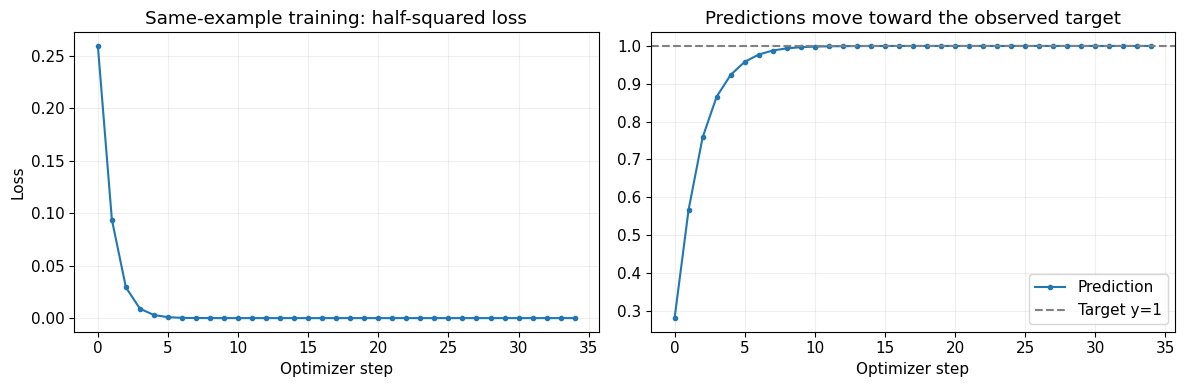

Beginning prediction: 0.2800000011920929 | first-step (analytic): 0.5671187200000001 | loss before: 0.25920000672340393 | after 1 step: 0.09369305521249771 | after 34 steps: 1.7763568394002505e-15


In [30]:
# Actual PyTorch training loop on a single (x,y) example; track the loss across updates.
class TwoLayerTutorial(nn.Module):
    def __init__(self):
        super().__init__();self.hidden=nn.Linear(2,2);self.output=nn.Linear(2,1)
    def forward(self,x): return self.output(torch.relu(self.hidden(x)))
tutorial=TwoLayerTutorial()
with torch.no_grad():
    tutorial.hidden.weight.copy_(torch.tensor([[.1,.2],[.3,-.1]]))
    tutorial.hidden.bias.copy_(torch.tensor([.1,.2]))
    tutorial.output.weight.copy_(torch.tensor([[.5,-.4]]))
    tutorial.output.bias.copy_(torch.tensor([.1]))
opt_tutorial=torch.optim.SGD(tutorial.parameters(),lr=.1)
x_tutorial=torch.tensor([[1.,2.]]);y_tutorial=torch.tensor([[1.]])
loss_history=[];prediction_history=[]
for step in range(35):
    with torch.no_grad():
        prediction_history.append(tutorial(x_tutorial).item())
        loss_history.append((.5*(tutorial(x_tutorial)-y_tutorial).square()).item())
    opt_tutorial.zero_grad()
    current_prediction=tutorial(x_tutorial)
    current_loss=.5*(current_prediction-y_tutorial).square().mean()
    current_loss.backward()
    opt_tutorial.step()
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(loss_history,marker='o',ms=3);axes[0].set_title('Same-example training: half-squared loss')
axes[0].set_xlabel('Optimizer step');axes[0].set_ylabel('Loss');axes[0].grid(alpha=.2)
axes[1].plot(prediction_history,marker='o',ms=3,label='Prediction');axes[1].axhline(1.,ls='--',color='gray',label='Target y=1')
axes[1].set_title('Predictions move toward the observed target');axes[1].set_xlabel('Optimizer step');axes[1].legend();axes[1].grid(alpha=.2)
plt.tight_layout();plt.show()
print('Beginning prediction:',prediction_history[0],'| first-step (analytic):',y_updated,'| loss before:',loss_history[0],'| after 1 step:',loss_history[1],'| after 34 steps:',loss_history[-1])
assert np.isclose(prediction_history[0],.28,atol=1e-6)
assert np.isclose(loss_history[1],L_updated,atol=1e-6)
assert loss_history[-1]<loss_history[0]

## 13. Learning rate challenges, momentum, Adagrad, RMSprop and Adam

A fixed learning rate can be too small in some directions and too large in others. This is why practical training often uses optimizer variants that adapt or smooth the update direction.

This section is organized in four parts:

1. **Learning-rate behavior** on a simple objective,  
2. **Why adaptive / momentum-based methods are useful**,  
3. **PyTorch optimizer syntax** for four common methods,  
4. **Numerical comparison** of SGD, Momentum, Adagrad, RMSprop, and Adam.

All of these methods still rely on gradients; they differ in **how the gradients are converted into parameter updates**.

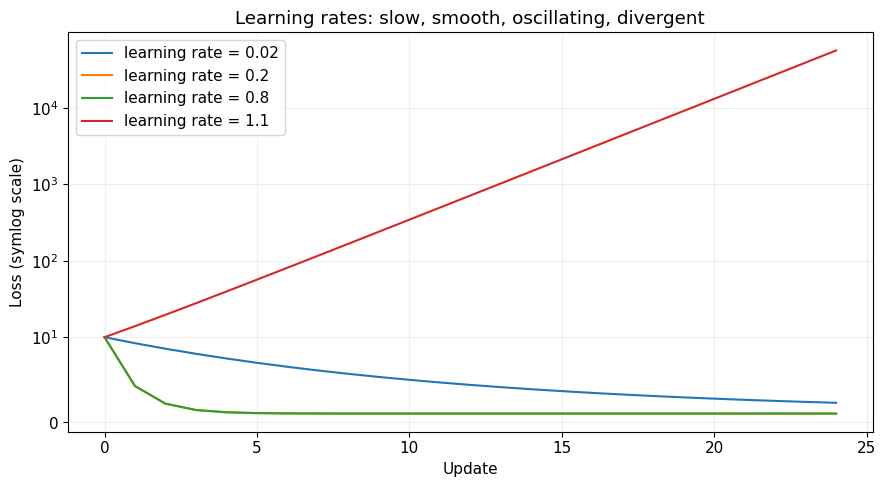

In [31]:
for lr in [.02, .2, .8, 1.1]:
    w = 0.; hist = []
    for _ in range(25):
        hist.append(scalar_loss(w))
        w -= lr*scalar_grad(w)
    plt.plot(hist, label=f'learning rate = {lr}')
plt.yscale('symlog', linthresh=10); plt.xlabel('Update'); plt.ylabel('Loss (symlog scale)')
plt.title('Learning rates: slow, smooth, oscillating, divergent'); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

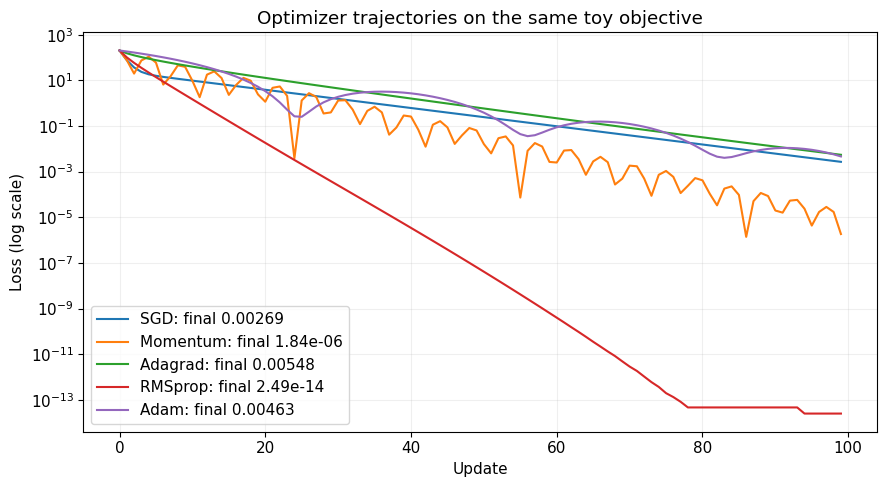

In [32]:
# Same non-isotropic quadratic for four optimizers; explicit gradients avoid dataset noise.
def run_optimizer(kind, steps=100):
    theta = nn.Parameter(torch.tensor([-5., 5.]))
    makers = {'SGD': lambda: torch.optim.SGD([theta], lr=.045), 'Momentum': lambda: torch.optim.SGD([theta], lr=.045, momentum=.85), 'Adagrad': lambda: torch.optim.Adagrad([theta], lr=.8), 'RMSprop': lambda: torch.optim.RMSprop([theta], lr=.18), 'Adam': lambda: torch.optim.Adam([theta], lr=.3)}
    optim = makers[kind]()
    losses = []
    for _ in range(steps):
        optim.zero_grad()
        value = .5*(theta[0]-2)**2 + 5*(theta[1]+1)**2
        value.backward(); optim.step()
        losses.append(value.item())
    return losses, theta.detach().numpy()
for name in ['SGD', 'Momentum', 'Adagrad', 'RMSprop', 'Adam']:
    hist, end = run_optimizer(name)
    plt.plot(hist, label=f'{name}: final {hist[-1]:.3g}')
plt.yscale('log'); plt.title('Optimizer trajectories on the same toy objective')
plt.xlabel('Update'); plt.ylabel('Loss (log scale)'); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

### 13.1 What changes between SGD, momentum, Adagrad, RMSprop, and Adam?

All methods require **gradients computed from the loss**. They differ in how a gradient is converted into the **parameter update**.

**Plain gradient descent / SGD:** for the current (perhaps mini-batch) gradient $g_t=\nabla_\theta L_t(\theta_t)$:

$$\theta_{t+1}=\theta_t-\eta g_t.$$

**SGD with momentum:** store a moving direction $v_t$:

$$v_t=\beta v_{t-1}+g_t,\quad \theta_{t+1}=\theta_t-\eta v_t.$$

This is one common *non-Nesterov* convention; other libraries may scale the velocity differently. Intuition: gradients pointing the same direction across updates accumulate, while back-and-forth components can partially cancel. With $g_1=2$, $g_2=1$, $v_0=0$, $\beta=0.9$, $\eta=0.1$, we get $v_1=2$, $\Delta\theta_1=-0.2$; next $v_2=0.9(2)+1=2.8$, $\Delta\theta_2=-0.28$.

**Adagrad:** accumulate the *sum of squared* past gradients separately for each parameter $j$:

$$G_{t,j}=G_{t-1,j}+g_{t,j}^2,\quad
\theta_{t+1,j}=\theta_{t,j}-\eta\frac{g_{t,j}}{\sqrt{G_{t,j}}+\epsilon}.$$

Frequent large gradients increase the denominator and shrink effective steps in that coordinate; accumulated denominators can grow so much that learning becomes very slow.

**RMSprop:** replace Adagrad's unbounded sum by an **exponential moving average** of squared gradients:

$$s_{t,j}=\rho s_{t-1,j}+(1-\rho)g_{t,j}^2,\quad
\theta_{t+1,j}=\theta_{t,j}-\eta\frac{g_{t,j}}{\sqrt{s_{t,j}}+\epsilon}.$$

**Adam:** maintain estimates of both the first moment (mean-like) and second moment (squared magnitude) of gradients:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\quad
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2.$$

With $m_0=v_0=0$ apply bias correction:

$$\hat m_t=\frac{m_t}{1-\beta_1^t},\qquad \hat v_t=\frac{v_t}{1-\beta_2^t}.$$

Then update:

$$\boxed{\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}}.$$

These equations apply **element-wise** for vector-valued parameters. Defaults, exact epsilon placement, optional weight decay, momentum handling, and framework-specific details may vary. None of these algorithms computes a network's gradients automatically by itself: in PyTorch, `loss.backward()` produces gradients and `optimizer.step()` applies an optimizer's rule. The initial learning rate remains a hyperparameter even for so-called adaptive methods.

**Practical comparison:** smaller learning rates can be stable but slow; excessively large ones can oscillate or diverge. Momentum and adaptive steps sometimes speed training, but there is no guarantee Adam has better generalization or always converges faster than SGD.

In [33]:
# PyTorch optimizer definitions: SGD, Adam, Adagrad, and RMSprop.
model = nn.Linear(3, 1)
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.1)
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.1)
optimizer_adagrad = torch.optim.Adagrad(model.parameters(), lr=0.1)
optimizer_rmsprop = torch.optim.RMSprop(model.parameters(), lr=0.1, momentum=0.8)
print('SGD      :', optimizer_sgd)
print('Adam     :', optimizer_adam)
print('Adagrad  :', optimizer_adagrad)
print('RMSprop  :', optimizer_rmsprop)

SGD      : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Adam     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    weight_decay: 0
)
Adagrad  : Adagrad (
Parameter Group 0
    differentiable: False
    eps: 1e-10
    foreach: None
    fused: None
    initial_accumulator_value: 0
    lr: 0.1
    lr_decay: 0
    maximize: False
    weight_decay: 0
)
RMSprop  : RMSprop (
Parameter Group 0
    alpha: 0.99
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.1
    maximize: False
    momentum: 0.8
    weight_decay: 0
)


In [34]:
# Manual first TWO updates: SGD and classical momentum use identical gradients but different rules.
gradients_demo=[2.,1.];beta_demo=.9;lr_demo=.1
p_sgd=1.;p_momentum=1.;velocity=0.;opt_rows=[]
for idx,g in enumerate(gradients_demo,start=1):
    old_sgd=p_sgd;old_momentum=p_momentum
    p_sgd-=lr_demo*g
    velocity=beta_demo*velocity+g
    p_momentum-=lr_demo*velocity
    opt_rows.append([idx,g,old_sgd,p_sgd,velocity,old_momentum,p_momentum])
display(pd.DataFrame(opt_rows,columns=['step','gradient','SGD before','SGD after','momentum velocity','Momentum before','Momentum after']).round(6))
assert np.isclose(p_sgd,.7)
assert np.isclose(p_momentum,.52)

,step,gradient,SGD before,SGD after,momentum velocity,Momentum before,Momentum after
0,1,2.0,1.0,0.8,2.0,1.0,0.80
1,2,1.0,0.8,0.7,2.8,0.8,0.52


## 14. Underfitting, overfitting, regularization, dropout and early stopping

This section follows a sequence from model fit to methods for improving generalization:

1. **What underfitting and overfitting mean**  
2. **How they look visually**  
3. **How we try to prevent overfitting**  
4. **Why dropout, batch normalization, and early stopping are different ideas**

### 14.1 What is underfitting?

A model **underfits** when it is too simple or insufficiently trained to capture the important structure in the data. Both training and test/validation errors tend to remain relatively high.

### 14.2 What is overfitting?

A model **overfits** when it matches the training set too closely, including noise or accidental fluctuations. Training loss may become very small, while validation/test performance gets worse.

### 14.3 How can we reduce overfitting?

Common strategies include:

- collecting more representative training data,
- reducing model complexity,
- using regularization such as **L2 penalty**,
- using **dropout**,
- using **early stopping** based on a validation set,
- choosing a better learning setup (optimizer, learning rate, augmentation, etc.).

Regularization helps, but no single method guarantees perfect generalization.

### 14.4 Important distinction

- **Dropout** injects stochastic masking during training.  
- **Batch normalization** stabilizes intermediate activations and optimization.  
- **Early stopping** chooses the training epoch before validation performance begins to degrade.

The next figures visualize these ideas explicitly.

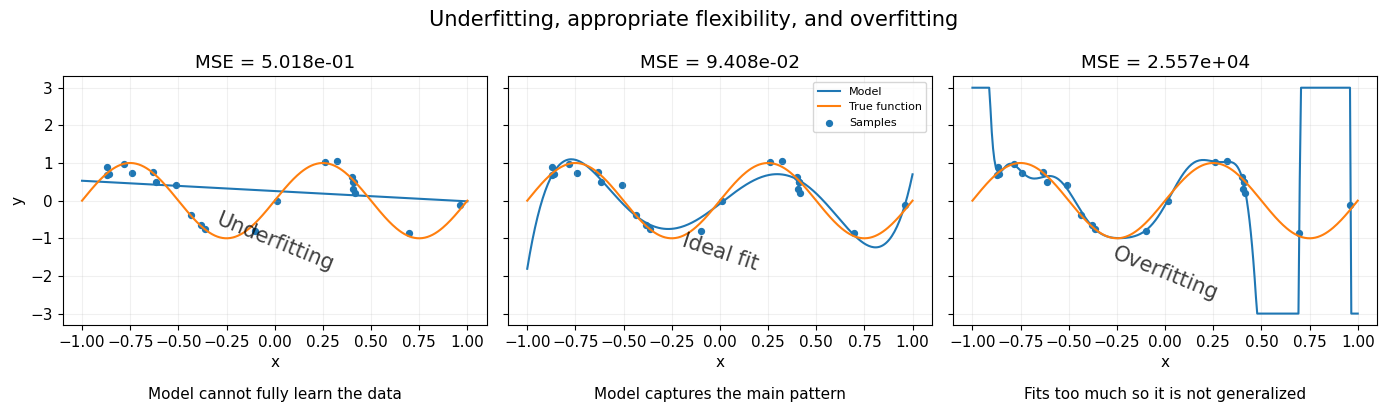

In [35]:
# Plot underfitting, appropriate fitting, and overfitting for the same dataset.
rng = np.random.default_rng(37)
x_train_poly = np.sort(rng.uniform(-1, 1, 22))
y_train_poly = np.sin(2*np.pi*x_train_poly) + rng.normal(0, .18, len(x_train_poly))
x_plot_poly = np.linspace(-1, 1, 300)
y_true_poly = np.sin(2*np.pi*x_plot_poly)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
configs = [
    (1, 'Underfitting', 'Model cannot fully learn the data'),
    (5, 'Ideal fit', 'Model captures the main pattern'),
    (13, 'Overfitting', 'Fits too much so it is not generalized')
]
for ax, (degree, label, caption) in zip(axes, configs):
    with np.errstate(invalid='ignore'):
        coeffs = np.polyfit(x_train_poly, y_train_poly, degree)
    y_fit_plot = np.polyval(coeffs, x_plot_poly)
    mse_true = np.mean((y_fit_plot-y_true_poly)**2)
    ax.plot(x_plot_poly, np.clip(y_fit_plot, -3, 3), label='Model')
    ax.plot(x_plot_poly, y_true_poly, label='True function')
    ax.scatter(x_train_poly, y_train_poly, s=18, label='Samples')
    ax.set_title(f'MSE = {mse_true:.3e}')
    ax.set_xlabel('x')
    ax.grid(alpha=.18)
    ax.text(0.5, -0.25, caption, transform=ax.transAxes, ha='center', va='top', fontsize=11)
    ax.text(0.5, 0.10 if degree == 13 else 0.22, label, transform=ax.transAxes, ha='center', rotation=-22 if degree!=5 else -18, fontsize=15, alpha=.75)
axes[0].set_ylabel('y')
axes[1].legend(loc='upper right', fontsize=8)
fig.suptitle('Underfitting, appropriate flexibility, and overfitting', fontsize=15)
plt.tight_layout(); plt.show()

In [36]:
# Dropout/batchnorm examples; actual values vary by training mode.
values = torch.ones(1, 20)
drop = nn.Dropout(p=.3)
drop.train(); out_train = drop(values)
drop.eval(); out_eval = drop(values)
print('Dropout at training:', out_train.numpy().round(2))
print('Dropout in evaluation:', out_eval.numpy())
assert torch.equal(out_eval, values)
bn = nn.BatchNorm1d(3)
example_batch = torch.tensor([[1., 2., 4.], [3., 4., 6.], [5., 6., 8.], [7., 8., 10.]])
print('Batch norm (training mode) column means approximately zero:', bn(example_batch).detach().mean(dim=0).numpy())

Dropout at training: [[0.   1.43 1.43 1.43 0.   1.43 1.43 1.43 1.43 1.43 1.43 1.43 1.43 0.
  1.43 1.43 1.43 1.43 1.43 1.43]]
Dropout in evaluation: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Batch norm (training mode) column means approximately zero: [0. 0. 0.]


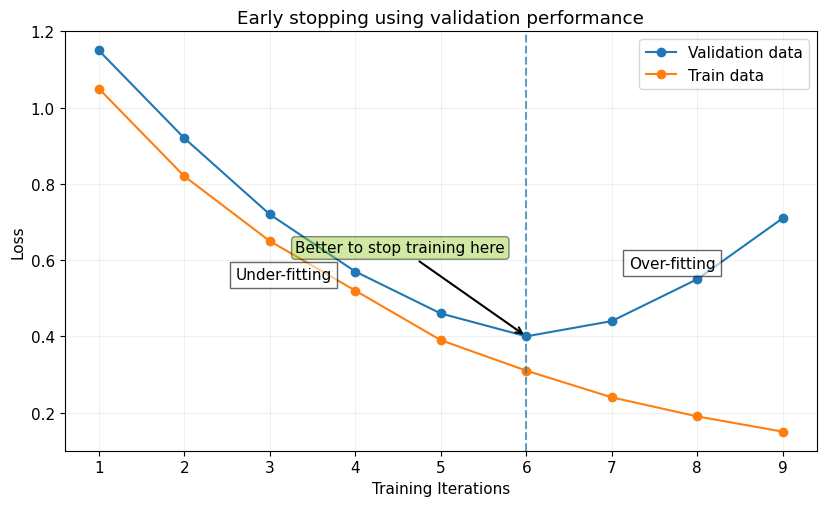

Best stopping epoch: 6 | minimum validation loss: 0.4


In [37]:
# Plot training and validation loss to illustrate early stopping.
train_curve = np.array([1.05, 0.82, 0.65, 0.52, 0.39, 0.31, 0.24, 0.19, 0.15])
valid_curve = np.array([1.15, 0.92, 0.72, 0.57, 0.46, 0.40, 0.44, 0.55, 0.71])
epochs = np.arange(1, len(train_curve)+1)
best_epoch = int(np.argmin(valid_curve) + 1)

plt.figure(figsize=(8.4, 5.2))
plt.plot(epochs, valid_curve, 'o-', label='Validation data')
plt.plot(epochs, train_curve, 'o-', label='Train data')
plt.axvline(best_epoch, linestyle='--', alpha=.7)
plt.annotate('Better to stop training here', xy=(best_epoch, valid_curve[best_epoch-1]),
             xytext=(best_epoch-2.7, valid_curve[best_epoch-1]+0.22),
             bbox=dict(boxstyle='round,pad=0.25', fc='yellowgreen', alpha=.45),
             arrowprops=dict(arrowstyle='->', lw=1.5))
plt.text(2.6, 0.55, 'Under-fitting', bbox=dict(fc='white', alpha=.6))
plt.text(7.2, 0.58, 'Over-fitting', bbox=dict(fc='white', alpha=.6))
plt.xlabel('Training Iterations')
plt.ylabel('Loss')
plt.title('Early stopping using validation performance')
plt.grid(alpha=.18)
plt.legend()
plt.tight_layout(); plt.show()
print('Best stopping epoch:', best_epoch, '| minimum validation loss:', round(valid_curve.min(), 4))

 In actual practice, monitor loss on a **validation set** (not the final test set), remember the parameters from the lowest validation loss, and restore that checkpoint when patience is exhausted. The next cell trains a small network and does exactly this.

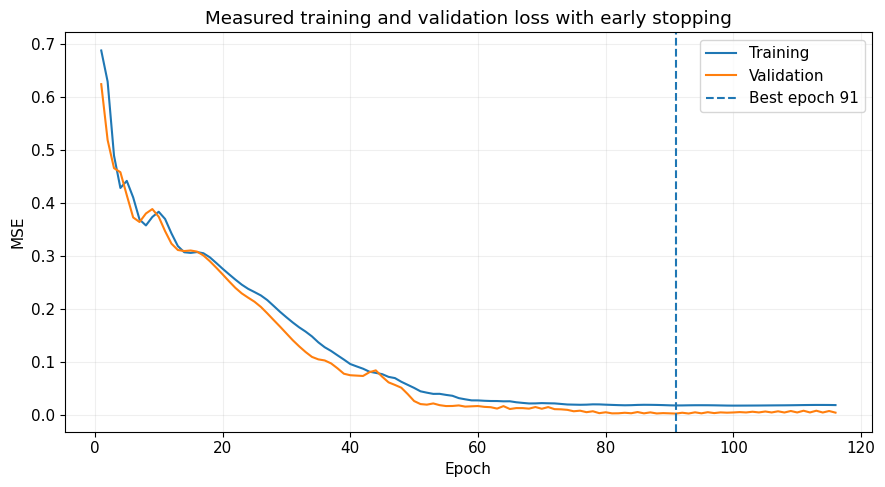

Best epoch: 91, validation MSE: 0.00328, trained epochs: 116


In [38]:
# Actual early stopping with held-out validation observations.
import copy
rng_stop = np.random.default_rng(SEED)
xs_stop = np.sort(rng_stop.uniform(-2, 2, 36))
ys_stop = np.sin(2*xs_stop) + rng_stop.normal(0, 0.20, size=len(xs_stop))
x_train_stop = torch.tensor(xs_stop[:,None], dtype=torch.float32)
y_train_stop = torch.tensor(ys_stop[:,None], dtype=torch.float32)
x_valid_stop = torch.linspace(-2, 2, 90)[:,None]
y_valid_stop = torch.sin(2*x_valid_stop)

torch.manual_seed(SEED)
net_stop = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
optim_stop = torch.optim.Adam(net_stop.parameters(), lr=0.02)
train_hist_stop, valid_hist_stop = [], []
best_val_stop, best_epoch_stop, wait_stop, patience_stop = float('inf'), -1, 0, 25
best_weights_stop = None
for epoch in range(180):
    net_stop.train(); optim_stop.zero_grad()
    loss = F.mse_loss(net_stop(x_train_stop), y_train_stop)
    loss.backward(); optim_stop.step()
    net_stop.eval()
    with torch.no_grad(): val_loss = F.mse_loss(net_stop(x_valid_stop), y_valid_stop).item()
    train_hist_stop.append(loss.item()); valid_hist_stop.append(val_loss)
    if val_loss < best_val_stop - 1e-5:
        best_val_stop = val_loss; best_epoch_stop = epoch+1; wait_stop = 0
        best_weights_stop = copy.deepcopy(net_stop.state_dict())
    else:
        wait_stop += 1
    if wait_stop >= patience_stop: break
net_stop.load_state_dict(best_weights_stop)
plt.figure(figsize=(9,5)); plt.plot(range(1,len(train_hist_stop)+1), train_hist_stop, label='Training')
plt.plot(range(1,len(valid_hist_stop)+1), valid_hist_stop, label='Validation')
plt.axvline(best_epoch_stop, linestyle='--', label=f'Best epoch {best_epoch_stop}')
plt.title('Measured training and validation loss with early stopping')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()
print(f'Best epoch: {best_epoch_stop}, validation MSE: {best_val_stop:.5f}, trained epochs: {len(train_hist_stop)}')

### 14.5 Worked examples of dropout, batch normalization, and early stopping do different jobs

**Dropout** randomly zeroes some activations during training. Suppose a hidden layer produces $a=[2,4,6,8]$ and the dropout probability is $p=0.5$. A sampled mask might be $[1,0,1,0]$. *Inverted dropout* divides the kept activations by $1-p=0.5$:

$$a_{\rm train}'=\frac{[2,4,6,8]\odot[1,0,1,0]}{0.5}=[4,0,12,0].$$

This random mask changes each training pass. In `model.eval()` dropout is disabled and activations are passed through unchanged. With `nn.Dropout(p=0.3)`, **30%** of activations are randomly dropped during training (in expectation), and retained outputs are scaled by $1/0.7$.

**Batch normalization** uses statistics of a mini-batch, standardizes hidden activations, then applies learned parameters $\gamma$ and $\beta$:

$$\hat x_i=\frac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\qquad y_i=\gamma\hat x_i+\beta.$$

For a toy batch $x=[1,3]$ using population variance and ignoring $\epsilon$: $\mu_B=2$, $\sigma_B=1$, so standardized values are $[-1,1]$. If $\gamma=2$, $\beta=0.5$, outputs become $[-1.5,2.5]$. Therefore BatchNorm does **not** force outputs to remain exactly mean zero and variance one *after* its trainable scale/shift. BatchNorm is **not** a hard bound on ReLU activations.

**Early stopping** monitors a held-out **validation** objective. Suppose validation losses by epoch are $[0.9,0.6,0.42,0.44,0.5]$. The best checkpoint is **epoch 3**, even though training loss might keep decreasing at epochs 4 and 5. Choose patience and restore the best validation checkpoint; keep the **test** set separate for a final, unbiased estimate.

**Underfitting**: train and validation errors both remain high. **Overfitting**: train error improves while validation error deteriorates. A moderate gap alone does not prove overfitting, so inspect actual validation trends and sample uncertainty. Adding dropout or weight decay can help, but also makes underfitting possible if too strong.

In [39]:
# Numeric dropout and batch-normalization examples, with transparent intermediate arrays.
example_act=np.array([2.,4.,6.,8.]);sample_mask=np.array([1.,0.,1.,0.]);p_drop=.5
inverted_dropout=example_act*sample_mask/(1-p_drop)
print('Inverted dropout example:',inverted_dropout)
bn_batch=np.array([1.,3.]);mu=bn_batch.mean();sd=bn_batch.std(ddof=0)
normalized=(bn_batch-mu)/sd;gamma=2.;beta=.5
print('Batch mean:',mu,'population SD:',sd,'normalized:',normalized,'after gamma/beta:',gamma*normalized+beta)
val_losses=[.9,.6,.42,.44,.5];best_epoch=int(np.argmin(val_losses)+1)
print('Validation loss by epoch:',val_losses,'| checkpoint selected:',best_epoch)
assert np.array_equal(inverted_dropout,[4.,0.,12.,0.])
assert np.allclose(gamma*normalized+beta,[-1.5,2.5])

Inverted dropout example: [ 4.  0. 12.  0.]
Batch mean: 2.0 population SD: 1.0 normalized: [-1.  1.] after gamma/beta: [-1.5  2.5]
Validation loss by epoch: [0.9, 0.6, 0.42, 0.44, 0.5] | checkpoint selected: 3


## 15. Images, channels, tensors and visual information

An image is a structured array of numerical pixel intensities. A grayscale 8-bit image of height $H$ and width $W$ often stores integers from 0 (black) to 255 (white). An RGB image stores three channels at each location: $[R,G,B]$; its NumPy shape is usually $(H,W,3)$. Many PyTorch convolution modules expect **channels first**, with a batch: $(N,C,H,W)$. Normalizing pixel values to $[0,1]$ is a common preprocessing step: $x_{\rm norm}=x/255$ for 8-bit inputs.

**Example shapes:** a $400\times800$ RGB image has $400\cdot800\cdot3=960{,}000$ channel values; if represented as uint8 it occupies roughly 960 KB (excluding metadata). A $16\times22$ grayscale image has $352$ values. The **255** is a maximum channel value, *not* an additional tensor dimension. A grayscale image is not necessarily better than color; the useful representation depends on the task.

**ImageNet** is a large labeled image database historically used for image classification and localization benchmarks. Its historical milestone charts should not be read as current model rankings. In computer vision, images are numerical tensors. Depending on the task, inputs may be grayscale, RGB, or multispectral.

Digit array shape: (8, 8) | minimum: 0.0 | maximum: 15.0
RGB mock image shape: (400, 800, 3)
PyTorch image batch shape (N,C,H,W): (2, 1, 8, 8)


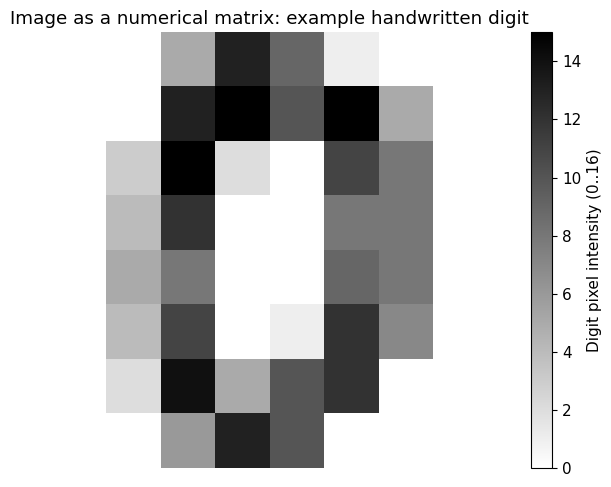

In [40]:
digits = load_digits()  # bundled in scikit-learn: no download required
sample_image = digits.images[0]  # 8x8, values in [0,16] for this dataset
print('Digit array shape:', sample_image.shape, '| minimum:', sample_image.min(), '| maximum:', sample_image.max())
print('RGB mock image shape:', np.zeros((400, 800, 3), dtype=np.uint8).shape)
np_image_batch = np.stack([sample_image, digits.images[1]], axis=0)
torch_image_batch = torch.tensor(np_image_batch[:, None, :, :], dtype=torch.float32) / 16
print('PyTorch image batch shape (N,C,H,W):', tuple(torch_image_batch.shape))
plt.imshow(sample_image, cmap='gray_r', interpolation='nearest')
plt.colorbar(label='Digit pixel intensity (0..16)')
plt.title('Image as a numerical matrix: example handwritten digit')
plt.axis('off'); plt.tight_layout(); plt.show()

## 16. Convolution filters, local features and weight sharing

A conventional dense layer first flattens an image into a long vector and therefore ignores spatial locality in its architecture. A **convolutional layer** instead uses small local receptive fields and applies the **same trainable filter** at many spatial positions.

For a single-channel image $X$ and kernel $K$ of size $k_h\times k_w$, with stride 1 and no padding, the valid cross-correlation used by most deep learning libraries is

$$\boxed{Z_{r,c}=b+\sum_{i=0}^{k_h-1}\sum_{j=0}^{k_w-1}K_{i,j}X_{r+i,c+j}}.$$

An activation function may then produce $A_{r,c}=h(Z_{r,c})$.

### What the filters mean

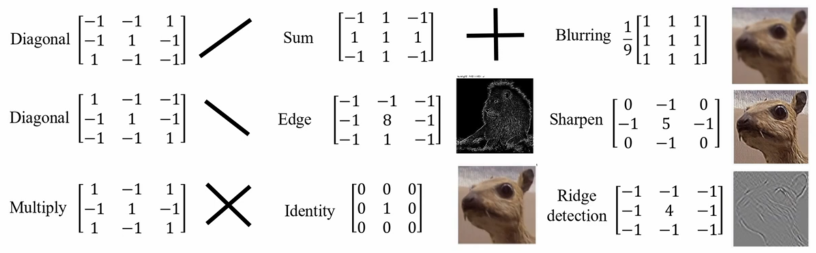

- **Identity**: keeps the center value and leaves the image mostly unchanged.  
- **Blur / averaging**: smooths local variation by averaging nearby pixels.  
- **Sharpen**: emphasizes local contrast and makes edges appear stronger.  
- **Edge / ridge detection**: highlights abrupt spatial changes in intensity.  
- **Diagonal-like filters**: respond more strongly to a diagonal pattern aligned with the filter.  
- **Plus-shaped / cross filters**: emphasize a different local shape pattern.

In introductory image processing these kernels are chosen manually. In CNNs, however, the filter values are usually **learned automatically by backpropagation** so the network discovers useful local patterns directly from data.

The next code cell computes several such filter responses explicitly.

### Manual filter calculation: elementwise multiplication and summation

An image patch and a handcrafted *plus-pattern* filter can be written as

$$P=\begin{bmatrix}1&-1&1\\1&-1&-1\\1&-1&1\end{bmatrix},\qquad
K=\begin{bmatrix}-1&1&-1\\1&1&1\\-1&1&-1\end{bmatrix}.$$

For one output pixel, multiply the **matching entries**, then add the nine products:

$$P\odot K=\begin{bmatrix}-1&-1&-1\\1&-1&-1\\-1&-1&-1\end{bmatrix}.$$

$$\boxed{\sum_{i=1}^{3}\sum_{j=1}^{3}P_{ij}K_{ij}=-7.}$$

The filter is reused at every spatial position (weight sharing). Distinct CNN output channels use **different learned kernels**, typically spanning all input channels. The kernels in this example are hand-designed to illustrate filtering; CNN filters are learned through backpropagation.

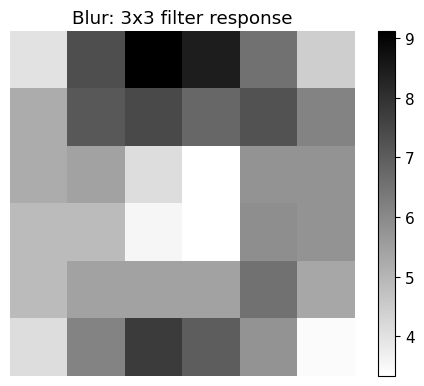

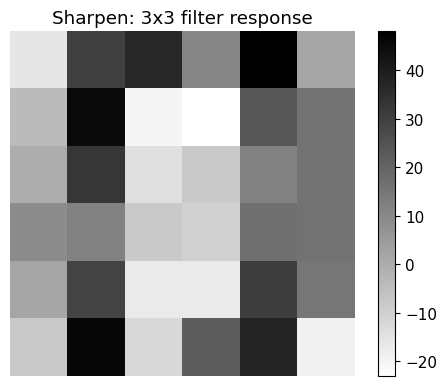

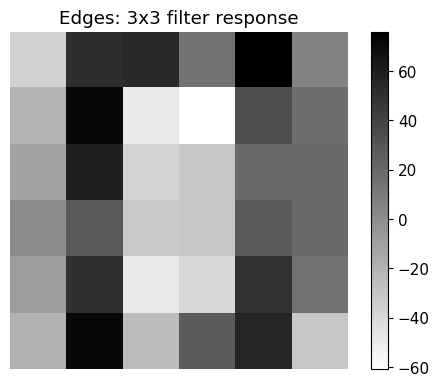

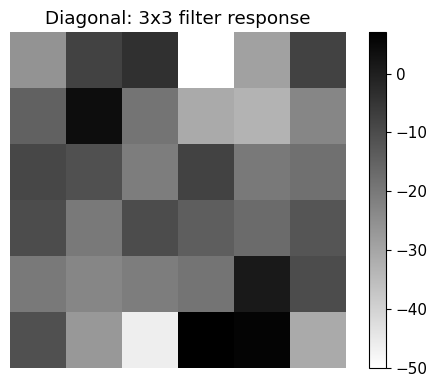

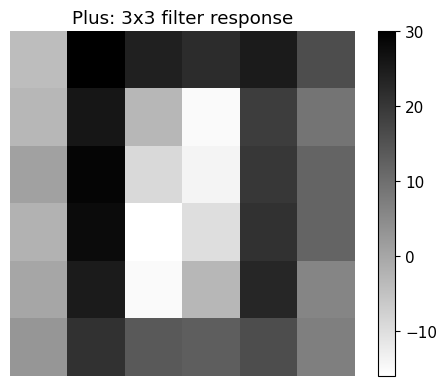

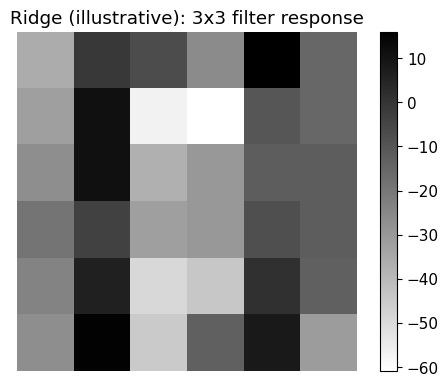

In [41]:
# A NumPy implementation makes each position explicit (same convention as torch.conv2d).
def correlate2d_valid(image, kernel):
    h, w = image.shape; kh, kw = kernel.shape
    output = np.empty((h-kh+1, w-kw+1), dtype=float)
    for r in range(h-kh+1):
        for c in range(w-kw+1): output[r, c] = np.sum(image[r:r+kh, c:c+kw]*kernel)
    return output
kernels = {
    'Identity': np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=float),
    'Blur': np.ones((3,3))/9,
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
    'Edges': np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=float),
    'Diagonal': np.array([[-1,-1,1],[-1,1,-1],[1,-1,-1]], dtype=float),
    'Plus': np.array([[-1,1,-1],[1,1,1],[-1,1,-1]], dtype=float),
    'Other diagonal': np.array([[1,-1,-1],[-1,1,-1],[-1,-1,1]], dtype=float),
    'Cross-shaped': np.array([[1,-1,1],[-1,1,-1],[1,-1,1]], dtype=float),
    'Ridge (illustrative)': np.array([[-1,-1,-1],[-1,4,-1],[-1,-1,-1]], dtype=float),
}
for name in ['Blur','Sharpen','Edges','Diagonal','Plus','Ridge (illustrative)']:
    response = correlate2d_valid(sample_image.astype(float), kernels[name])
    plt.figure(figsize=(5, 4)); plt.imshow(response, cmap='gray_r'); plt.title(f'{name}: 3x3 filter response')
    plt.colorbar(); plt.axis('off'); plt.tight_layout(); plt.show()

In [42]:
# Verify the elementwise products and their sum of -7.
patch_minus7 = np.array([[1,-1,1],[1,-1,-1],[1,-1,1]])
filter_plus = np.array([[-1,1,-1],[1,1,1],[-1,1,-1]])
products_minus7 = patch_minus7 * filter_plus
print('Input patch:\n', patch_minus7)
print('3x3 filter:\n', filter_plus)
print('Elementwise products:\n', products_minus7)
print('Sum of nine products:', products_minus7.sum())
assert products_minus7.sum() == -7

Input patch:
 [[ 1 -1  1]
 [ 1 -1 -1]
 [ 1 -1  1]]
3x3 filter:
 [[-1  1 -1]
 [ 1  1  1]
 [-1  1 -1]]
Elementwise products:
 [[-1 -1 -1]
 [ 1 -1 -1]
 [-1 -1 -1]]
Sum of nine products: -7


## 17. Full convolution calculation: $5\times5$ input and $3\times3$ filter

Consider the following input matrix and cross-shaped convolution kernel:
$$X=\begin{bmatrix}
0&0&0&0&0\\
0&0&1&0&0\\
1&1&1&1&1\\
0&1&1&1&0\\
0&0&1&1&0
\end{bmatrix},\qquad
K=\begin{bmatrix}0&1&0\\1&1&1\\0&1&0\end{bmatrix}.$$
With stride $S=1$, padding $P=0$, no bias and no activation, every output is the **sum of five selected positions** of a $3\times3$ patch:
$$Y_{r,c}=X_{r,c+1}+X_{r+1,c}+X_{r+1,c+1}+X_{r+1,c+2}+X_{r+2,c+1}.$$
Use **zero-based row and column indices** in this formula (Python convention). All nine calculations are:

| Output location | Five values selected by the cross-shaped filter | Sum |
|---|---|---:|
| $Y_{0,0}$ | $0+0+0+1+1$ | **2** |
| $Y_{0,1}$ | $0+0+1+0+1$ | **2** |
| $Y_{0,2}$ | $0+1+0+0+1$ | **2** |
| $Y_{1,0}$ | $0+1+1+1+1$ | **4** |
| $Y_{1,1}$ | $1+1+1+1+1$ | **5** |
| $Y_{1,2}$ | $0+1+1+1+1$ | **4** |
| $Y_{2,0}$ | $1+0+1+1+0$ | **3** |
| $Y_{2,1}$ | $1+1+1+1+1$ | **5** |
| $Y_{2,2}$ | $1+1+1+0+1$ | **4** |

Therefore:
$$\boxed{Y=\begin{bmatrix}2&2&2\\4&5&4\\3&5&4\end{bmatrix}}.$$
The output becomes $3\times3$ because there are three valid filter locations across each input dimension. We now verify every result using two independent implementations.

In [43]:
X_exact = np.array([[0,0,0,0,0],[0,0,1,0,0],[1,1,1,1,1],[0,1,1,1,0],[0,0,1,1,0]], dtype=float)
K_exact = np.array([[0,1,0],[1,1,1],[0,1,0]], dtype=float)
Y_expected = np.array([[2,2,2],[4,5,4],[3,5,4]])
Y_numpy = correlate2d_valid(X_exact, K_exact)
conv_exact = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0, bias=False)
with torch.no_grad(): conv_exact.weight.copy_(torch.tensor(K_exact, dtype=torch.float32)[None, None])
Y_torch = conv_exact(torch.tensor(X_exact, dtype=torch.float32)[None, None]).detach().numpy()[0, 0]
print('Input X:\n', X_exact.astype(int))
print('Filter K:\n', K_exact.astype(int))
print('NumPy calculated feature map:\n', Y_numpy.astype(int))
print('PyTorch feature map:\n', Y_torch.astype(int))
assert np.array_equal(Y_numpy, Y_expected)
assert np.array_equal(Y_torch, Y_expected)

Input X:
 [[0 0 0 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 1 0]]
Filter K:
 [[0 1 0]
 [1 1 1]
 [0 1 0]]
NumPy calculated feature map:
 [[2 2 2]
 [4 5 4]
 [3 5 4]]
PyTorch feature map:
 [[2 2 2]
 [4 5 4]
 [3 5 4]]


Y[0,0]:  0 + 0 + 0 + 1 + 1 = 2
Y[0,1]:  0 + 0 + 1 + 0 + 1 = 2
Y[0,2]:  0 + 1 + 0 + 0 + 1 = 2
Y[1,0]:  0 + 1 + 1 + 1 + 1 = 4
Y[1,1]:  1 + 1 + 1 + 1 + 1 = 5
Y[1,2]:  0 + 1 + 1 + 1 + 1 = 4
Y[2,0]:  1 + 0 + 1 + 1 + 0 = 3
Y[2,1]:  1 + 1 + 1 + 1 + 1 = 5
Y[2,2]:  1 + 1 + 1 + 0 + 1 = 4


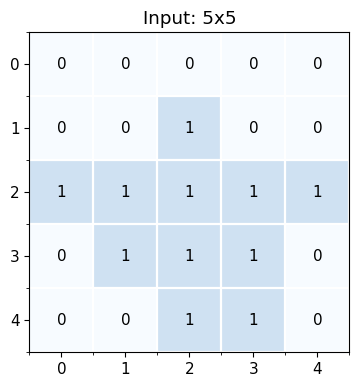

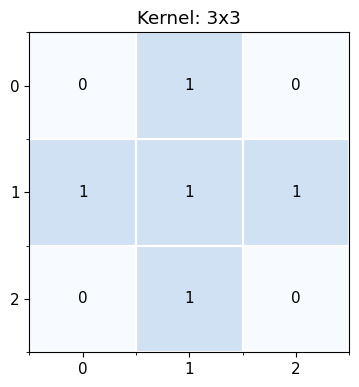

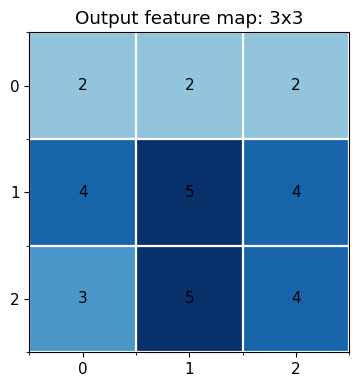

In [44]:
# Show the manual arithmetic for each patch and the 3 representations as figures.
for r in range(3):
    for c in range(3):
        patch = X_exact[r:r+3, c:c+3]
        selected = patch[K_exact==1].astype(int).tolist()
        print(f'Y[{r},{c}]: ', ' + '.join(map(str, selected)), '=', int(np.sum(patch*K_exact)))
for arr, label in [(X_exact, 'Input: 5x5'), (K_exact, 'Kernel: 3x3'), (Y_numpy, 'Output feature map: 3x3')]:
    fig, ax = plt.subplots(figsize=(4, 4)); ax.imshow(arr, cmap='Blues', vmin=0, vmax=5)
    ax.set_xticks(range(arr.shape[1])); ax.set_yticks(range(arr.shape[0]))
    ax.set_xticks(np.arange(-.5, arr.shape[1], 1), minor=True); ax.set_yticks(np.arange(-.5, arr.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.6)
    for (r, c), value in np.ndenumerate(arr): ax.text(c, r, str(int(value)), ha='center', va='center')
    ax.set_title(label); plt.tight_layout(); plt.show()

## 18. Kernel size, stride, padding, channels and output shape

For an input with spatial height $H$ and width $W$, kernel dimensions $(K_h,K_w)$, padding $(P_h,P_w)$, dilation $(D_h,D_w)$ and strides $(S_h,S_w)$:
$$H_{\rm out}=\left\lfloor\frac{H+2P_h-D_h(K_h-1)-1}{S_h}+1\right\rfloor,$$
$$W_{\rm out}=\left\lfloor\frac{W+2P_w-D_w(K_w-1)-1}{S_w}+1\right\rfloor.$$
With dilation $1$ and identical dimensions, this simplifies to the familiar $\lfloor(H+2P-K)/S\rfloor+1$.

**Numerical example:** $H=W=5$, $K=3$, $P=0$, $S=1$ gives $(5-3)/1+1=3$ output rows and columns. With $S=2$ and $P=1$: $\lfloor(5+2-3)/2\rfloor+1=3$.

**Channels and parameters:** An RGB image has $C_{\rm in}=3$. A layer with $C_{\rm out}=16$ learned $3\times3$ filters produces 16 output feature maps, each aggregating **all three input channels**. Parameter count (one bias per filter) is:
$$\boxed{N_{\rm param}=C_{\rm out}\left(C_{\rm in}K_hK_w+1\right)}=16(3\cdot3\cdot3+1)=448.$$
`nn.Conv2d(5,5,kernel_size=3)` means **five input channels and five output channels**, *not* a 5-by-5 image. Spatial sizes can shrink while the number of channels grows, so total activation memory may increase or decrease.

In [45]:
def conv_out(n, kernel, stride=1, padding=0, dilation=1):
    return (n + 2*padding - dilation*(kernel-1) - 1)//stride + 1
configurations = [(5,3,1,0), (5,3,2,1), (80,5,2,0), (38,5,2,0), (17,5,2,0)]
display(pd.DataFrame([{'Input size': H, 'Kernel': K, 'Stride': S, 'Padding': P, 'Output size': conv_out(H,K,S,P)} for H,K,S,P in configurations]))
layer_channels = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
toy_rgb = torch.randn(2, 3, 24, 24)
print('Input (N,C,H,W):', tuple(toy_rgb.shape), 'Output:', tuple(layer_channels(toy_rgb).shape))
print('Calculated parameter count:', 16*(3*3*3+1), 'Actual:', sum(p.numel() for p in layer_channels.parameters()))
assert sum(p.numel() for p in layer_channels.parameters()) == 448

,Input size,Kernel,Stride,Padding,Output size
0,5,3,1,0,3
1,5,3,2,1,3
2,80,5,2,0,38
3,38,5,2,0,17
4,17,5,2,0,7


Input (N,C,H,W): (2, 3, 24, 24) Output: (2, 16, 24, 24)
Calculated parameter count: 448 Actual: 448


## 19. Max pooling, average pooling, ReLU and batch normalization in CNNs

**Pooling** summarizes spatial neighborhoods. For a $p\times p$ patch $P_{r,c}$, max pooling returns $\max(P_{r,c})$ and average pooling returns the arithmetic mean. Pooling introduces downsampling and some tolerance to small translations, at the cost of location detail. Pooling has no learned kernel weights; *pooling window* is not the same as a convolution kernel.

**Max-pooling example.** Using a $6\times6$ array and a $3\times3$ max-pooling window with stride 3 partitions the input into four disjoint blocks. Their maxima are:
$$\boxed{\operatorname{MaxPool}(X)=\begin{bmatrix}3&2\\5&1\end{bmatrix}}.$$
For a $6\times6$ input, `nn.MaxPool2d(kernel_size=3, stride=3)` produces this $2\times2$ result. In contrast, a $2\times2$ window with stride 2 would produce a $3\times3$ output.

A standard CNN block might be convolution $\rightarrow$ batch normalization $\rightarrow$ ReLU $\rightarrow$ max pooling. A `BatchNorm2d(C)` layer normalizes channels and has learned scale/shift parameters; it does not constrain the upper bound of ReLU outputs. Exact ordering is an architecture choice.

### Manual max-pooling calculation

Consider an input of size $6\times6$, a $3\times3$ window and stride $3$. Non-overlapping windows start at $(0,0)$, $(0,3)$, $(3,0)$, and $(3,3)$. Their maxima are $3$, $2$, $5$, and $1$ respectively. Therefore,

$$\boxed{\mathrm{MaxPool}_{3\times3,S=3}(X)=\begin{bmatrix}3&2\\5&1\end{bmatrix}.}$$

For **average pooling**, replace each maximum by the arithmetic mean of its nine values. Both operations are calculated **independently for each input channel**, and neither pooling method has trainable filter weights. Applying ReLU does *not* resize feature maps; pooling or a convolution with suitable stride changes their spatial size.

For the $6\times6\to2\times2$ calculation above, use `nn.MaxPool2d(kernel_size=3, stride=3)`, as in the following code. A separate $2\times2$ window with stride 2 is also common, but produces different output dimensions.

Original 6x6:
 [[3 0 0 0 1 1]
 [2 3 1 2 2 0]
 [1 3 1 1 1 1]
 [0 5 1 0 1 0]
 [1 5 4 1 1 0]
 [3 0 2 0 0 1]]
Max pooled 2x2:
 [[3 2]
 [5 1]]
Average pooled 2x2:
 [[1.5556 1.    ]
 [2.3333 0.4444]]


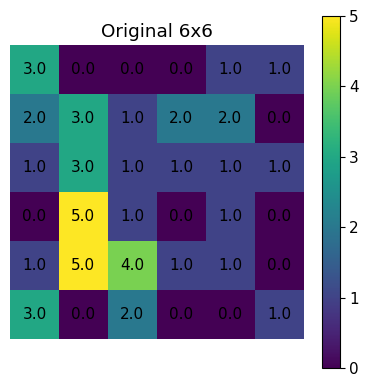

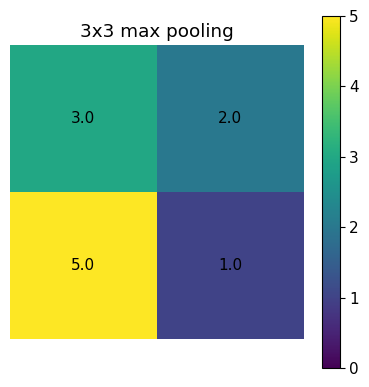

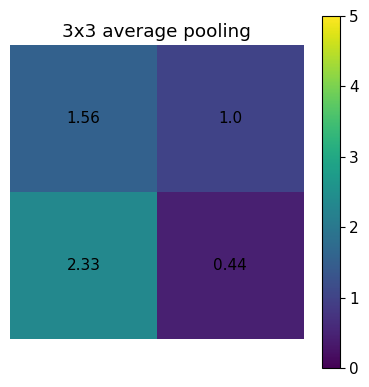

In [46]:
X_pool = torch.tensor([[
    [3,0,0,0,1,1], [2,3,1,2,2,0], [1,3,1,1,1,1],
    [0,5,1,0,1,0], [1,5,4,1,1,0], [3,0,2,0,0,1]
]], dtype=torch.float32)[None, ...]
max_result = F.max_pool2d(X_pool, kernel_size=3, stride=3)
avg_result = F.avg_pool2d(X_pool, kernel_size=3, stride=3)
print('Original 6x6:\n', X_pool[0,0].numpy().astype(int))
print('Max pooled 2x2:\n', max_result[0,0].numpy().astype(int))
print('Average pooled 2x2:\n', avg_result[0,0].numpy().round(4))
assert torch.equal(max_result[0,0], torch.tensor([[3.,2.],[5.,1.]]))
for tensor, title in [(X_pool[0,0], 'Original 6x6'), (max_result[0,0], '3x3 max pooling'), (avg_result[0,0], '3x3 average pooling')]:
    plt.figure(figsize=(4, 4)); plt.imshow(tensor.numpy(), cmap='viridis', vmin=0, vmax=5)
    for (r,c),value in np.ndenumerate(tensor.numpy()): plt.text(c,r,round(float(value),2),ha='center',va='center')
    plt.title(title); plt.axis('off'); plt.colorbar(); plt.tight_layout(); plt.show()

## 20. End-to-end CNN: convolution → activation → pooling → classification

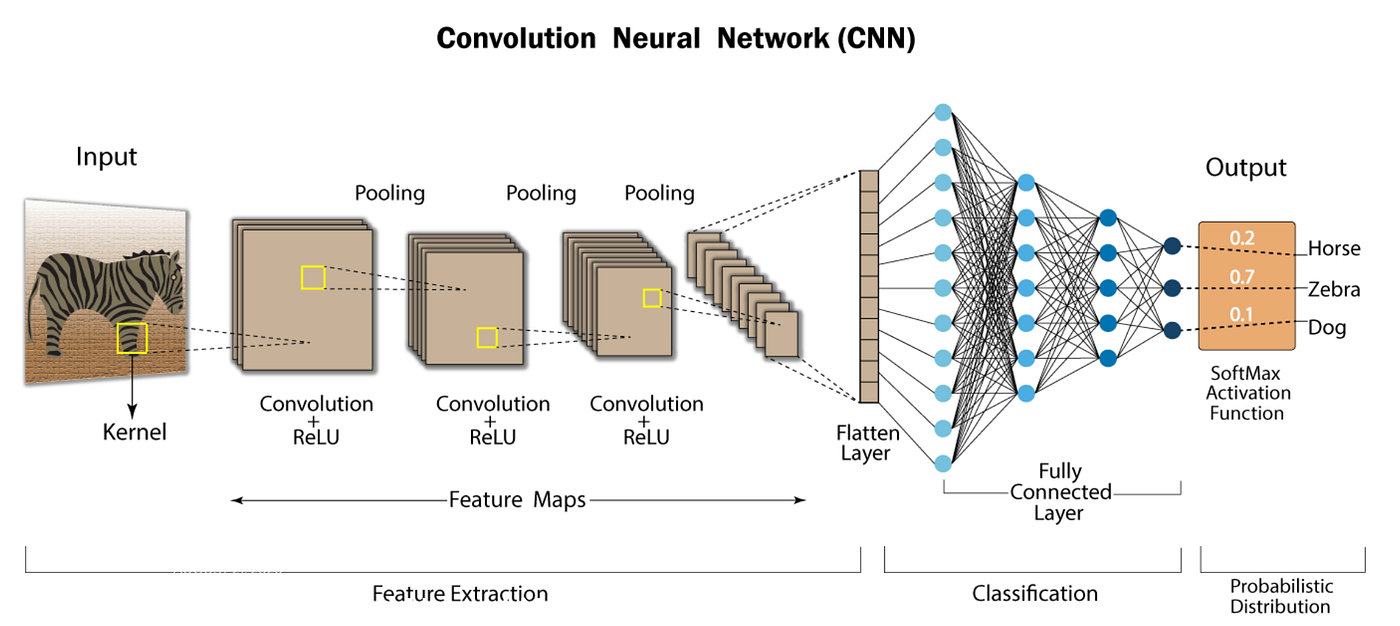

A CNN converts spatial data into layered features, then produces an output for a task:
$$\text{image}\rightarrow\text{Conv}\rightarrow\text{ReLU}\rightarrow\text{Pool}\rightarrow\text{Conv}\rightarrow\text{ReLU}\rightarrow\text{Pool}\rightarrow\text{Flatten}\rightarrow\text{Linear logits}.$$
Each convolution combines local pixels with shared learned coefficients. Increasing filters raises channel count; pooling usually shrinks spatial dimensions. A **Softmax** can convert multiclass logits into probabilities:
$$\operatorname{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}},\qquad\sum_i\operatorname{softmax}(z_i)=1.$$
**Numerical example** for logits $[2,1,0]$: exponentials $[7.389,2.718,1]$, sum $\approx11.107$, probabilities $\approx[0.6652,0.2447,0.0900]$. For training we pass raw logits to `CrossEntropyLoss`.

We'll train a small CNN on scikit-learn's **built-in 8×8 handwritten digits** (no internet download). This is a supervised image-classification example. Use a held-out test set and plot training loss and validation accuracy.

In [47]:
# Load the image dataset and create train/validation/test sets.
torch.set_num_threads(min(2, torch.get_num_threads()))
all_images = (digits.images/16.0).astype(np.float32)[:, None, :, :]
all_labels = digits.target.astype(np.int64)
id_train, id_temp = train_test_split(np.arange(len(all_labels)), test_size=.3, stratify=all_labels, random_state=SEED)
id_val, id_test = train_test_split(id_temp, test_size=.5, stratify=all_labels[id_temp], random_state=SEED)
Xtrain = torch.tensor(all_images[id_train]); ytrain = torch.tensor(all_labels[id_train])
Xvalid = torch.tensor(all_images[id_val]); yvalid = torch.tensor(all_labels[id_val])
Xtest = torch.tensor(all_images[id_test]); ytest = torch.tensor(all_labels[id_test])
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(16*2*2, 32), nn.ReLU(), nn.Linear(32, 10))
    def forward(self, x): return self.head(self.features(x))
cnn_digits = TinyCNN()
print(cnn_digits)
print('CNN parameters:', sum(p.numel() for p in cnn_digits.parameters()))
print('Feature map shape:', tuple(cnn_digits.features(Xtrain[:3]).shape), '| logits shape:', tuple(cnn_digits(Xtrain[:3]).shape))
assert cnn_digits(Xtrain[:3]).shape == (3,10)

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
CNN parameters: 3658
Feature map shape: (3, 16, 2, 2) | logits shape: (3, 10)


Epoch  1 | training CE=2.2778 | validation accuracy=0.500
Epoch  2 | training CE=1.5614 | validation accuracy=0.770
Epoch  3 | training CE=0.6462 | validation accuracy=0.881
Epoch  4 | training CE=0.4449 | validation accuracy=0.885
Epoch  5 | training CE=0.3455 | validation accuracy=0.907
Epoch  6 | training CE=0.2483 | validation accuracy=0.911
Epoch  7 | training CE=0.2103 | validation accuracy=0.933
Epoch  8 | training CE=0.1822 | validation accuracy=0.915
Held-out test accuracy: 0.9296


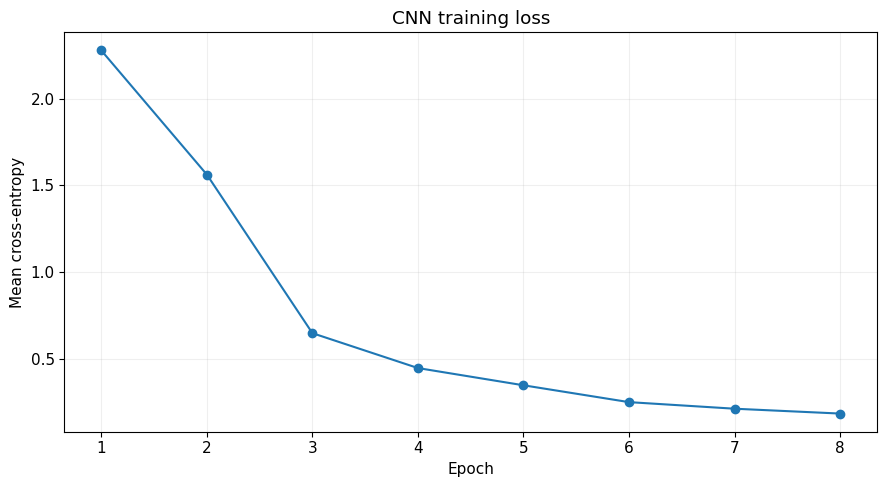

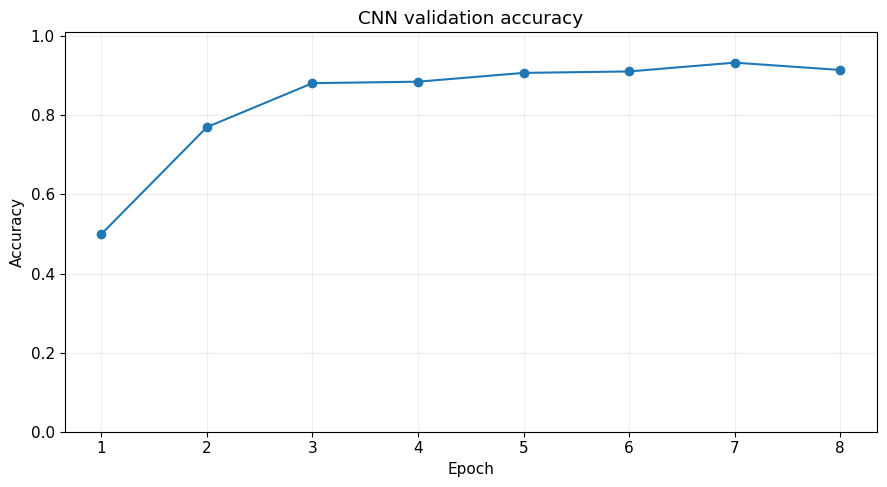

In [48]:
# Mini-batch training; validation is evaluated with dropout/batchnorm (if any) in eval mode.
torch.manual_seed(SEED)
cnn_digits = TinyCNN()
opt_digits = torch.optim.Adam(cnn_digits.parameters(), lr=.008)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtrain,ytrain), batch_size=64, shuffle=True)
digits_loss, digits_val_accuracy = [], []
for epoch in range(8):
    cnn_digits.train(); total, seen = 0., 0
    for bx, by in loader:
        opt_digits.zero_grad(); logits = cnn_digits(bx); loss = F.cross_entropy(logits, by)
        loss.backward(); opt_digits.step()
        total += loss.item()*len(bx); seen += len(bx)
    cnn_digits.eval()
    with torch.no_grad(): accuracy = (cnn_digits(Xvalid).argmax(dim=1)==yvalid).float().mean().item()
    digits_loss.append(total/seen); digits_val_accuracy.append(accuracy)
    print(f'Epoch {epoch+1:2d} | training CE={total/seen:.4f} | validation accuracy={accuracy:.3f}')
with torch.no_grad(): test_accuracy = (cnn_digits(Xtest).argmax(dim=1)==ytest).float().mean().item()
print('Held-out test accuracy:', round(test_accuracy, 4))
plt.plot(range(1,len(digits_loss)+1), digits_loss, 'o-')
plt.title('CNN training loss'); plt.xlabel('Epoch'); plt.ylabel('Mean cross-entropy'); plt.grid(alpha=.2); plt.tight_layout(); plt.show()
plt.plot(range(1,len(digits_val_accuracy)+1), digits_val_accuracy, 'o-')
plt.title('CNN validation accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.ylim(0,1.01); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

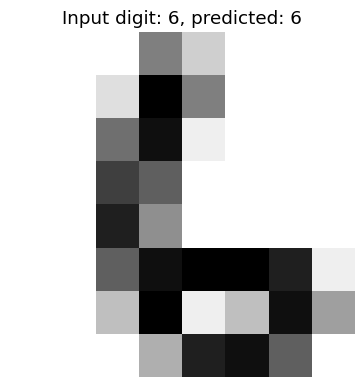

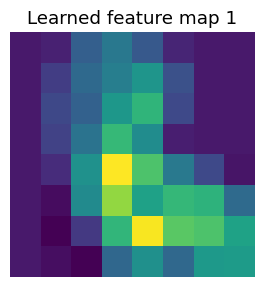

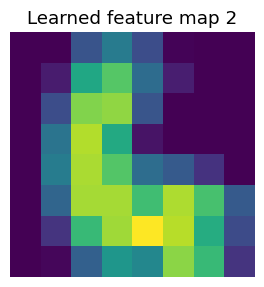

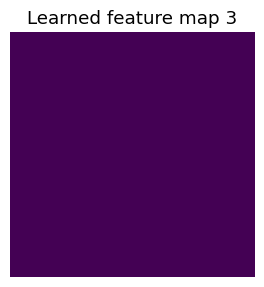

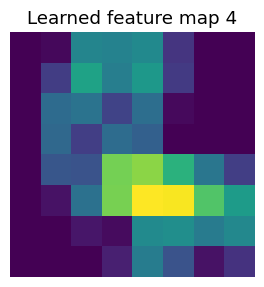

Class probabilities: [0.002 0.    0.    0.    0.003 0.    0.994 0.    0.001 0.   ] | sum: 0.9999999403953552


In [49]:
# View one prediction and learned feature maps. Feature maps are learned responses, not hand-labeled parts.
cnn_digits.eval()
with torch.no_grad():
    one = Xtest[0:1]
    maps = cnn_digits.features[:2](one)[0]  # first convolution then ReLU
    probs = torch.softmax(cnn_digits(one),dim=1)[0]
plt.figure(figsize=(4, 4)); plt.imshow(one[0,0], cmap='gray_r'); plt.title(f'Input digit: {ytest[0].item()}, predicted: {probs.argmax().item()}')
plt.axis('off'); plt.tight_layout(); plt.show()
for channel in range(4):
    plt.figure(figsize=(3,3)); plt.imshow(maps[channel].numpy(), cmap='viridis')
    plt.title(f'Learned feature map {channel+1}'); plt.axis('off'); plt.tight_layout(); plt.show()
print('Class probabilities:', np.round(probs.numpy(),3), '| sum:', probs.sum().item())

## 21. Other deep learning and neural model families

Several neural network architectures address different types of data and learning problems; they are **not interchangeable algorithms**.

| Model | Mathematical idea | When commonly useful |
|---|---|---|
| **MLP** | $a_{\ell}=h(W_\ell a_{\ell-1}+b_\ell)$ | Fixed-length tabular or vector inputs |
| **CNN** | Locally shared filters over image/tensor regions | Spatial observations, vision |
| **RNN** | $h_t=\tanh(W_x x_t+W_h h_{t-1}+b)$ | Sequential observations |
| **LSTM** | Gates control memory state $c_t$ and hidden state $h_t$ | Longer temporal dependencies |
| **GAN** | Generator $G$ competes with discriminator $D$ | Learning/generating data distributions |
| **RBF Network** | Hidden radial units such as $\phi_j(x)=e^{-\|x-c_j\|^2/(2\sigma_j^2)}$ | Smooth local function approximation |
| **SOM** | Prototype units updated near best matching unit | Unsupervised clustering/visualization |

**LSTM gates (simplified):** input gate $i_t=\sigma(W_i[x_t,h_{t-1}]+b_i)$, forget gate $f_t=\sigma(W_f[x_t,h_{t-1}]+b_f)$, output gate $o_t=\sigma(W_o[x_t,h_{t-1}]+b_o)$, candidate $\tilde c_t=\tanh(W_c[x_t,h_{t-1}]+b_c)$. Then
$$c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t,\qquad h_t=o_t\odot\tanh(c_t).$$
A GAN commonly uses the minimax objective $\min_G\max_D\;\mathbb E_{x\sim p_{\rm data}}\log D(x)+\mathbb E_z\log(1-D(G(z)))$. A SOM picks a best matching prototype $j^*=\operatorname*{arg\,min}_j\|x-m_j\|$ and adjusts that unit and its neighborhood.

**Model selection:** Choose MLPs for fixed-length vectors, CNNs for spatial data, RNNs/LSTMs for sequences, and specialized architectures for generation, local approximation, or clustering.

In [50]:
# Numerical RBF response and an RNN/LSTM shape demonstration.
centers = np.array([[0.,0.], [1.,1.], [-1.,1.]])
x_rbf = np.array([.5, .25]); sigma = .8
rbf_values = np.exp(-np.sum((centers-x_rbf)**2, axis=1)/(2*sigma**2))
print('RBF input:', x_rbf, '| center responses:', rbf_values)
toy_sequence = torch.randn(4, 6, 3)  # batch=4, time=6, features=3
rnn = nn.RNN(input_size=3, hidden_size=5, batch_first=True)
lstm = nn.LSTM(input_size=3, hidden_size=5, batch_first=True)
rnn_output, rnn_hidden = rnn(toy_sequence)
lstm_output, (lstm_hidden, lstm_cell) = lstm(toy_sequence)
print('RNN sequence output:', tuple(rnn_output.shape), '| LSTM sequence output:', tuple(lstm_output.shape))
print('LSTM final hidden/cell:', tuple(lstm_hidden.shape), tuple(lstm_cell.shape))

RBF input: [0.5  0.25] | center responses: [0.7834 0.5301 0.1111]
RNN sequence output: (4, 6, 5) | LSTM sequence output: (4, 6, 5)
LSTM final hidden/cell: (1, 4, 5) (1, 4, 5)


## 22. Popular CNN architectures, AlexNet, Inception, bottlenecks and YOLO

| Name | Central design idea | Typical application/contribution |
|---|---|---|
| **LeNet-5** | Early conv/subsampling/classification stages | Handwritten character recognition |
| **Dan Cireșan-style GPU ConvNets** | Fast GPU-trained convnets, often with multiple columns/models | Early large-scale image recognition improvements |
| **AlexNet** | Deeper convnet, ReLU, pooling and dropout, GPU training | Historical large-scale image classification |
| **OverFeat** | Integrated convnet-based recognition, localization and detection | Object localization/detection |
| **VGG** | Stacks of small $3\times3$ convolutions | Standardized deep vision backbones |
| **Network-in-Network** | Micro-networks/pointwise processing and global pooling ideas | Rich channel mixing |
| **GoogLeNet / Inception** | Parallel kernels and pooled branches in modules | Multi-scale feature extraction |
| **Bottleneck layers** | Often $1\times1$ convolutions to reduce/increase channels efficiently | Model efficiency and channel mixing |

**AlexNet classification pipeline:** image $\rightarrow$ convolution/relu $\rightarrow$ pooling/normalization (repeated) $\rightarrow$ dense layers $\rightarrow$ 1,000 class outputs for the ImageNet classification setting. A $1000$-component raw network output is **not automatically a probability vector**; a softmax converts logits to class probabilities.

**YOLO (You Only Look Once)** denotes a family of *object detection* systems predicting bounding boxes, confidence-related scores and class information in a single forward pass. Unlike classification, an object detector identifies **where** objects are. The particular architecture shown is one example of an object-detection pipeline, not a specification for every YOLO version. The detector produces class and bounding-box predictions; it is different from an image classifier that predicts only an image label.

**Bottleneck arithmetic example:** a $1\times1$ convolution from 128 channels to 32 channels has $32(128+1)=4128$ parameters with biases; a $3\times3$ conv from 128 to 32 has $32(128\cdot9+1)=36{,}896$ parameters. Computational comparisons also depend on image size and surrounding layers.

In [51]:
# Compare a channel bottleneck with an ordinary convolution and demonstrate parallel Inception-like branches.
ordinary = nn.Conv2d(128, 32, kernel_size=3, padding=1)
bottleneck = nn.Conv2d(128, 32, kernel_size=1)
print('3x3 convolution params:', sum(p.numel() for p in ordinary.parameters()))
print('1x1 bottleneck params:', sum(p.numel() for p in bottleneck.parameters()))
inception_input = torch.randn(2, 8, 12, 12)
branch1 = nn.Conv2d(8, 4, kernel_size=1)(inception_input)
branch3 = nn.Conv2d(8, 4, kernel_size=3, padding=1)(inception_input)
combined = torch.cat([branch1, branch3], dim=1)
print('Two same-resolution branches:', tuple(branch1.shape), '+', tuple(branch3.shape), '=>', tuple(combined.shape))

3x3 convolution params: 36896
1x1 bottleneck params: 4128
Two same-resolution branches: (2, 4, 12, 12) + (2, 4, 12, 12) => (2, 8, 12, 12)


## 23. Worked multilayer convolutional neural network (CNN): diagram, code, sizes and training

This section builds a **multilayer CNN for supervised digit classification**, using convolutional layers, batch normalization, ReLU activations, max pooling, and a dense classification head. The model explicitly applies its pooling layers and matches the dense layer input size to the resulting feature-map dimensions.

### 23.1 Architecture and tensor shapes

Input images: a batch of grayscale handwritten digits from the dataset already used in Section 20, shape $(N,1,8,8)$. The architecture is

$$\boxed{\text{Image}\rightarrow\mathrm{Conv}_1\rightarrow\mathrm{BN}_1\rightarrow\mathrm{ReLU}\rightarrow\mathrm{Conv}_2\rightarrow\mathrm{BN}_2\rightarrow\mathrm{ReLU}\rightarrow\mathrm{MaxPool}\rightarrow\mathrm{Conv}_3\rightarrow\mathrm{BN}_3\rightarrow\mathrm{ReLU}\rightarrow\mathrm{MaxPool}\rightarrow\mathrm{Flatten}\rightarrow\mathrm{FC}_{64}\rightarrow\mathrm{FC}_{10}}$$

Using $3\times3$ kernels, stride 1, and padding 1 in each convolution preserves its feature-map height/width. Each $2\times2$ pool with stride 2 halves them:

| Stage | Tensor per image | Explanation |
|---|---|---|
| Input | $1\times8\times8$ | One grayscale channel |
| Conv1, BN, ReLU | $8\times8\times8$ | Eight distinct learned filters |
| Conv2, BN, ReLU | $16\times8\times8$ | Sixteen learned channels |
| MaxPool1 | $16\times4\times4$ | Downsample height and width |
| Conv3, BN, ReLU | $32\times4\times4$ | Thirty-two learned channels |
| MaxPool2 | $32\times2\times2$ | Reduce spatial size again |
| Flatten | $128$ | $32\cdot2\cdot2=128$ numbers |
| FC1 + ReLU | $64$ | Hidden dense features |
| FC2 | $10$ | Ten unnormalized class scores (logits) |

For a batch of $N$ images, the first dimension $N$ is preserved at every stage. During training, `nn.CrossEntropyLoss` consumes the **raw ten logits and integer class labels**, so we do **not** add a separate `Softmax` before the loss.

**Multilayer CNN architecture (visible even before running code)**

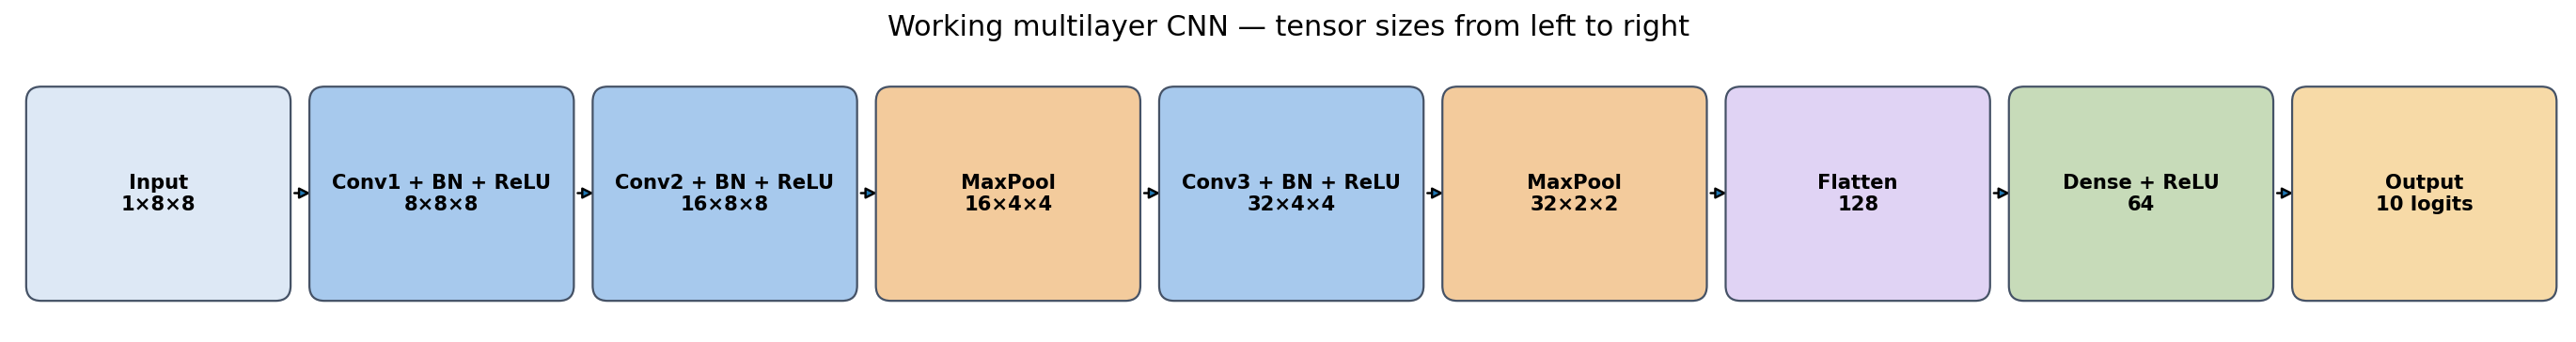

### 23.2 Implementing the CNN in PyTorch

The model declares its pooling layers and applies them during `forward()`. The classifier uses a dense hidden layer of 64 neurons followed by an output layer that produces 10 logits. Each layer is connected using the correct tensor dimensions.

With a mini-batch, the forward pass must yield a tensor of shape $(N,10)$. The trainable weights are initialized independently, and their gradients are computed using `loss.backward()`.

In [52]:
class MultiLayerCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32*2*2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward_features(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # Return logits; CrossEntropyLoss applies log-softmax internally.

torch.manual_seed(SEED)
multi_cnn = MultiLayerCNN(num_classes=10)
with torch.no_grad():
    feature_example = multi_cnn.eval().forward_features(Xtrain[:4])
    logits_example = multi_cnn(Xtrain[:4])
print('Input shape:', tuple(Xtrain[:4].shape))
print('Last feature map:', tuple(feature_example.shape))
print('Output logits:', tuple(logits_example.shape))
print('Trainable parameters:', sum(p.numel() for p in multi_cnn.parameters()))
assert feature_example.shape == (4,32,2,2)
assert logits_example.shape == (4,10)

Input shape: (4, 1, 8, 8)
Last feature map: (4, 32, 2, 2)
Output logits: (4, 10)
Trainable parameters: 14906


### 23.3 Train the CNN with mini-batches

For each mini-batch, compute class logits, cross-entropy loss, gradients and an Adam parameter update. One epoch processes every training example once. We also track validation accuracy using data that are not used for gradient updates.

Epoch 1: training cross-entropy=1.1534, validation accuracy=0.8926
Epoch 2: training cross-entropy=0.1416, validation accuracy=0.9704
Epoch 3: training cross-entropy=0.0481, validation accuracy=0.9815
Epoch 4: training cross-entropy=0.0191, validation accuracy=0.9815
Epoch 5: training cross-entropy=0.0126, validation accuracy=0.9852
Epoch 6: training cross-entropy=0.0043, validation accuracy=0.9852


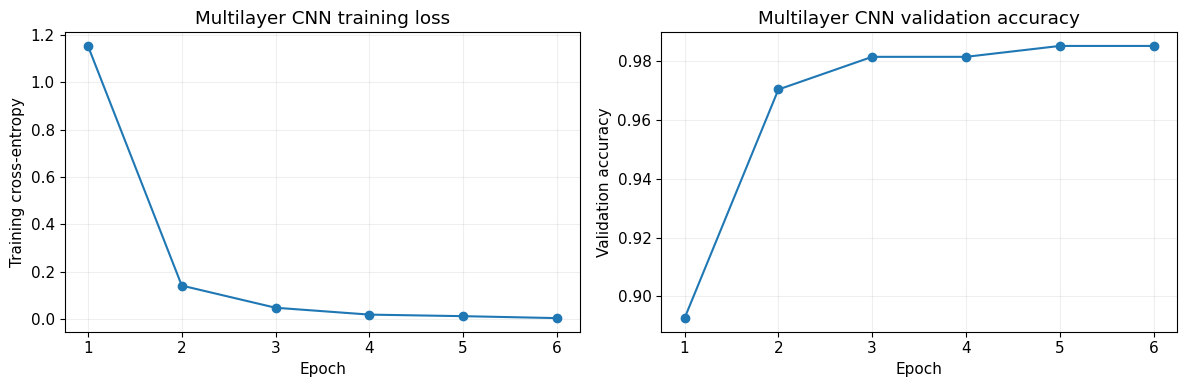

Held-out test accuracy: 0.9926


In [53]:
torch.manual_seed(SEED)
multi_cnn = MultiLayerCNN(num_classes=10)
optimizer_multi = torch.optim.Adam(multi_cnn.parameters(), lr=0.006)
train_loader_multi = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=64, shuffle=True)
loss_multi, acc_multi = [], []
for epoch in range(6):
    multi_cnn.train(); total_loss, count = 0., 0
    for images_batch, labels_batch in train_loader_multi:
        optimizer_multi.zero_grad()
        logits = multi_cnn(images_batch)
        loss = F.cross_entropy(logits, labels_batch)
        loss.backward()
        optimizer_multi.step()
        total_loss += loss.item()*len(images_batch); count += len(images_batch)
    multi_cnn.eval()
    with torch.no_grad(): val_accuracy = (multi_cnn(Xvalid).argmax(1)==yvalid).float().mean().item()
    loss_multi.append(total_loss/count); acc_multi.append(val_accuracy)
    print(f'Epoch {epoch+1}: training cross-entropy={loss_multi[-1]:.4f}, validation accuracy={val_accuracy:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1,7), loss_multi, 'o-'); axes[0].set(xlabel='Epoch',ylabel='Training cross-entropy',title='Multilayer CNN training loss')
axes[1].plot(range(1,7), acc_multi, 'o-'); axes[1].set(xlabel='Epoch',ylabel='Validation accuracy',title='Multilayer CNN validation accuracy')
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()
multi_cnn.eval()
with torch.no_grad(): final_test_accuracy_multi = (multi_cnn(Xtest).argmax(1)==ytest).float().mean().item()
print('Held-out test accuracy:', round(final_test_accuracy_multi,4))

### 23.4 Visualize a digit and the CNN's learned feature maps

This last picture combines the original input with some feature maps after the first convolution. **Feature maps are activations**, not human-labeled parts. Different learned filters may respond to strokes, edges, or other local structures. The activations are shown after the network has been trained.

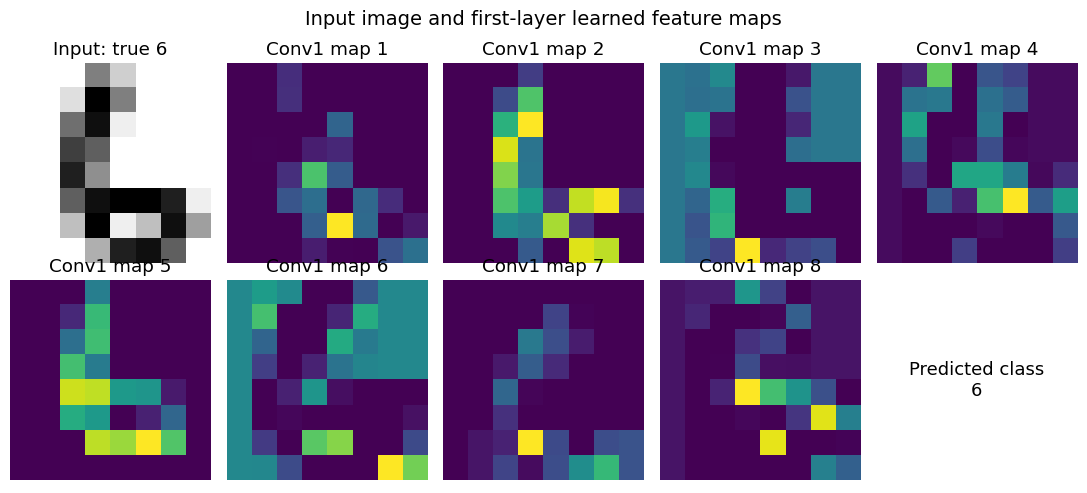

In [54]:
# Learned feature maps and the final prediction for a held-out digit.
multi_cnn.eval()
image_test = Xtest[:1]
with torch.no_grad():
    fmap_first = F.relu(multi_cnn.bn1(multi_cnn.conv1(image_test)))[0].numpy()
    final_prediction = multi_cnn(image_test).argmax(1).item()
fig, axes = plt.subplots(2, 5, figsize=(11,5))
axes = axes.ravel()
axes[0].imshow(image_test[0,0].numpy(), cmap='gray_r'); axes[0].set_title(f'Input: true {ytest[0].item()}')
for i in range(8):
    axes[i+1].imshow(fmap_first[i], cmap='viridis'); axes[i+1].set_title(f'Conv1 map {i+1}')
for ax in axes: ax.axis('off')
axes[-1].text(.5,.5,f'Predicted class\n{final_prediction}',ha='center',va='center',fontsize=13,transform=axes[-1].transAxes)
plt.suptitle('Input image and first-layer learned feature maps',fontsize=14)
plt.tight_layout(); plt.show()

### 23.5 Additional three-convolution network: checking tensor shapes

The trained example uses small $8\times8$ inputs and $3\times3$ kernels. As an additional tensor-shape exercise, consider a model with `Conv2d(1,16,5,stride=2)`, `Conv2d(16,32,5,stride=2)`, and `Conv2d(32,32,5,stride=2)` applied to an $80\times80$ grayscale image, with no padding:

$$80\xrightarrow{K=5,S=2}38\xrightarrow{K=5,S=2}17\xrightarrow{K=5,S=2}7.$$

If we deliberately **apply** a $2\times2$ max-pooling window after the last convolution, the last spatial size becomes $3\times3$. Flattening gives $32(3)(3)=288$ features, which go through one hidden dense layer and the final output. The following is a **shape-check demonstration**, distinct from the trained classifier above. Its pooling and dense layers are explicitly connected so the forward pass has consistent tensor dimensions.

In [55]:
class ConvShapeCheckCNN(nn.Module):
    def __init__(self, outputs=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=0)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=0)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=0)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32*3*3, 64), nn.ReLU(), nn.Linear(64, outputs))

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.head(self.pool(x))

conv_shape_check_cnn = ConvShapeCheckCNN(outputs=10).eval()
example_large_images = torch.rand(3, 1, 80, 80)
with torch.no_grad():
    example_large_logits = conv_shape_check_cnn(example_large_images)
print('Input:', tuple(example_large_images.shape), 'Output:', tuple(example_large_logits.shape))
print('80 -> 38 -> 17 -> 7 -> pool 3 -> flattened 288 -> dense 64 -> logits 10')
assert tuple(example_large_logits.shape) == (3, 10)

Input: (3, 1, 80, 80) Output: (3, 10)
80 -> 38 -> 17 -> 7 -> pool 3 -> flattened 288 -> dense 64 -> logits 10


## 24. Summary: neural networks, training and convolutional models

The notebook starts from weighted neurons and builds to complete trainable networks. It includes manual scalar and multilayer backpropagation, a numeric gradient check, mean-over-dataset gradients, optimizer comparisons, underfitting and overfitting, explicit filter arithmetic, stride/padding dimensions, pooling, and runnable CNN classification examples.

The core ideas to take away are:

- **Neuron:** $z=\sum_j w_jx_j+b$, activation $a=h(z)$.
- **Dense layer:** $\mathbf z=W\mathbf x+\mathbf b$, with one row of $W$ per output neuron.
- **Empirical loss:** $J(\theta)=N^{-1}\sum_i \ell_i(\theta)$.
- **Backpropagation:** chain rule computes $\nabla_\theta J$; an optimizer updates $\theta\leftarrow\theta-\eta\nabla_\theta J$.
- **Convolution:** a kernel is reused across spatial positions; each filter outputs a feature map.
- **Pooling:** summarizes local regions, typically reducing height and width without learned weights.
- **CNN:** repeated convolution/activation/pooling layers learn features that dense output layers use for class predictions.

These calculations are reproducible using the checks below.